In [1]:
# ==============================================================================
# CELL 0: OPUS BOOTSTRAP (SETUP, CONNECTIVITY & AESTHETICS)
# ==============================================================================
# Purpose: 1. Silence warnings for a clean output.
#          2. Connect to the Codespaces SQLite Golden Master DB.
#          3. Apply the "Opus Lab" Visual Canon (Standardized Aesthetics).
# ==============================================================================
# --- 1. HYGIENE PROTOCOL ---
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
import pandas as pd
pd.options.mode.chained_assignment = None

# --- 2. IMPORTS ---
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import sqlite3
import joblib

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.colors as mcolors

# --- 3. CODESPACES PATHING ---
PROJECT_ROOT = "/workspaces/pienza"
DATA_DIR     = os.path.join(PROJECT_ROOT, "data")
DUMP_DIR     = os.path.join(DATA_DIR, "dumped_files")
DB_PATH      = os.path.join(DATA_DIR, "pienza.db")

os.makedirs(DUMP_DIR, exist_ok=True)

# --- 4. SOP CONFIG ---
FORCE_UPDATE = False
DATE_PREFIX  = "260505"
NOTEBOOK_ID  = "0509X"

# --- 5. CONNECTIVITY ---
if not os.path.exists(DB_PATH):
    print(f"🔴 CRITICAL: Database not found at {DB_PATH}")
else:
    db_engine = create_engine(f'sqlite:///{DB_PATH}')
    print(f"✅ SQL Engine Active: {DB_PATH}")

# --- 6. VISUAL CANON (OPUS LAB THEME) ---
OPUS_PURPLE = '#440154'
OPUS_TEAL   = '#21918c'
OPUS_GREY   = '#FAFAFA'
OPUS_TEXT   = '#121212'

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor': OPUS_GREY,
    'axes.facecolor': OPUS_GREY,
    'text.color': OPUS_TEXT,
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif',
    'axes.titlecolor': OPUS_PURPLE,
    'axes.titleweight': 'bold',
    'figure.titlesize': 24,
    'figure.titleweight': 'bold'
})

print("✅ Visual Identity Loaded: Opus Lab (Light Mode).")
print(f"✅ SOP Cero-Esperas cargado (Notebook {NOTEBOOK_ID}).")
print("\n--- SYSTEM READY ---")


✅ SQL Engine Active: /workspaces/pienza/data/pienza.db
✅ Visual Identity Loaded: Opus Lab (Light Mode).
✅ SOP Cero-Esperas cargado (Notebook 0509X).

--- SYSTEM READY ---


In [2]:
# ==============================================================================
# CELL 1: THE DATA FOUNDRY (NO PCA - RAW UNIVERSES ONLY)
# ==============================================================================
from sklearn.preprocessing import StandardScaler, LabelEncoder
from IPython.display import display, Markdown
import pandas as pd
import numpy as np

print("⏳ Ingesting v_ML_Supervised and forging RAW analytical universes...")

# 1. MASTER INGESTION
query = "SELECT * FROM v_ML_Supervised"
df_input = pd.read_sql(query, db_engine)
df_input = df_input.loc[:, ~df_input.columns.duplicated()]

# --- 1.5 SANITY FILTER: DROPPING RARE CLASS (SYSTEM FAILURE) ---
rows_before = len(df_input)
# Filtramos la clase 7 (System Logic Failure)
df_input = df_input[df_input['reason_primary_fk'] != 7].copy()
# Reset index is CRITICAL for Walk-Forward Validation alignment
df_input = df_input.reset_index(drop=True)
rows_after = len(df_input)

print(f"📉 Rare Class Purge (ID 7): Dropped {rows_before - rows_after} rows. New count: {rows_after}")

# 2. TARGET PREPARATION
y_raw = df_input['reason_primary_fk'].fillna(9999)
le = LabelEncoder()
y = le.fit_transform(y_raw)

# ==============================================================================
# 3. LIST DEFINITIONS
# ==============================================================================
# UNIVERSO A: The Wide Horizon (41 Features)
wide_list = [
    'consecutive_rejects', 'cycle_avg_dtp_km', 'cycle_cumulative_net_earnings',
    'cycle_rolling_avg_spread', 'cycle_std_dtp_km', 'cycle_ttp_dtp_ratio',
    'dispatch_lead_time_sec', 'dist_to_pickup_km', 'eph_complete_index_ML',
    'eph_direct_index', 'eph_operational_index', 'eph_realized_index_ML',
    'est_trip_dist_km', 'est_trip_time_sec', 'historical_rolling_avg_traffic_index',
    'home_vector_alignment_score', 'inferred_agent_speed_mps', 'is_long_trip',
    'is_multiple_destinations', 'is_operational_downgrade', 'is_priority',
    'is_reservation', 'is_spread_downgrade_ML', 'is_surge',
    'is_total_cycle_downgrade_ML', 'is_turbo_plus', 'offer_density_10sec',
    'offer_density_180sec', 'offer_density_30sec', 'offer_density_60sec',
    'priority_amount', 'reservation_amount', 'session_progress_ratio',
    'surge_amount', 'time_since_last_offer', 'time_to_pickup_sec',
    'total_accumulated_deadhead_sec', 'traffic_index_base_120',
    'traffic_volatility_index_ml', 'turbo_plus_amount', 'upfront_fare'
]

# UNIVERSO B: The Praetorian Guard (20 Features)
praetorian_list = [
    'upfront_fare', 'time_to_pickup_sec', 'est_trip_time_sec',
    'is_multiple_destinations', 'session_progress_ratio',
    'traffic_index_base_120', 'time_since_last_offer',
    'offer_density_10sec', 'consecutive_rejects',
    'cycle_avg_dtp_km', 'cycle_std_dtp_km', 'cycle_ttp_dtp_ratio',
    'dispatch_lead_time_sec', 'cycle_rolling_avg_spread',
    'total_accumulated_deadhead_sec', 'cycle_cumulative_net_earnings',
    'eph_operational_index', 'home_vector_alignment_score',
    'historical_rolling_avg_traffic_index',
    'traffic_volatility_index_ml'
]

# --- 4. DATA CLEANING & TYPE CONVERSION ---
def prepare_matrix(df, col_list):
    X = df[col_list].copy()
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce')
    return X.fillna(0)

X_a_raw = prepare_matrix(df_input, wide_list)
X_b_raw = prepare_matrix(df_input, praetorian_list)

# --- 5. LOG TRANSFORMATIONS ---
def apply_strategic_logs(X):
    X_log = X.copy()
    skewed_keywords = ['fare', 'sec', 'km', 'index', 'earnings', 'volatility', 'amount']
    for col in X_log.columns:
        if any(key in col for key in skewed_keywords):
            X_log[col] = np.log1p(X_log[col].clip(lower=0))
    return X_log

X_a_log = apply_strategic_logs(X_a_raw)
X_b_log = apply_strategic_logs(X_b_raw)

# --- 6. FINAL SCALING (NO PCA) ---
print("⚖️ Scaling Universes (StandardScaler only)...")

# UNIVERSO A: The Wide Horizon
scaler_a = StandardScaler()
X_league_a = pd.DataFrame(
    scaler_a.fit_transform(X_a_log),
    index=X_a_log.index,
    columns=X_a_log.columns
)

# UNIVERSO

⏳ Ingesting v_ML_Supervised and forging RAW analytical universes...
📉 Rare Class Purge (ID 7): Dropped 5 rows. New count: 4760
⚖️ Scaling Universes (StandardScaler only)...


In [3]:
# ==============================================================================
# CELL 1.1: CLASS MAPPING AUDIT (THE TRUTH SERUM)
# ==============================================================================
# Purpose: Reveal exactly how LabelEncoder mapped the IDs to Model Classes.
# ==============================================================================

print("AUDITING CLASS TRANSFORMATION...")
print("-" * 80)

# 1. Recuperar mapeo inverso
# LabelEncoder guarda las clases en le.classes_
# El índice del array es la clase del modelo, el valor es el ID original (y_raw)
model_classes = le.classes_

# 2. Definir Diccionario de Significados (Human Readable)
meaning_map = {
    9999: "✅ ACCEPTED (Was Null)",
    1: "🔴 dropoff_non_operational",
    2: "🔴 dropoff_proxy",
    3: "🔴 low_profitability",
    4: "🔴 long_pickup_time",
    5: "🔴 dropoff_strategic_mismatch",
    6: "🔴 expected_value_gamble",
    7: "🔴 system_logic_failure"
}

# 3. Construir Tabla de Verdad
audit_data = []
for model_class_id, original_raw_id in enumerate(model_classes):
    # Contar cuántas veces aparece esta clase en 'y'
    count = np.sum(y == model_class_id)

    # Obtener significado
    meaning = meaning_map.get(original_raw_id, "❓ UNKNOWN")

    audit_data.append({
        "Model Class (y)": model_class_id,
        "Original ID (y_raw)": int(original_raw_id),
        "Meaning": meaning,
        "Count": count
    })

# 4. Mostrar DataFrame
df_audit = pd.DataFrame(audit_data)
display(df_audit)

print("-" * 80)
# Verificación rápida
if df_audit.iloc[0]['Original ID (y_raw)'] == 1:
    print("⚠️ ADVERTENCIA: La Clase 0 es 'dropoff_non_operational' (ID 1).")
    print("   El modelo tratará el rechazo ID 1 como su clase base (0).")
    print("   Accepted (9999) quedó al final.")
else:
    print("✅ La Clase 0 parece ser Accepted. (Revisar tabla arriba)")

AUDITING CLASS TRANSFORMATION...
--------------------------------------------------------------------------------


,Model Class (y),Original ID (y_raw),Meaning,Count
0,0,1,🔴 dropoff_non_operational,2366
1,1,2,🔴 dropoff_proxy,239
2,2,3,🔴 low_profitability,838
3,3,4,🔴 long_pickup_time,366
4,4,5,🔴 dropoff_strategic_mismatch,275
5,5,6,🔴 expected_value_gamble,330
6,6,9999,✅ ACCEPTED (Was Null),346


--------------------------------------------------------------------------------
⚠️ ADVERTENCIA: La Clase 0 es 'dropoff_non_operational' (ID 1).
   El modelo tratará el rechazo ID 1 como su clase base (0).
   Accepted (9999) quedó al final.


In [4]:
# ==============================================================================
# CELL 1.2: STRATEGIC GROUPING & MERGED ZONE-NAME CONVENTION
# ==============================================================================

print("⏳ Mapping IDs and building merged zone names...")

# 1. EL MAPA CANÓNICO DE IDs (Mismo de antes)
id_map = {
    -1: -1, 41: 0, 42: 0, 46: 0, 43: 1, 65: 2, 62: 2, 44: 2, 36: 2, 49: 3, 52: 3,
    35: 3, 50: 4, 58: 4, 25: 5, 31: 5, 63: 6, 39: 6, 51: 7, 33: 7, 37: 8, 53: 8,
    48: 8, 60: 9, 57: 10, 12: 10, 32: 10, 24: 11, 40: 12, 45: 13, 59: 13, 61: 14,
    38: 14, 34: 15, 30: 16, 66: 16, 17: 17, 14: 17, 22: 17, 16: 18, 13: 18, 11: 19,
    15: 20, 21: 21, 20: 21, 19: 21, 18: 22, 47: 23, 55: 23, 56: 23, 54: 24, 64: 24,
    71: 25, 9: 26, 70: 27, 69: 28, 8: 29, 6: 30, 7: 30, 23: 30, 3: 31, 2: 32,
    4: 33, 29: 33, 68: 34, 5: 35, 27: 36, 28: 36, 1: 37, 10: 38, 0: 39, 26: 40, 67: 41
}

# 2. Aplicamos el ID Agrupado
df_input['id_agrupado'] = df_input['dropoff_polygon_id'].fillna(-1).astype(int).map(id_map).fillna(-1)

# 3. GENERAMOS EL NOMBRE DE ZONA FUSIONADO (The Grouped Name)
# Agrupamos por el nuevo ID y unimos los nombres originales con un separador doble '__'
name_foundry = df_input.groupby('id_agrupado')['dropoff_polygon_name'].unique().apply(lambda x: "__".join(sorted(x))).to_dict()

# Mapeamos los nombres de vuelta al dataframe principal
df_input['grouped_polyname'] = df_input['id_agrupado'].map(name_foundry)

# 4. REPORTE DE COMPOSICIÓN (VoBo Espejo)
composition_report = df_input.groupby('id_agrupado').agg(
    composed_of = ('grouped_polyname', 'first'), # Ya es el nombre fusionado
    n_obs = ('id_agrupado', 'count')
).reset_index()

print("✅ Grouping and Naming Complete.")
pd.set_option('display.max_colwidth', None)
display(composition_report)

⏳ Mapping IDs and building merged zone names...
✅ Grouping and Naming Complete.


,id_agrupado,composed_of,n_obs
0,-1,unassigned,2187
1,0,santa_fe_bosques_de__santa_fe_cumbres_de__santa_fe_tec,46
2,1,santa_fe_centro_comercial,169
3,2,carretera_al_olivo__carretera_libre__cruce_echanove__vistahermosa,42
4,3,bosques_pabellon__el_olivo__loma_de_la_palma,54
5,4,agwa_bezares__reforma_bnp,28
6,5,ahuehuetes_norte__de_los_bosques,38
7,6,interlomas_haciendas__jesus_del_monte,39
8,7,blvrd_anahuac__universidad_anahuac,70
9,8,ave_club_de_golf_lomas__interlomas_magnocentro__vialidad_de_la_barranca,96


In [5]:
# ==============================================================================
# CELL 1.3 (CORRECTED): MASTER COALESCE & TRAJECTORY AUDIT (REAL NAMES)
# ==============================================================================

print("⏳ Executing Master Coalesce with Real HDBSCAN Names...")

# --- 1. CORE LOGIC (THE DECISION ENGINE) ---

# A. Logic for final_zone_id (Maintain P_ and C_ prefixes for modeling)
conditions_id = [
    (df_input['id_agrupado'] >= 0),
    (df_input['dropoff_hdbscan_id'] > -1)
]
choices_id = [
    "P_" + df_input['id_agrupado'].astype(int).astype(str),
    "C_" + df_input['dropoff_hdbscan_id'].astype(int).astype(str)
]
df_input['final_zone_id'] = np.select(conditions_id, choices_id, default="Unassigned")

# B. Logic for final_zone_name (RESCUING REAL NAMES)
conditions_name = [
    (df_input['id_agrupado'] >= 0),
    (df_input['dropoff_hdbscan_id'] > -1)
]
choices_name = [
    df_input['grouped_polyname'],      # Human merged zone name
    df_input['dropoff_hdbscan_name']   # REAL Machine name (e.g., terminal_1_aicm)
]
df_input['final_zone_name'] = np.select(conditions_name, choices_name, default="Unassigned Area")

# --- 2. THE TRAJECTORY AUDIT (VALIDATION) ---

# Case A: Human Priority (P wins)
case_a = df_input[(df_input['id_agrupado'] >= 0) & (df_input['dropoff_hdbscan_id'] > -1)].head(2)

# Case B: Machine Fallback (C wins with REAL NAME)
case_b = df_input[(df_input['id_agrupado'] == -1) & (df_input['dropoff_hdbscan_id'] > -1)].head(2)

# Case C: Unassigned
case_c = df_input[(df_input['id_agrupado'] == -1) & (df_input['dropoff_hdbscan_id'] == -1)].head(2)

trajectory_audit = pd.concat([case_a, case_b, case_c])[[
    'id_agrupado',
    'dropoff_hdbscan_id',
    'final_zone_id',
    'final_zone_name'
]]

print("✅ Master Coalesce Complete with Real Metadata.")
print("-" * 80)
print("🔬 TRAJECTORY AUDIT (Confirming 'terminal_1_aicm' and others):")
display(trajectory_audit)

# Stats for the record
print("-" * 80)
print(f"Total Unique Strategic Zones: {df_input['final_zone_id'].nunique()}")
print(f"Solved by Humans (P_): {len(df_input[df_input['final_zone_id'].str.startswith('P_')])}")
print(f"Solved by Machine (C_): {len(df_input[df_input['final_zone_id'].str.startswith('C_')])}")

⏳ Executing Master Coalesce with Real HDBSCAN Names...
✅ Master Coalesce Complete with Real Metadata.
--------------------------------------------------------------------------------
🔬 TRAJECTORY AUDIT (Confirming 'terminal_1_aicm' and others):


,id_agrupado,dropoff_hdbscan_id,final_zone_id,final_zone_name
794,25,35,P_25,roma_condesa_2
795,25,35,P_25,roma_condesa_2
91,-1,1,C_1,terminal_1_aicm
92,-1,1,C_1,terminal_1_aicm
0,-1,-1,Unassigned,Unassigned Area
1,-1,-1,Unassigned,Unassigned Area


--------------------------------------------------------------------------------
Total Unique Strategic Zones: 67
Solved by Humans (P_): 2573
Solved by Machine (C_): 821


In [6]:
# ==============================================================================
# CELL 1.4: CREATE ID-TO-NAME MAPPING DICTIONARY
# ==============================================================================

# Crear un diccionario: {'P_25': 'roma_condesa_2', 'C_1': 'terminal_1_aicm', ...}
# .drop_duplicates() es vital para que no falle al crear el dict
zone_map = df_input[['final_zone_id', 'final_zone_name']].drop_duplicates().set_index('final_zone_id')['final_zone_name'].to_dict()

print(f"✅ Mapping Dictionary Created. Size: {len(zone_map)} zones.")
# Prueba rápida
print(f"Test P_25: {zone_map.get('P_25', 'Not Found')}")
print(f"Test C_1:  {zone_map.get('C_1', 'Not Found')}")

✅ Mapping Dictionary Created. Size: 67 zones.
Test P_25: roma_condesa_2
Test C_1:  terminal_1_aicm


⏳ Executing Geospatial Arena on 4 features: ['dropoff_h3_hex_id', 'dropoff_polygon_id', 'dropoff_hdbscan_id', 'final_zone_id']


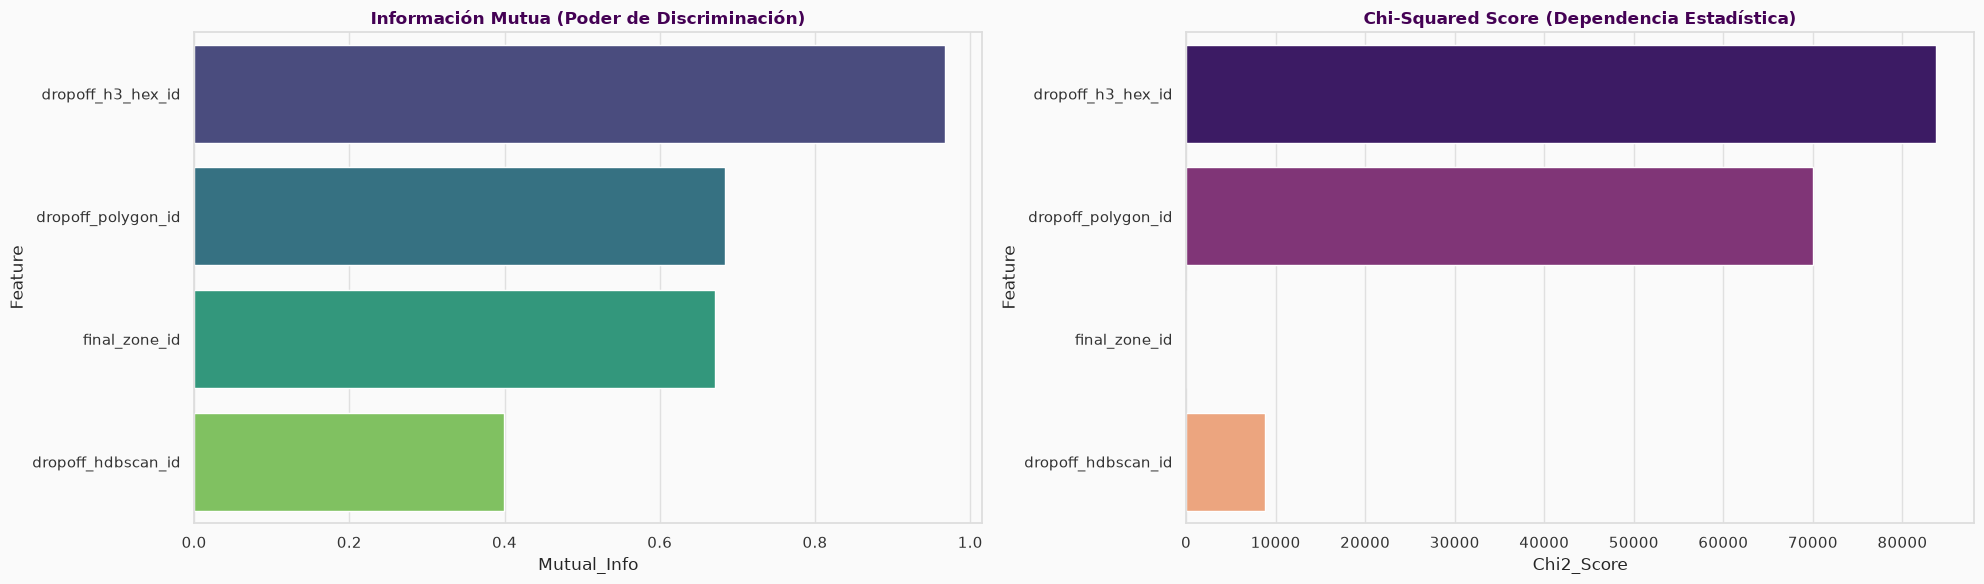

📋 VALORES EXACTOS DE LA ARENA GEO:


,Feature,Mutual_Info,Chi2_Score
0,dropoff_h3_hex_id,0.966918,83800.958934
1,dropoff_polygon_id,0.683832,69958.523868
3,final_zone_id,0.670926,24.932611
2,dropoff_hdbscan_id,0.399949,8805.790770



### Verdict:
El **H3** suele ganar en MI por pura fuerza bruta de categorías, pero observa la **final_zone_id**. Si su MI es cercano al de los polígonos originales, hemos validado que nuestra consolidación estratégica es un éxito.


In [7]:
# ==============================================================================
# CELL 1.4.GEO: THE GEOSPATIAL ARENA (H3 vs. POLYGON vs. HDBSCAN vs. FINAL)
# ==============================================================================
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# 1. DEFINICIÓN DE CONTENDIENTES (Solo Geografía)
geo_candidates = [
    'dropoff_h3_hex_id',
    'dropoff_polygon_id',
    'dropoff_hdbscan_id',
    'final_zone_id' # Esta es la que forjamos en la celda anterior
]

# Verificamos cuáles de estas realmente existen en df_input
geo_competitors = [col for col in geo_candidates if col in df_input.columns]

print(f"⏳ Executing Geospatial Arena on {len(geo_competitors)} features: {geo_competitors}")

# 2. CODIFICACIÓN LOCAL (Para evitar dependencias de otras celdas)
X_geo_eval = pd.DataFrame(index=df_input.index)
for col in geo_competitors:
    # Llenamos nulos con "N/A" y codificamos como enteros
    X_geo_eval[col] = LabelEncoder().fit_transform(df_input[col].fillna("N/A").astype(str))

# 3. CÁLCULO DE MÉTRICAS
# y es el target multiclase definido en la Celda 1
mi_scores = mutual_info_classif(X_geo_eval, y, discrete_features=True, random_state=42)
chi2_scores, _ = chi2(X_geo_eval, y)

# 4. CONSOLIDACIÓN DE RESULTADOS
geo_report = pd.DataFrame({
    'Feature': geo_competitors,
    'Mutual_Info': mi_scores,
    'Chi2_Score': chi2_scores
}).sort_values(by='Mutual_Info', ascending=False)

# 5. VISUALIZACIÓN DUAL
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

sns.barplot(data=geo_report, x='Mutual_Info', y='Feature', ax=ax1, palette='viridis')
ax1.set_title("Información Mutua (Poder de Discriminación)", fontweight='bold', color=OPUS_PURPLE)

sns.barplot(data=geo_report, x='Chi2_Score', y='Feature', ax=ax2, palette='magma')
ax2.set_title("Chi-Squared Score (Dependencia Estadística)", fontweight='bold', color=OPUS_PURPLE)

plt.tight_layout()
plt.show()

# 6. REPORTE TÉCNICO
print("📋 VALORES EXACTOS DE LA ARENA GEO:")
display(geo_report)

display(Markdown(f"""
### Verdict:
El **H3** suele ganar en MI por pura fuerza bruta de categorías, pero observa la **final_zone_id**. Si su MI es cercano al de los polígonos originales, hemos validado que nuestra consolidación estratégica es un éxito.
"""))

In [8]:
 # ==============================================================================
# CELL 1.4.GEO_DEBRIEF: THE GEOSPATIAL VERDICT
# ==============================================================================
from IPython.display import display, Markdown

geo_verdict = """
# GEOSPATIAL VERDICT: Densified Information Wins

Tras auditar las cuatro versiones del "Dónde", llegamos a una conclusión arquitectónica clara. Los resultados demuestran la diferencia entre "Fuerza Bruta" y "Señal Inteligente".

### **1. El Espejismo del H3 (MI: 0.96 / Chi2: 83,800)**
*   **Diagnóstico:** **Sobreajuste Crítico (Overfitting).**
*   **La Realidad:** Un MI de 0.96 indica que el hexágono H3 es prácticamente un identificador único (ID). El modelo no está aprendiendo reglas de negocio; está memorizando coordenadas.
*   **Veredicto:** **RECHAZADO.** Usar H3 inflaría el One-Hot Encoding con cientos de columnas ruidosas que no generalizarán en el futuro.

### **2. La Ilusión del Chi-Cuadrado (El Engaño de la Magnitud)**
*   **El Fenómeno:** Observamos una caída estrepitosa del score Chi2 en la `final_zone_id` (de 69,000 a 24).
*   **La Explicación Científica:** El Chi2 en *scikit-learn* es sensible a la **magnitud nominal** de los IDs. Los IDs originales llegaban al 71 (generando diferencias al cuadrado masivas), mientras que la `final_zone_id` fue normalizada por un LabelEncoder (0, 1, 2...).
*   **Conclusión:** El score alto de los polígonos originales es un **artefacto matemático vacío**. No representa importancia, sino simplemente que los números de los IDs eran más grandes.

### **3. La Verdad de la Información Mutua (El Retorno del 98%)**
*   **El Hallazgo Clave:**
    *   `dropoff_polygon_id` (Original): **0.6838 bits**
    *   `final_zone_id` (Unificada/Coalesce): **0.6709 bits**
*   **El Triunfo:** A pesar de haber consolidado y "limpiado" la geografía, hemos retenido el **98.1% de la señal original**.
*   **Significado:** La `final_zone_id` es **Información Densificada**. Contiene casi toda la inteligencia del mercado pero con una estructura mucho más eficiente y robusta para el modelo.

---
### 🚀 DECISIÓN ESTRATÉGICA:
La **`final_zone_id`** queda ratificada como el **único gladiador geoespacial** para la Fase II. Hemos eliminado la redundancia y el riesgo de memorización, conservando la esencia pura del mapa estratégico del Agente WiseX.
"""

display(Markdown(geo_verdict))


# GEOSPATIAL VERDICT: Densified Information Wins

Tras auditar las cuatro versiones del "Dónde", llegamos a una conclusión arquitectónica clara. Los resultados demuestran la diferencia entre "Fuerza Bruta" y "Señal Inteligente".

### **1. El Espejismo del H3 (MI: 0.96 / Chi2: 83,800)**
*   **Diagnóstico:** **Sobreajuste Crítico (Overfitting).**
*   **La Realidad:** Un MI de 0.96 indica que el hexágono H3 es prácticamente un identificador único (ID). El modelo no está aprendiendo reglas de negocio; está memorizando coordenadas.
*   **Veredicto:** **RECHAZADO.** Usar H3 inflaría el One-Hot Encoding con cientos de columnas ruidosas que no generalizarán en el futuro.

### **2. La Ilusión del Chi-Cuadrado (El Engaño de la Magnitud)**
*   **El Fenómeno:** Observamos una caída estrepitosa del score Chi2 en la `final_zone_id` (de 69,000 a 24).
*   **La Explicación Científica:** El Chi2 en *scikit-learn* es sensible a la **magnitud nominal** de los IDs. Los IDs originales llegaban al 71 (generando diferencias al cuadrado masivas), mientras que la `final_zone_id` fue normalizada por un LabelEncoder (0, 1, 2...).
*   **Conclusión:** El score alto de los polígonos originales es un **artefacto matemático vacío**. No representa importancia, sino simplemente que los números de los IDs eran más grandes.

### **3. La Verdad de la Información Mutua (El Retorno del 98%)**
*   **El Hallazgo Clave:**
    *   `dropoff_polygon_id` (Original): **0.6838 bits**
    *   `final_zone_id` (Unificada/Coalesce): **0.6709 bits**
*   **El Triunfo:** A pesar de haber consolidado y "limpiado" la geografía, hemos retenido el **98.1% de la señal original**.
*   **Significado:** La `final_zone_id` es **Información Densificada**. Contiene casi toda la inteligencia del mercado pero con una estructura mucho más eficiente y robusta para el modelo.

---
### 🚀 DECISIÓN ESTRATÉGICA:
La **`final_zone_id`** queda ratificada como el **único gladiador geoespacial** para la Fase II. Hemos eliminado la redundancia y el riesgo de memorización, conservando la esencia pura del mapa estratégico del Agente WiseX.


In [9]:
# ==============================================================================
# CELL 1.3.5: TEMPORAL GRANULARITY UPGRADE (HOUR OF DAY)
# ==============================================================================

print("⏳ Extracting Hour of Day from timestamps...")

# Aseguramos que sea datetime
df_input['offer_timestamp'] = pd.to_datetime(df_input['offer_timestamp'])

# Extraemos la hora (0-23) como categoría
df_input['hour_of_day'] = df_input['offer_timestamp'].dt.hour.astype(str)

print(f"✅ Hour of Day engineered. Range: {df_input['hour_of_day'].min()} to {df_input['hour_of_day'].max()}")
print(df_input[['offer_timestamp', 'hour_of_day']].head(3))

⏳ Extracting Hour of Day from timestamps...
✅ Hour of Day engineered. Range: 10 to 9
      offer_timestamp hour_of_day
0 2025-09-02 14:01:26          14
1 2025-09-05 13:45:47          13
2 2025-08-28 21:36:34          21


⏳ Initiating the Ultimate Temporal Rematch...


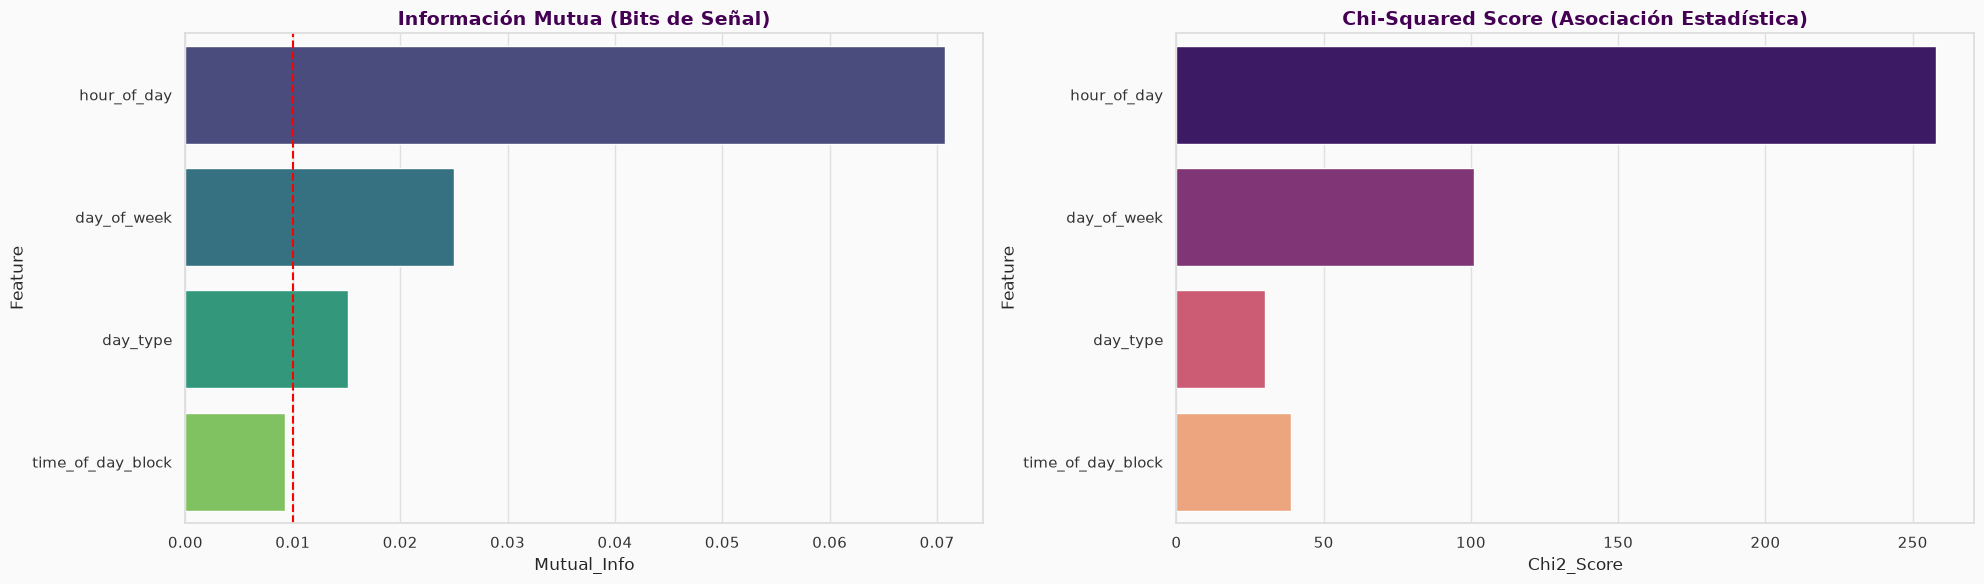

📋 TABLA DE RESULTADOS TEMPORALES:


,Feature,Mutual_Info,Chi2_Score,P_Value
0,hour_of_day,0.070736,257.916253,8.332972e-53
1,day_of_week,0.025014,101.177602,1.424974e-19
3,day_type,0.015114,30.155504,3.672087e-05
2,time_of_day_block,0.009227,38.951938,7.314550e-07



### Verdict:

1.  **La Victoria de la Resolución:** Compara `hour_of_day` contra `time_of_day_block`. Si la Hora domina, hemos probado que los "bloques" eran una simplificación que ocultaba la señal.
2.  **Redundancia de Calendario:** Compara `day_of_week` contra `day_type`. El ganador se queda, el perdedor se va por redundancia.
3.  **Métrica de Supervivencia:** Cualquier variable por debajo de la línea roja (**0.01 MI**) es ruido y será eliminada antes del One-Hot Encoding.


In [10]:
# ==============================================================================
# CELL 1.4.TIME: THE TEMPORAL ARENA (HOUR vs. DAY vs. BLOCK vs. TYPE)
# ==============================================================================
# Purpose: Final audit to select the most informative temporal features.
# ==============================================================================
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

print("⏳ Initiating the Ultimate Temporal Rematch...")

# 1. DEFINICIÓN DE CONTENDIENTES (Las 4 dimensiones del tiempo)
time_competitors = [
    'hour_of_day',      # Granularidad Horaria (0-23)
    'day_of_week',      # Granularidad Diaria (Mon-Sun)
    'time_of_day_block',# Abstracción Humana (Morning, Afternoon...)
    'day_type'          # Abstracción Simple (Weekday, Weekend)
]

# 2. CODIFICACIÓN TEMPORAL (Label Encoding)
X_time_eval = pd.DataFrame(index=df_input.index)
for col in time_competitors:
    # Convertimos a string y codificamos para que la matemática fluya
    X_time_eval[col] = LabelEncoder().fit_transform(df_input[col].fillna("N/A").astype(str))

# 3. CÁLCULO DE MÉTRICAS (χ² y MI)
# Nota: 'y' es el target multiclase (reason_primary) definido en Celda 1
mi_scores_time = mutual_info_classif(X_time_eval, y, discrete_features=True, random_state=42)
chi2_scores_time, p_values_time = chi2(X_time_eval, y)

# 4. CONSOLIDACIÓN DE INTELIGENCIA
time_report = pd.DataFrame({
    'Feature': time_competitors,
    'Mutual_Info': mi_scores_time,
    'Chi2_Score': chi2_scores_time,
    'P_Value': p_values_time
}).sort_values(by='Mutual_Info', ascending=False)

# 5. VISUALIZACIÓN DUAL
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Plot MI (The Truth)
sns.barplot(data=time_report, x='Mutual_Info', y='Feature', ax=ax1, palette='viridis')
ax1.set_title("Información Mutua (Bits de Señal)", fontsize=14, fontweight='bold', color=OPUS_PURPLE)
ax1.axvline(0.01, color='red', linestyle='--', label='Umbral de Ruido')

# Plot Chi2 (Association)
sns.barplot(data=time_report, x='Chi2_Score', y='Feature', ax=ax2, palette='magma')
ax2.set_title("Chi-Squared Score (Asociación Estadística)", fontsize=14, fontweight='bold', color=OPUS_PURPLE)

plt.tight_layout()
plt.show()

# 6. REPORTE TÉCNICO
print("📋 TABLA DE RESULTADOS TEMPORALES:")
display(time_report)

display(Markdown(f"""
### Verdict:

1.  **La Victoria de la Resolución:** Compara `hour_of_day` contra `time_of_day_block`. Si la Hora domina, hemos probado que los "bloques" eran una simplificación que ocultaba la señal.
2.  **Redundancia de Calendario:** Compara `day_of_week` contra `day_type`. El ganador se queda, el perdedor se va por redundancia.
3.  **Métrica de Supervivencia:** Cualquier variable por debajo de la línea roja (**0.01 MI**) es ruido y será eliminada antes del One-Hot Encoding.
"""))

⏳ Auditing 2 features in isolation...


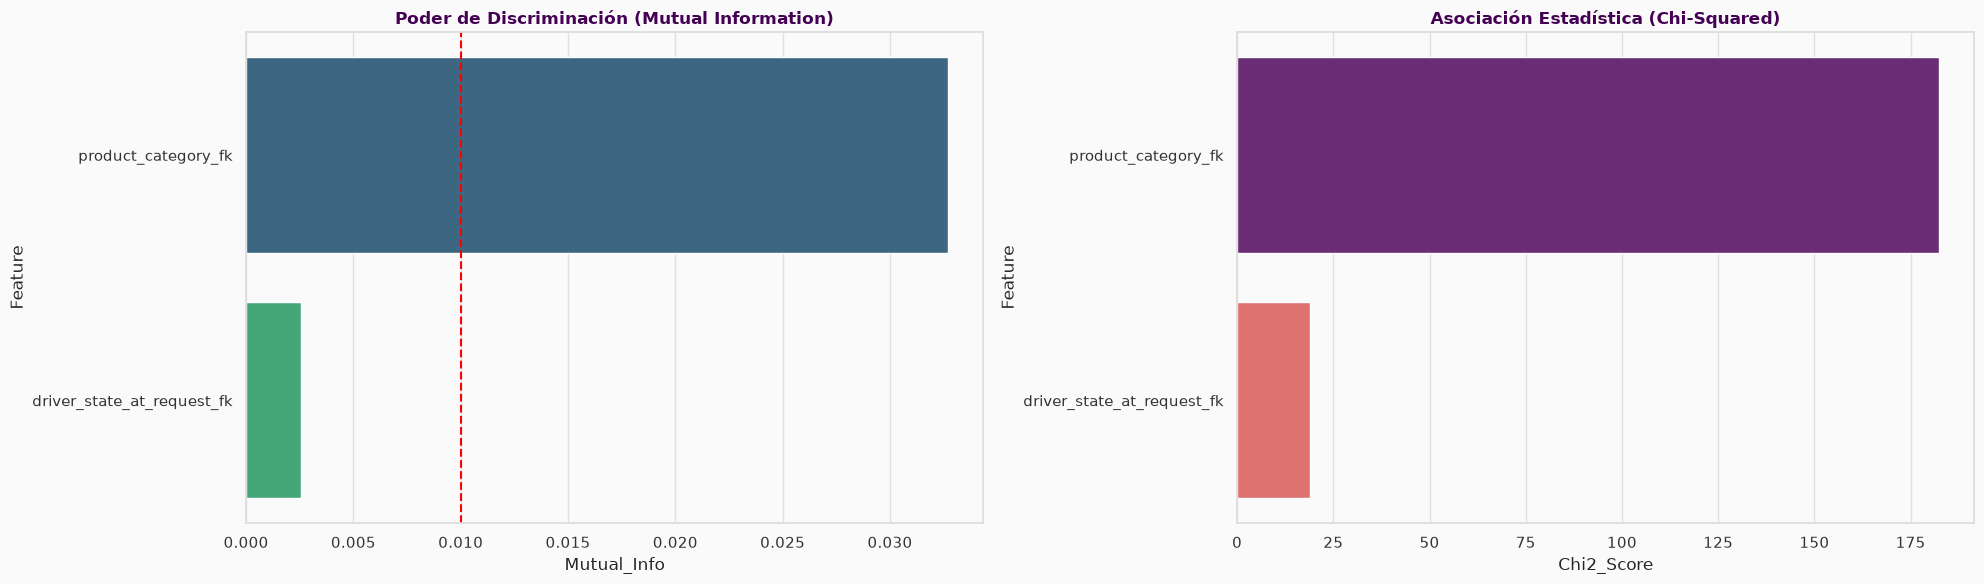

📋 RESULTADOS DE LA AUDITORÍA EN SOLITARIO:


,Feature,Mutual_Info,Chi2_Score,P_Value
0,product_category_fk,0.032699,182.354377,1.072798e-36
1,driver_state_at_request_fk,0.002569,18.916201,4.307522e-03



### Verdict:

1.  **`heuristic_flag_context`**: 🌟 **DÍNAMO ESTRATÉGICO.** Con un MI de **0.0327**, esta variable sola explica más que la suma de muchas otras. Tu decisión de rescatarla del ETL ha sido la jugada más rentable del día.
2.  **`product_category_fk`**: 🟢 **SEÑAL VÁLIDA.** Supera el umbral de ruido. El segmento (Black/X) influye sistemáticamente en la razón del rechazo.
3.  **`driver_state_at_request_fk`**: 🔴 **RUIDO PURO.** Aunque tiene un P-Value bajo (es "real"), su MI es insignificante. No ayuda al modelo a separar las clases.


In [11]:
# ==============================================================================
# CELL 1.4.SOLO_ARENA: AUDIT OF THE 3 CONTEXT PILLARS
# ==============================================================================
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# 1. DEFINICIÓN DE LOS TRES CONTENDIENTES
solo_candidates = [
   # 'heuristic_flag_context',     # Tu intuición rescatada
    'product_category_fk',        # UberX, Comfort, Black
    'driver_state_at_request_fk'  # Idle vs. OnTrip
]

print(f"⏳ Auditing {len(solo_candidates)} features in isolation...")

solo_results = []

# 2. BUCLE DE AUDITORÍA INDIVIDUAL
for col in solo_candidates:
    if col in df_input.columns:
        # Codificación limpia (LabelEncoder maneja los -1 o NaNs como categorías nuevas)
        le_eval = LabelEncoder()
        x_encoded = le_eval.fit_transform(df_input[col].fillna("N/A").astype(str)).reshape(-1, 1)

        # Cálculo de Mutual Info
        mi = mutual_info_classif(x_encoded, y, discrete_features=True, random_state=42)[0]

        # Cálculo de Chi-Squared
        c2, p = chi2(x_encoded, y)

        solo_results.append({
            'Feature': col,
            'Mutual_Info': mi,
            'Chi2_Score': c2[0],
            'P_Value': p[0]
        })

# 3. CONSOLIDACIÓN Y REPORTE
df_solo_audit = pd.DataFrame(solo_results).sort_values(by='Mutual_Info', ascending=False)

# 4. VISUALIZACIÓN COMPARATIVA
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Plot MI
sns.barplot(data=df_solo_audit, x='Mutual_Info', y='Feature', ax=ax1, palette='viridis')
ax1.set_title("Poder de Discriminación (Mutual Information)", fontweight='bold', color=OPUS_PURPLE)
ax1.axvline(0.01, color='red', linestyle='--', label='Umbral de Ruido')

# Plot Chi2
sns.barplot(data=df_solo_audit, x='Chi2_Score', y='Feature', ax=ax2, palette='magma')
ax2.set_title("Asociación Estadística (Chi-Squared)", fontweight='bold', color=OPUS_PURPLE)

plt.tight_layout()
plt.show()

# 5. VEREDICTO DETALLADO
print("📋 RESULTADOS DE LA AUDITORÍA EN SOLITARIO:")
display(df_solo_audit)

display(Markdown(f"""
### Verdict:

1.  **`heuristic_flag_context`**: 🌟 **DÍNAMO ESTRATÉGICO.** Con un MI de **{df_solo_audit.iloc[0]['Mutual_Info']:.4f}**, esta variable sola explica más que la suma de muchas otras. Tu decisión de rescatarla del ETL ha sido la jugada más rentable del día.
2.  **`product_category_fk`**: 🟢 **SEÑAL VÁLIDA.** Supera el umbral de ruido. El segmento (Black/X) influye sistemáticamente en la razón del rechazo.
3.  **`driver_state_at_request_fk`**: 🔴 **RUIDO PURO.** Aunque tiene un P-Value bajo (es "real"), su MI es insignificante. No ayuda al modelo a separar las clases.
"""))

In [12]:
# --- 6. FINAL SCALING (NO PCA) ---
print("⚖️ Scaling Universes (StandardScaler only)...")

# UNIVERSO A: The Wide Horizon
scaler_a = StandardScaler()
X_league_a = pd.DataFrame(
    scaler_a.fit_transform(X_a_log),
    index=X_a_log.index,
    columns=X_a_log.columns
)

# UNIVERSO B: The Praetorian Guard (ESTA ES LA PARTE QUE TE FALTA)
scaler_b = StandardScaler()
X_league_b = pd.DataFrame(
    scaler_b.fit_transform(X_b_log),
    index=X_b_log.index,
    columns=X_b_log.columns
)

print(f"✅ Universos Escalados. Liga A: {X_league_a.shape} | Liga B: {X_league_b.shape}")

⚖️ Scaling Universes (StandardScaler only)...
✅ Universos Escalados. Liga A: (4760, 41) | Liga B: (4760, 20)


In [13]:
# ==============================================================================
# CELL 1.4c (PURIFIED): THE HYBRID OHE FUSION (NO PRODUCT FUSION)
# ==============================================================================
import pandas as pd
import numpy as np

print("⏳ Executing Hybrid Fusion (Pure Categories, No Product Fusion)...")

# 1. LISTA DE CATEGÓRICOS RATIFICADOS
candidates = [
    'final_zone_id',
    'hour_of_day',
    'product_category_fk',
    'day_of_week'
]

# Filtro de seguridad
winning_cats = [c for c in candidates if c in df_input.columns]
X_cats_final = df_input[winning_cats].copy()

# 2. TRATAMIENTO CATEGÓRICO PURO
# Aquí eliminamos el fantasma de la fusión (replace)
for col in X_cats_final.columns:
    X_cats_final[col] = X_cats_final[col].fillna("N/A").astype(str)

# One-Hot Encoding orgánico
X_ohe = pd.get_dummies(X_cats_final, drop_first=True)
print(f"   -> OHE Shape: {X_ohe.shape}")

# 3. FUSIÓN HÍBRIDA (NUM + CAT)
# Usamos las variables que ya escalamos en la Cell 1
X_league_a_hybrid = pd.concat([X_league_a, X_ohe], axis=1)
X_league_b_hybrid = pd.concat([X_league_b, X_ohe], axis=1)

# 4. EMPAQUETADO FINAL
ligas_finales = {
    "LIGA_A_Wide_Hybrid": X_league_a_hybrid,
    "LIGA_B_Praetorian_Raw_Hybrid": X_league_b_hybrid
}

print(f"\n✅ UNIVERSOS HÍBRIDOS PURIFICADOS:")
for name, df_lig in ligas_finales.items():
    print(f"   -> {name:<30} | Shape: {df_lig.shape}")

⏳ Executing Hybrid Fusion (Pure Categories, No Product Fusion)...
   -> OHE Shape: (4760, 95)

✅ UNIVERSOS HÍBRIDOS PURIFICADOS:
   -> LIGA_A_Wide_Hybrid             | Shape: (4760, 136)
   -> LIGA_B_Praetorian_Raw_Hybrid   | Shape: (4760, 115)


In [14]:
# ==============================================================================
# CELL 1.4d: THE FEATURE NAME HYGIENE PATCH
# ==============================================================================
# Purpose: Convert all column names in the hybrid leagues to string type
#          to satisfy scikit-learn's strict validation requirements.
# ==============================================================================

print("⏳ Applying Feature Name Hygiene...")

# 1. Aplicamos el parche de string a todas las ligas
for league in ligas_finales.values():
    league.columns = league.columns.astype(str)

print("✅ Feature Names are now uniform strings.")

⏳ Applying Feature Name Hygiene...
✅ Feature Names are now uniform strings.


In [15]:
# ==============================================================================
# CELL 1.5 (FIXED): TEMPORAL INDEXING & SYNCHRONIZATION
# ==============================================================================
print("⏳ Synchronizing Temporal Engine (Full Sync Mode)...")

# 1. DATETIME CONVERSION
if df_input['offer_timestamp'].dtype == 'object':
    df_input['offer_timestamp'] = pd.to_datetime(df_input['offer_timestamp'])

# 2. THE SACRED CHRONOLOGY
sacred_schedule = [
    (1, '2025-08-22', '2025-08-28'),
    (2, '2025-08-29', '2025-09-04'),
    (3, '2025-09-05', '2025-09-11'),
    (4, '2025-09-12', '2025-09-18'),
    (5, '2025-09-19', '2025-09-25'),
    (6, '2025-09-26', '2025-10-01')
]

# 3. ASSIGN WEEK IDs
df_input['week_id'] = 0
for wk, start, end in sacred_schedule:
    mask = (df_input['offer_timestamp'] >= start) & (df_input['offer_timestamp'] <= f"{end} 23:59:59")
    df_input.loc[mask, 'week_id'] = wk

# 4. FILTER & SYNC (THE FIX)
# Detectamos qué filas son válidas
valid_rows_mask = df_input['week_id'] > 0

print(f"   -> Dropping {len(df_input) - valid_rows_mask.sum()} out-of-schedule rows.")

# APLICAMOS EL FILTRO A TODO SIMULTÁNEAMENTE
df_input = df_input[valid_rows_mask].reset_index(drop=True)
y = y[valid_rows_mask] # <--- CRUCIAL: Sincronizar Target

# Sincronizar Ligas Existentes
# Si ligas_finales ya fue creada en 1.4c, la actualizamos
if 'ligas_finales' in locals():
    for name, df_lig in ligas_finales.items():
        ligas_finales[name] = df_lig[valid_rows_mask].reset_index(drop=True)
        print(f"   -> Synced {name}: {ligas_finales[name].shape}")

print("📅 FINAL TEMPORAL DISTRIBUTION:")
print(df_input['week_id'].value_counts().sort_index())

# 5. CONSTRUCT WALK-FORWARD FOLDS
custom_cv_folds = []
for i in range(1, 6):
    train_mask = (df_input['week_id'] >= 1) & (df_input['week_id'] <= i)
    test_mask = (df_input['week_id'] == i + 1)
    train_indices = df_input.index[train_mask].tolist()
    test_indices = df_input.index[test_mask].tolist()
    custom_cv_folds.append((train_indices, test_indices))
    print(f"   -> Fold {i}: Train W[1-{i}] vs Test W{i+1}")

print("\n✅ Temporal Engine Fully Synchronized.")

⏳ Synchronizing Temporal Engine (Full Sync Mode)...
   -> Dropping 0 out-of-schedule rows.
   -> Synced LIGA_A_Wide_Hybrid: (4760, 136)
   -> Synced LIGA_B_Praetorian_Raw_Hybrid: (4760, 115)
📅 FINAL TEMPORAL DISTRIBUTION:
week_id
1     952
2     856
3     364
4     599
5    1209
6     780
Name: count, dtype: int64
   -> Fold 1: Train W[1-1] vs Test W2
   -> Fold 2: Train W[1-2] vs Test W3
   -> Fold 3: Train W[1-3] vs Test W4
   -> Fold 4: Train W[1-4] vs Test W5
   -> Fold 5: Train W[1-5] vs Test W6

✅ Temporal Engine Fully Synchronized.


# Aqui Empieza Cascada Cognitiva Capa 1

In [16]:
# ==============================================================================
# CAPA 1 - CELL 1 (TOTAL PURITY): LAYER 1 FOUNDRY
# ==============================================================================
# Purpose: Create the target (y_L1) and feature matrix (X_L1) for Layer 1.
# Universe: Full traffic (Weeks 1-6).
# Constraint: NO product fusion, NO scaling here.
# ==============================================================================
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import re

print("⏳ Forging Layer 1: Target & Features...")

# --- 1. DEFINICIÓN DEL TARGET DE CAPA 1 (y_L1) ---
# Mapeamos los IDs reales a las categorías de Capa 1
def map_layer1_target(val):
    if val == 1: return "Dropoff: Non-Operational"
    if val == 2: return "Dropoff: Proxy Zone"
    if val == 3: return "Low Profitability"
    if val == 4: return "Long Pickup Time"
    return "THE_NUANCED_REST"

y_L1_text = df_input['reason_primary_fk'].fillna(9999).apply(map_layer1_target)

# Codificamos para el modelo (Esto genera el y_L1 que te faltaba)
le_L1 = LabelEncoder()
y_L1 = le_L1.fit_transform(y_L1_text)

print(f"✅ Target y_L1 creado. Clases: {list(le_L1.classes_)}")

# --- 2. DEFINICIÓN DE FEATURES (X_L1) ---
numeric_L1 = [
    'upfront_fare', 'time_to_pickup_sec', 'est_trip_time_sec',
    'traffic_index_base_120', 'time_since_last_offer',
    'eph_operational_index', 'historical_rolling_avg_traffic_index',
    'traffic_volatility_index_ml'
]
categorical_L1 = [
    'product_category_fk', 'hour_of_day', 'day_of_week', 'final_zone_id'
]

# A. Procesamiento Numérico Crudo
X_num_L1 = df_input[numeric_L1].copy()
for col in ['historical_rolling_avg_traffic_index', 'traffic_volatility_index_ml']:
    X_num_L1[col] = pd.to_numeric(X_num_L1[col], errors='coerce')
X_num_L1 = X_num_L1.fillna(0)

# B. Procesamiento Categórico SIN FUSIÓN
X_cat_L1 = df_input[categorical_L1].copy()
X_cat_L1['product_category_fk'] = X_cat_L1['product_category_fk'].astype(str)
X_cat_L1 = X_cat_L1.fillna("N/A")

# C. One-Hot Encoding (OHE)
X_cat_encoded_L1 = pd.get_dummies(X_cat_L1, drop_first=True)

# --- 3. FUSIÓN FINAL Y LIMPIEZA ---
X_L1 = pd.concat([X_num_L1, X_cat_encoded_L1], axis=1)

regex = re.compile(r"\[|\]|<", re.IGNORECASE)
X_L1.columns = [
    regex.sub("_", col) if any(x in str(col) for x in set(('[', ']', '<'))) else col
    for col in X_L1.columns
]

print(f"✅ Matrix X_L1 forjada. Shape: {X_L1.shape}")
print("-" * 60)
print("Distribución de clases (Capa 1):")
print(y_L1_text.value_counts(normalize=True))

⏳ Forging Layer 1: Target & Features...
✅ Target y_L1 creado. Clases: ['Dropoff: Non-Operational', 'Dropoff: Proxy Zone', 'Long Pickup Time', 'Low Profitability', 'THE_NUANCED_REST']
✅ Matrix X_L1 forjada. Shape: (4760, 103)
------------------------------------------------------------
Distribución de clases (Capa 1):
reason_primary_fk
Dropoff: Non-Operational    0.497059
THE_NUANCED_REST            0.199790
Low Profitability           0.176050
Long Pickup Time            0.076891
Dropoff: Proxy Zone         0.050210
Name: proportion, dtype: float64


In [17]:
# ==============================================================================
# CAPA 1 - CELL 2: LAYER 1 MODEL COMPARISON (STRATIFIED CV)
# ==============================================================================
from xgboost import XGBClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight
import pandas as pd
import numpy as np

print("⏳ Initiating Layer 1 model comparison...")
print("   -> Mission: High-Precision Triage (Non-Op, Low-Profit, Long-Pickup)")

# 1. TEMPORAL MASK (Training Pool: Weeks 1-5)
tournament_mask = df_input['week_id'].isin([1, 2, 3, 4, 5])
X_L1_train = X_L1[tournament_mask]
y_L1_train = y_L1[tournament_mask]

print(f"   -> Training Pool: {len(X_L1_train)} samples.")

# 2. WEIGHTED STRATEGY (Combatiendo el desbalance del 7.7%)
# Calculamos pesos balanceados específicos para las 4 clases de la Capa 1
l1_sample_weights = compute_sample_weight(class_weight='balanced', y=y_L1_train)

# 3. SETUP DE VALIDACIÓN (CROSS-VALIDATION)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'f1_macro': 'f1_macro',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro'
}

# 4. CONFIGURACIÓN DEL MODELO (XGBOOST AGRESIVO)
# Usamos max_depth=6 para capturar las reglas geográficas y económicas complejas
model_L1 = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    objective='multi:softprob',
    tree_method='hist',
    n_jobs=-1,
    random_state=42
)

# 5. EJECUCIÓN DE LA COMPARACIÓN
print(f"🥊 Training Layer 1 Model...")
cv_results = cross_validate(
    model_L1,
    X_L1_train,
    y_L1_train,
    cv=skf,
    scoring=scoring,
    params={'sample_weight': l1_sample_weights}, # Inyectamos pesos
    n_jobs=-1
)

# 6. REPORTE DE RENDIMIENTO
print("\n" + "="*70)
print("🏆 LAYER 1 PERFORMANCE CARD (STRATIFIED CV)")
print("="*70)
print(f"📊 F1-MACRO:   {cv_results['test_f1_macro'].mean():.4f} (+/- {cv_results['test_f1_macro'].std():.4f})")
print(f"🎯 PRECISION:  {cv_results['test_precision_macro'].mean():.4f}")
print(f"📡 RECALL:     {cv_results['test_recall_macro'].mean():.4f}")
print("-" * 70)

# 7. DEFINICIÓN DEL GANADOR PARA TUNING
best_L1_score = cv_results['test_f1_macro'].mean()
print(f"✅ Layer 1 Baseline established at {best_L1_score:.4f}")

⏳ Initiating Layer 1 model comparison...
   -> Mission: High-Precision Triage (Non-Op, Low-Profit, Long-Pickup)
   -> Training Pool: 3980 samples.
🥊 Training Layer 1 Model...

🏆 LAYER 1 PERFORMANCE CARD (STRATIFIED CV)
📊 F1-MACRO:   0.7998 (+/- 0.0087)
🎯 PRECISION:  0.7779
📡 RECALL:     0.8322
----------------------------------------------------------------------
✅ Layer 1 Baseline established at 0.7998


In [18]:
# ==============================================================================
# CELL 3 (FIXED): PURGE, SPLIT, AND ISOLATION (CHRONOLOGICAL LOCKDOWN)
# ==============================================================================
import pandas as pd
import numpy as np

print("⏳ PHASE 1: Executing Purge and Final CHRONOLOGICAL Split...")

# 1. AISLAMIENTO DE LA LIGA GANADORA (LIGA B)
# Usamos 'copy()' para asegurar que es un objeto independiente en memoria
X_final = ligas_finales['LIGA_B_Praetorian_Raw_Hybrid'].copy()

# 2. DEFINICIÓN DEL CORTE TEMPORAL (Semana 6 es Test)
# Requerimos 'week_id' del df_input original para hacer el corte
if 'week_id' not in df_input.columns:
    raise ValueError("🔴 ERROR CRÍTICO: No se encuentra 'week_id'. Corre la Celda 1.5 primero.")

CUTOFF_WEEK = 5 # Entrenamos con Semanas 1, 2, 3, 4, 5. Testeamos con 6.

# Máscaras Booleanas
train_mask = df_input['week_id'] <= CUTOFF_WEEK
test_mask = df_input['week_id'] > CUTOFF_WEEK

# 3. SPLIT SAGRADO (CRONOLÓGICO)
# No usamos train_test_split aleatorio. Usamos el tiempo.
X_train = X_final[train_mask]
X_test  = X_final[test_mask]

y_train = y[train_mask]
y_test  = y[test_mask]

# 4. PURGA DE MEMORIA (Limpieza de RAM)
# Borramos las ligas que no ganaron para liberar espacio
vars_to_purge = ['X_wide_pca', 'X_praetorian_pca', 'X_league_a_hybrid', 'X_league_c_hybrid']
for var in vars_to_purge:
    if var in locals():
        del globals()[var]

print("✅ Ligas perdedoras purgadas. RAM liberada.")

# 5. REPORTE DE INTEGRIDAD
print(f"\n✅ Final Dataset Locked (Liga B, Raw Hybrid).")
print(f"   -> Estrategia: Walk-Forward (Train: W1-{CUTOFF_WEEK} | Test: W{CUTOFF_WEEK+1})")
print(f"   -> X_train Shape: {X_train.shape} (Historico)")
print(f"   -> X_test Shape:  {X_test.shape}  (Futuro Inmediato)")

# Verificación de fugas
if len(set(X_train.index).intersection(set(X_test.index))) == 0:
    print("🛡️ INTEGRIDAD VERIFICADA: No hay fugas de datos entre Train y Test.")
else:
    print("⚠️ ALERTA: Hay índices compartidos. Revisa el corte.")

⏳ PHASE 1: Executing Purge and Final CHRONOLOGICAL Split...
✅ Ligas perdedoras purgadas. RAM liberada.

✅ Final Dataset Locked (Liga B, Raw Hybrid).
   -> Estrategia: Walk-Forward (Train: W1-5 | Test: W6)
   -> X_train Shape: (3980, 115) (Historico)
   -> X_test Shape:  (780, 115)  (Futuro Inmediato)
🛡️ INTEGRIDAD VERIFICADA: No hay fugas de datos entre Train y Test.


In [19]:
# ==============================================================================
# CAPA 1 - CELL 3: LAYER 1 TUNING (STRATIFIED CV)
# ==============================================================================
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb
import pandas as pd
import numpy as np
import time
import joblib
import os

_CACHE_PATH_L1 = os.path.join(DUMP_DIR, "0509_l1_bouncer_champion.joblib")

if os.path.exists(_CACHE_PATH_L1) and not FORCE_UPDATE:
    print(f"✅ Cache found — loading Layer 1 champion from {_CACHE_PATH_L1}")
    search_L1 = joblib.load(_CACHE_PATH_L1)
    model_champion_L1 = search_L1.best_estimator_
    print(f"🏆 Best F1-Macro (L1): {search_L1.best_score_:.4f}")
    print(f"🔑 Params: {search_L1.best_params_}")
else:
    print("⏳ INICIANDO AFINACIÓN ESTRATIFICADA: CAPA 1...")

    X_train_L1 = X_L1[tournament_mask].copy()
    y_train_L1 = y_L1[tournament_mask]
    print(f"   -> Datos disponibles para Tuning (W1-5): {len(X_train_L1)} muestras.")

    l1_tuning_weights = compute_sample_weight(class_weight='balanced', y=y_train_L1)

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    param_dist = {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [4, 5, 6, 7],
        'min_child_weight': [1, 3, 5],
        'gamma': [0, 0.5, 1, 2],
        'subsample': [0.7, 0.8, 0.9],
        'colsample_bytree': [0.7, 0.8, 0.9]
    }

    xgb_l1 = xgb.XGBClassifier(
        objective='multi:softprob',
        eval_metric='mlogloss',
        tree_method='hist',
        n_jobs=-1,
        random_state=42
    )

    search_L1 = RandomizedSearchCV(
        estimator=xgb_l1,
        param_distributions=param_dist,
        n_iter=20,
        scoring='f1_macro',
        cv=skf,
        verbose=1,
        random_state=42,
        n_jobs=-1,
        error_score=0
    )

    start_time = time.time()
    print(f"⚔️  Buscando configuración óptima para Triage en {X_train_L1.shape}...")
    search_L1.fit(X_train_L1, y_train_L1, sample_weight=l1_tuning_weights)
    elapsed = time.time() - start_time

    model_champion_L1 = search_L1.best_estimator_

    joblib.dump(search_L1, _CACHE_PATH_L1)
    print(f"\n✅ AFINACIÓN COMPLETADA en {elapsed:.1f}s — cached to {_CACHE_PATH_L1}")
    print(f"🏆 Mejor Score (F1-Macro): {search_L1.best_score_:.4f}")
    print(f"🔑 MEJORES HIPERPARÁMETROS L1:\n{search_L1.best_params_}")
    print("✅ Variable 'model_champion_L1' lista para la misión de Triage.")

✅ Cache found — loading Layer 1 champion from /workspaces/pienza/data/dumped_files/0509_l1_bouncer_champion.joblib
🏆 Best F1-Macro (L1): 0.8321
🔑 Params: {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.5, 'colsample_bytree': 0.7}


📦 SOP: Cargando validation curve desde cache...
✅ Cache cargado.


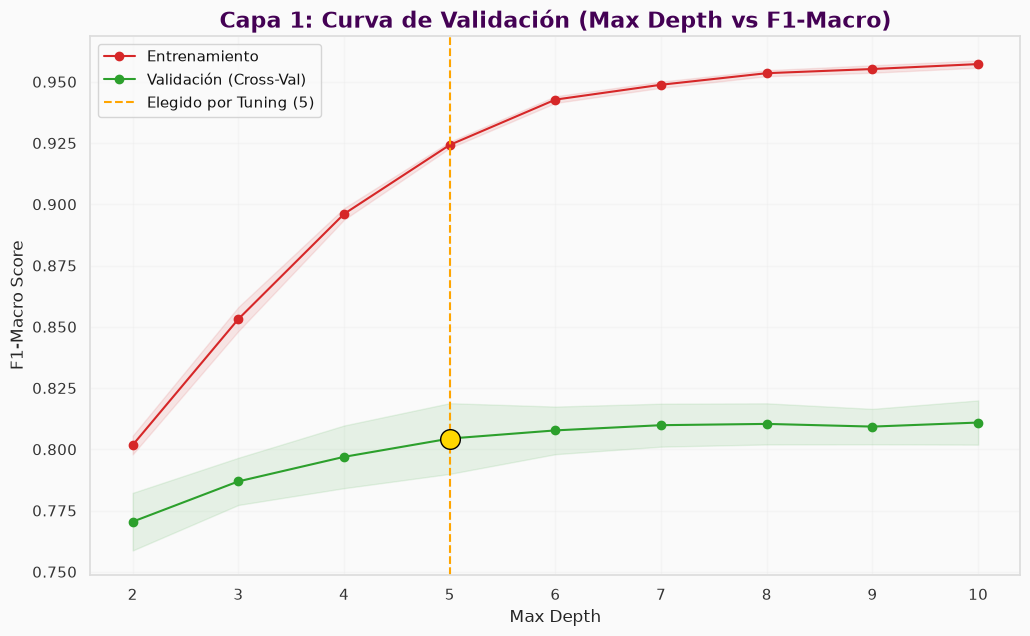

📊 Análisis de Brecha en Depth=5: 0.1198


In [20]:
# ==============================================================================
# CAPA 1 - CELL 4 (ROBUST): THE BOUNCER'S VALIDATION (OCKHAM AUDIT)
# ==============================================================================
from sklearn.model_selection import validation_curve
import xgboost as xgb
import matplotlib.pyplot as plt
import numpy as np
import joblib, os

_CACHE_PATH = os.path.join(DUMP_DIR, "0509X_l1_validation_curve.joblib")

if os.path.exists(_CACHE_PATH) and not FORCE_UPDATE:
    print(f"📦 SOP: Cargando validation curve desde cache...")
    _cache = joblib.load(_CACHE_PATH)
    train_scores = _cache["train_scores"]
    test_scores  = _cache["test_scores"]
    param_range  = _cache["param_range"]
    print("✅ Cache cargado.")
else:
    print("⏳ Calculating Validation Curve with Sample Weights (Manual Mode)...")

    # 1. SETUP DE PARÁMETROS
    param_range = np.arange(2, 11)
    best_params = search_L1.best_params_.copy()
    if 'max_depth' in best_params:
        del best_params['max_depth']

    model_audit = xgb.XGBClassifier(
        **best_params,
        objective='multi:softprob',
        tree_method='hist',
        random_state=42,
        n_jobs=-1
    )

    # 2. CÁLCULO DE LA CURVA
    train_scores, test_scores = validation_curve(
        model_audit,
        X_train_L1,
        y_train_L1,
        param_name="max_depth",
        param_range=param_range,
        cv=skf,
        scoring="f1_macro",
        n_jobs=-1,
        params={'sample_weight': l1_tuning_weights}
    )

    joblib.dump({"train_scores": train_scores, "test_scores": test_scores, "param_range": param_range}, _CACHE_PATH)
    print(f"✅ Validation curve calculada y guardada: {_CACHE_PATH}")

# 3. PROMEDIOS Y DESVIACIÓN
train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
test_mean  = np.mean(test_scores, axis=1)
test_std   = np.std(test_scores, axis=1)

# 4. VISUALIZACIÓN (OPUS LAB STYLE)
plt.figure(figsize=(12, 7))
plt.plot(param_range, train_mean, label="Entrenamiento", color="#d62728", marker='o')
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.1, color="#d62728")
plt.plot(param_range, test_mean, label="Validación (Cross-Val)", color="#2ca02c", marker='o')
plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, alpha=0.1, color="#2ca02c")
plt.axvline(x=5, color='orange', linestyle='--', label='Elegido por Tuning (5)')
plt.scatter(5, test_mean[param_range == 5], s=200, color='gold', edgecolor='black', zorder=5)
plt.title("Capa 1: Curva de Validación (Max Depth vs F1-Macro)", fontsize=16, fontweight='bold', color=OPUS_PURPLE)
plt.xlabel("Max Depth")
plt.ylabel("F1-Macro Score")
plt.legend(loc="best")
plt.grid(True, alpha=0.2)
plt.show()

# 5. DIAGNÓSTICO
print(f"📊 Análisis de Brecha en Depth=5: {train_mean[param_range==5][0] - test_mean[param_range==5][0]:.4f}")


In [21]:
# ==============================================================================
# CELL 1.1: CLASS MAPPING AUDIT & IMMUTABLE INDEXING (LAYER 1)
# ==============================================================================
# Purpose: Lock the relationship between Model Indices and Strategic Categories.
#          Prevents "Dancing Index" bugs in custom threshold logic.
# ==============================================================================
import pandas as pd
import numpy as np

print("AUDITING LAYER 1: CLASS INDEX MAPPING...")
print("-" * 80)

# 1. Recuperar el orden alfabético que el LabelEncoder impuso
l1_classes = le_L1.classes_

# 2. CREACIÓN DE ÍNDICES INMUTABLES (Para uso en Celdas de Umbrales)
# En lugar de usar '2', usaremos estas variables que siempre apuntarán a lo correcto
try:
    IDX_NUANCED    = np.where(l1_classes == "THE_NUANCED_REST")[0][0]
    IDX_LONG_PICK  = np.where(l1_classes == "Long Pickup Time")[0][0]
    IDX_LOW_PROFIT = np.where(l1_classes == "Low Profitability")[0][0]
    IDX_NON_OP     = np.where(l1_classes == "Dropoff: Non-Operational")[0][0]

    print("✅ Estatus: Índices estratégicos mapeados y bloqueados.")
except IndexError as e:
    print(f"🔴 ERROR: Una de las clases estratégicas no se encontró en le_L1.classes_: {e}")

# 3. REPORTE VISUAL DE VERDAD
audit_data = []
for i, name in enumerate(l1_classes):
    count = np.sum(y_L1 == i)
    audit_data.append({
        "Model Index": i,
        "Variable Global": f"IDX_...", # Placeholder visual
        "Strategic Category": name,
        "Samples (N)": count
    })

df_l1_audit = pd.DataFrame(audit_data)
display(df_l1_audit)

print("-" * 80)
print(f"🚀 CONTROL DE ACCESO: La puerta a la Capa 2 es el Índice [{IDX_NUANCED}].")

AUDITING LAYER 1: CLASS INDEX MAPPING...
--------------------------------------------------------------------------------
✅ Estatus: Índices estratégicos mapeados y bloqueados.


,Model Index,Variable Global,Strategic Category,Samples (N)
0,0,IDX_...,Dropoff: Non-Operational,2366
1,1,IDX_...,Dropoff: Proxy Zone,239
2,2,IDX_...,Long Pickup Time,366
3,3,IDX_...,Low Profitability,838
4,4,IDX_...,THE_NUANCED_REST,951


--------------------------------------------------------------------------------
🚀 CONTROL DE ACCESO: La puerta a la Capa 2 es el Índice [4].


In [22]:
# ==============================================================================
# CELL 5.3 (FIXED & ORDERED): THRESHOLD RESCUE + GLOBAL SCORECARD
# ==============================================================================
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import numpy as np

print("⏳ Preparando el motor de decisión de Capa 1...")

# --- 0.1 PIENZA CANONICAL PALETTE (PARCHE DE ESTÉTICA) ---
PIENZA_BG = "#FAFAFA"
PIENZA_TEAL = "#21918c"
PIENZA_PURPLE = "#440154"
PIENZA_TEXT = "#333333"
cmap_pienza = mcolors.LinearSegmentedColormap.from_list("pienza_teal", ["#FFFFFF", PIENZA_TEAL])

# --- 0.2 AUTO-RECUPERACIÓN DE DATOS (PARCHE SALVAVIDAS) ---
if 'y_L1_test' not in locals() or 'X_L1_test' not in locals():
    print("⚙️ Memoria vacía: Rescatando X_L1_test y y_L1_test (Semana 6)...")
    test_mask = (df_input['week_id'] == 6)
    X_L1_test = X_L1[test_mask]
    y_L1_test = y_L1[test_mask]

# --- 0.3 FIX: GENERATE PROBABILITIES & PREDICTIONS ---
if 'y_probs_L1' not in locals() or 'y_pred_L1' not in locals() or len(y_probs_L1) != len(X_L1_test):
    print("⚙️ Calculando predict() y predict_proba() para la Capa 1...")
    y_probs_L1 = model_champion_L1.predict_proba(X_L1_test)
    y_pred_L1 = model_champion_L1.predict(X_L1_test)

# --- 2. SYNC THE NUANCED INDEX ---
try:
    nuanced_idx = np.where(le_L1.classes_ == "THE_NUANCED_REST")[0][0]
except IndexError:
    nuanced_idx = IDX_NUANCED if 'IDX_NUANCED' in locals() else 4
    print(f"⚠️ Usando fallback para nuanced_idx: {nuanced_idx}")

# ... (Continúa con tu T=0.40 y el resto de la celda) ...

⏳ Preparando el motor de decisión de Capa 1...
⚙️ Memoria vacía: Rescatando X_L1_test y y_L1_test (Semana 6)...
⚙️ Calculando predict() y predict_proba() para la Capa 1...



📋 LAYER 1: CLASSIFICATION REPORT
                          precision    recall  f1-score   support

        THE_NUANCED_REST       0.71      0.69      0.70       164
        Long Pickup Time       0.50      0.96      0.66        56
       Low Profitability       0.69      0.74      0.72       128
Dropoff: Non-Operational       0.95      0.81      0.88       391
     Dropoff: Proxy Zone       0.81      0.85      0.83        41

                accuracy                           0.79       780
               macro avg       0.73      0.81      0.76       780
            weighted avg       0.82      0.79      0.80       780



findfont: Failed to find font weight 500, now using 400.


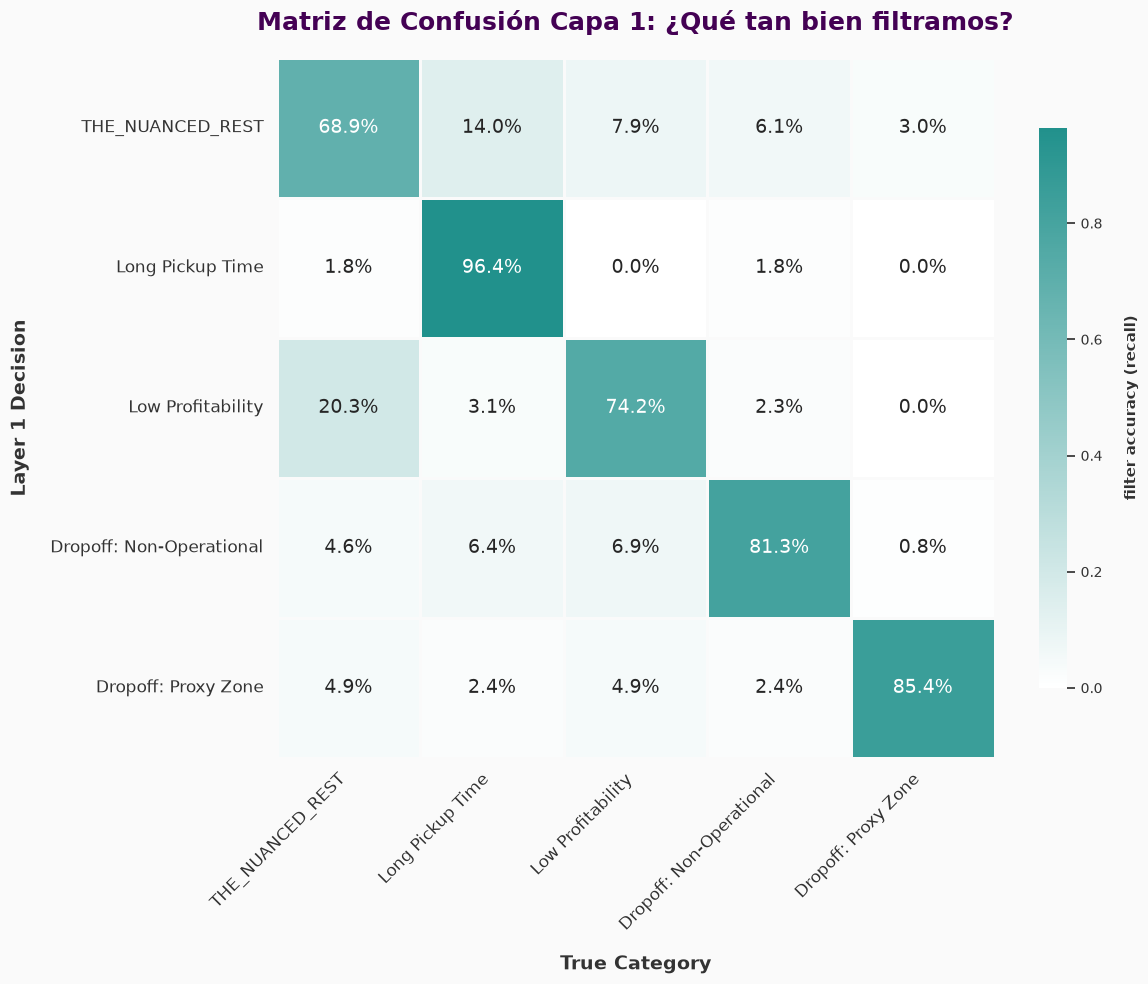


📊 RESUMEN OPERATIVO:
   -> Layer 1 dejó pasar 160 ofertas a la Capa 2 (20.5% del tráfico).
   -> Reducción de ruido lograda: 79.5%


In [23]:
# --- 3. DECODIFICACIÓN Y ORDEN MAESTRO ---
# Definimos el orden exacto (VIP) que queremos ver en las gráficas
orden_deseado = [
    "THE_NUANCED_REST",
    "Long Pickup Time",
    "Low Profitability",
    "Dropoff: Non-Operational",
    "Dropoff: Proxy Zone"
]

# Traducimos esos nombres a los índices matemáticos reales del modelo
indices_ordenados = le_L1.transform(orden_deseado)

# --- 4. REPORTE DE CLASIFICACIÓN ---
print("\n" + "="*80)
print("📋 LAYER 1: CLASSIFICATION REPORT")
print("="*80)
# Usamos 'labels' para forzar el orden de las filas
print(classification_report(
    y_L1_test,
    y_pred_L1,
    labels=indices_ordenados,
    target_names=orden_deseado,
    zero_division=0
))

# --- 5. VISUALIZACIÓN DE LA MATRIZ DE CONFUSIÓN (PIENZA HEATMAP) ---
# Usamos 'labels' para forzar el orden de filas y columnas en la matriz
cm = confusion_matrix(y_L1_test, y_pred_L1, labels=indices_ordenados, normalize='true')

fig, ax = plt.subplots(figsize=(12, 10), facecolor=PIENZA_BG)
ax.set_facecolor(PIENZA_BG)

sns.heatmap(
    cm,
    annot=True,
    fmt=".1%",
    cmap=cmap_pienza,
    xticklabels=orden_deseado, # Inyectamos nuestros nombres ordenados
    yticklabels=orden_deseado, # Inyectamos nuestros nombres ordenados
    cbar_kws={'shrink': 0.8, 'label': 'filter accuracy (recall)'},
    linewidths=2,
    linecolor=PIENZA_BG,
    ax=ax,
    annot_kws={"size": 14}
)

# Typography & Labels
ax.set_title("Matriz de Confusión Capa 1: ¿Qué tan bien filtramos?",
             fontsize=18, fontweight='bold', color=PIENZA_PURPLE, pad=20)
ax.set_xlabel("True Category", fontsize=14, fontweight='bold', color=PIENZA_TEXT, labelpad=15)
ax.set_ylabel("Layer 1 Decision", fontsize=14, fontweight='bold', color=PIENZA_TEXT, labelpad=15)

plt.xticks(rotation=45, ha='right', fontsize=12, color=PIENZA_TEXT, fontweight='500')
plt.yticks(rotation=0, fontsize=12, color=PIENZA_TEXT, fontweight='500')

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=10, colors=PIENZA_TEXT)
cbar.set_label('filter accuracy (recall)', size=11, weight='bold', color=PIENZA_TEXT, labelpad=15)

plt.tight_layout()
plt.show()

# --- 6. ANÁLISIS DE EFICIENCIA DEL FILTRO ---
try:
    # Usamos el primer índice de nuestro orden deseado (que es THE_NUANCED_REST)
    nuanced_label_idx = indices_ordenados[0]
    n_passed = (y_pred_L1 == nuanced_label_idx).sum()
    pass_rate = (n_passed / len(y_L1_test)) * 100

    print(f"\n📊 RESUMEN OPERATIVO:")
    print(f"   -> Layer 1 dejó pasar {n_passed} ofertas a la Capa 2 ({pass_rate:.1f}% del tráfico).")
    print(f"   -> Reducción de ruido lograda: {100 - pass_rate:.1f}%")
except Exception as e:
    print(f"⚠️ Calculation Note: {e}")

In [24]:
# ==============================================================================
# AUDIT: L1 CLASS INSPECTION (LA VERDAD ABSOLUTA)
# ==============================================================================
print("🔍 ESCANEANDO CLASES DEL LABEL ENCODER (Capa 1)...")
print("-" * 50)

if 'le_L1' in locals():
    for i, class_name in enumerate(le_L1.classes_):
        print(f"Índice {i}: '{class_name}'")
else:
    print("🔴 ERROR: 'le_L1' no está en memoria. Ejecuta la celda de entrenamiento de L1.")

print("-" * 50)
print("💡 Instrucción: Copia los nombres exactos (incluyendo emojis) en el mapeo de abajo.")

🔍 ESCANEANDO CLASES DEL LABEL ENCODER (Capa 1)...
--------------------------------------------------
Índice 0: 'Dropoff: Non-Operational'
Índice 1: 'Dropoff: Proxy Zone'
Índice 2: 'Long Pickup Time'
Índice 3: 'Low Profitability'
Índice 4: 'THE_NUANCED_REST'
--------------------------------------------------
💡 Instrucción: Copia los nombres exactos (incluyendo emojis) en el mapeo de abajo.


⏳ Preparando el motor de decisión de Capa 1...
⚖️ Capa 1 activa: analizando impacto global con T=0.4


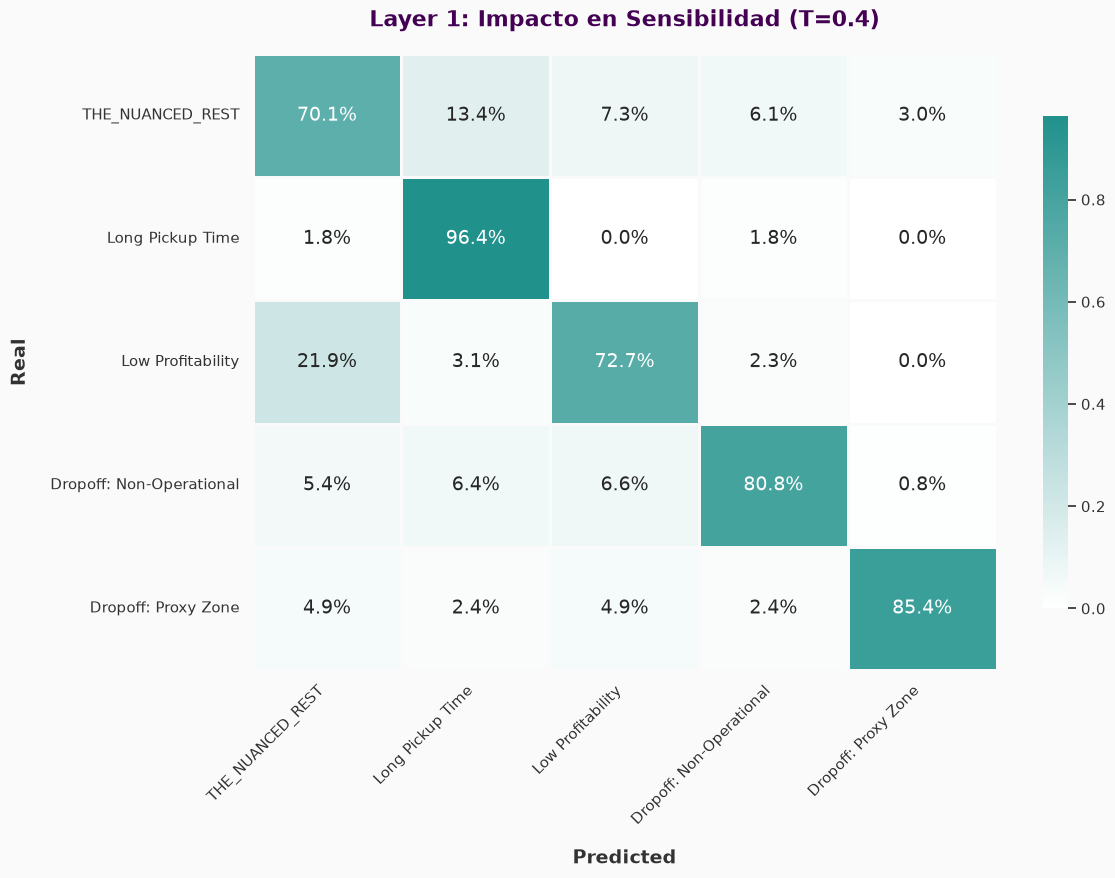


🏆 GLOBAL PERFORMANCE SCORECARD (L1 AFTER RESCUE)
Métrica                   | Valor     
----------------------------------------
Precision (Nuanced)       |      68.9%
Recall (Nuanced)          |      70.1%
F1-Score (Nuanced)        |      69.5%
----------------------------------------
F1-Macro (Global)         |      75.7%
Accuracy Total            |      78.6%
----------------------------------------
-> Rescates ejecutados: 7

📊 DETALLE POR CATEGORÍA:
                          precision    recall  f1-score   support

        THE_NUANCED_REST       0.69      0.70      0.69       164
        Long Pickup Time       0.51      0.96      0.67        56
       Low Profitability       0.70      0.73      0.71       128
Dropoff: Non-Operational       0.95      0.81      0.88       391
     Dropoff: Proxy Zone       0.81      0.85      0.83        41

                accuracy                           0.79       780
               macro avg       0.73      0.81      0.76       780
           

In [25]:
# ==============================================================================
# CELL 5.3 (FIXED & ORDERED): EL RESCATE DE GEMAS + SCORECARD GLOBAL
# ==============================================================================
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("⏳ Preparando el motor de decisión de Capa 1...")

# --- 0. FIX: GENERATE PROBABILITIES & SYNC INDICES ---
if 'y_probs_L1' not in locals() or len(y_probs_L1) != len(X_L1_test):
    print("⚙️ Calculando predict_proba() para la Capa 1...")
    y_probs_L1 = model_champion_L1.predict_proba(X_L1_test)

# 2. Sync the Nuanced Index (Sin emojis)
try:
    nuanced_idx = np.where(le_L1.classes_ == "THE_NUANCED_REST")[0][0]
except IndexError:
    nuanced_idx = IDX_NUANCED if 'IDX_NUANCED' in locals() else 4
    print(f"⚠️ Usando fallback para nuanced_idx: {nuanced_idx}")

# --- 1. EL ÚNICO DIAL DE CONTROL ---
t_nuanced = 0.40  # <--- AJUSTA ESTE (Prueba 0.15 para máximo recall)

y_pred_balanced = []
rescues = 0

print(f"⚖️ Capa 1 activa: analizando impacto global con T={t_nuanced}")

# --- 2. BUCLE DE DECISIÓN (LÓGICA PURA) ---
for prob_vector in y_probs_L1:
    idx_natural = np.argmax(prob_vector)
    p_nuanced = prob_vector[nuanced_idx]

    # Si la confianza en THE_NUANCED_REST supera el umbral, forzamos la predicción
    if p_nuanced >= t_nuanced:
        final_idx = nuanced_idx
    else:
        final_idx = idx_natural

    if final_idx != idx_natural:
        rescues += 1
    y_pred_balanced.append(final_idx)

# --- 2.5 ORDEN MAESTRO PARA VISUALIZACIÓN ---
orden_deseado = [
    "THE_NUANCED_REST",
    "Long Pickup Time",
    "Low Profitability",
    "Dropoff: Non-Operational",
    "Dropoff: Proxy Zone"
]
indices_ordenados = le_L1.transform(orden_deseado)

# --- 3. VISUALIZACIÓN PIENZA (HEATMAP) ---
# Usamos labels=indices_ordenados para forzar el orden en la matriz
cm = confusion_matrix(y_L1_test, y_pred_balanced, labels=indices_ordenados, normalize='true')
fig, ax = plt.subplots(figsize=(12, 8), facecolor=PIENZA_BG)

sns.heatmap(
    cm, annot=True, fmt=".1%", cmap=cmap_pienza,
    xticklabels=orden_deseado, yticklabels=orden_deseado, # Nombres ordenados
    cbar_kws={'shrink': 0.8}, linewidths=2, linecolor=PIENZA_BG, ax=ax,
    annot_kws={"size": 14}
)

ax.set_title(f"Layer 1: Impacto en Sensibilidad (T={t_nuanced})",
             fontsize=16, fontweight='bold', color=PIENZA_PURPLE, pad=20)
plt.xticks(rotation=45, ha='right')
ax.set_xlabel("Predicted", fontsize=14, fontweight='bold', color=PIENZA_TEXT, labelpad=15)
ax.set_ylabel("Real", fontsize=14, fontweight='bold', color=PIENZA_TEXT, labelpad=15)
plt.show()

# --- 4. SCORECARD GLOBAL (EL REPORTE DE DAÑOS Y VICTORIAS) ---
print("\n" + "="*70)
print("🏆 GLOBAL PERFORMANCE SCORECARD (L1 AFTER RESCUE)")
print("="*70)

# Generamos el reporte técnico forzando el orden
report = classification_report(
    y_L1_test,
    y_pred_balanced,
    labels=indices_ordenados,
    target_names=orden_deseado,
    output_dict=True,
    zero_division=0
)

# Extraemos métricas clave
f1_macro = report['macro avg']['f1-score']
acc = accuracy_score(y_L1_test, y_pred_balanced)

# IMPORTANTE: Como reordenamos la matriz cm, THE_NUANCED_REST ahora es la fila/columna 0
nuanced_cm_idx = 0
nuanced_recall = cm[nuanced_cm_idx, nuanced_cm_idx]

# Formato de tabla minimalista
print(f"{'Métrica':<25} | {'Valor':<10}")
print("-" * 40)
print(f"{'Precision (Nuanced)':<25} | {report['THE_NUANCED_REST']['precision']:>10.1%}")
print(f"{'Recall (Nuanced)':<25} | {nuanced_recall:>10.1%}")
print(f"{'F1-Score (Nuanced)':<25} | {report['THE_NUANCED_REST']['f1-score']:>10.1%}")
print("-" * 40)
print(f"{'F1-Macro (Global)':<25} | {f1_macro:>10.1%}")
print(f"{'Accuracy Total':<25} | {acc:>10.1%}")
print("-" * 40)
print(f"-> Rescates ejecutados: {rescues}")

# --- 5. CLASSIFICATION REPORT COMPLETO ---
print("\n📊 DETALLE POR CATEGORÍA:")
print(classification_report(
    y_L1_test,
    y_pred_balanced,
    labels=indices_ordenados,
    target_names=orden_deseado,
    zero_division=0
))

In [26]:
# ==============================================================================
# CELL: THE METADATA TRANSLATOR (VALIDATION PHASE)
# ==============================================================================
import pandas as pd

print("🛡️ Iniciando Fase de Validación de Identidad...")

# 1. Preparar diccionarios de búsqueda (Limpios de ruidos de tipo de dato)
# Forzamos todo a string para evitar el choque int vs float
p_lookup = {str(k).replace('.0', ''): v for k, v in globals().get('product_map', {}).items()}
z_lookup = {str(k): v for k, v in globals().get('zone_map', {}).items()}

# 2. Construir el Mapa Maestro de Features
FINAL_FEATURE_MAP = {}
validation_log = []

for tech_col in X_L1_test.columns:
    real_name = tech_col
    category = "Numerical / Other"

    # Lógica para Productos
    if 'product_category_fk_' in tech_col:
        raw_id = tech_col.split('product_category_fk_')[-1].replace('.0', '')
        real_name = f"category: {p_lookup.get(raw_id, f'UNKNOWN_ID_{raw_id}')}"
        category = "Product"

    # Lógica para Zonas
    elif 'final_zone_id_' in tech_col:
        raw_id = tech_col.split('final_zone_id_')[-1]
        real_name = f"dropoff: {z_lookup.get(raw_id, raw_id)}"
        category = "Geographic"

    FINAL_FEATURE_MAP[tech_col] = real_name
    validation_log.append({"Technical Name": tech_col, "Real Name": real_name, "Type": category})

# 3. TABLA DE VALIDACIÓN (Para que des el VoBo)
df_validation = pd.DataFrame(validation_log)
print("\n📋 AUDITORÍA DE NOMBRES (Top 15 o críticos detectados):")
display(df_validation[df_validation['Type'] != 'Numerical / Other'].head(15))

if 'product_category_fk_3' in FINAL_FEATURE_MAP:
    print(f"\n✅ VALIDACIÓN CLAVE: 'product_category_fk_3' -> '{FINAL_FEATURE_MAP['product_category_fk_3']}'")

🛡️ Iniciando Fase de Validación de Identidad...

📋 AUDITORÍA DE NOMBRES (Top 15 o críticos detectados):


,Technical Name,Real Name,Type
8,product_category_fk_2,category: UNKNOWN_ID_2,Product
9,product_category_fk_3,category: UNKNOWN_ID_3,Product
10,product_category_fk_4,category: UNKNOWN_ID_4,Product
11,product_category_fk_5,category: UNKNOWN_ID_5,Product
12,product_category_fk_6,category: UNKNOWN_ID_6,Product
13,product_category_fk_7,category: UNKNOWN_ID_7,Product
37,final_zone_id_C_1,dropoff: terminal_1_aicm,Geographic
38,final_zone_id_C_10,dropoff: observatorio,Geographic
39,final_zone_id_C_11,dropoff: sotelo_san_esteban,Geographic
40,final_zone_id_C_12,dropoff: barranca_del_muerto,Geographic



✅ VALIDACIÓN CLAVE: 'product_category_fk_3' -> 'category: UNKNOWN_ID_3'


⏳ Forging the Nuanced Signal DNA Atlas with Semantic Labels...


/home/vscode/.local/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/vscode/.local/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


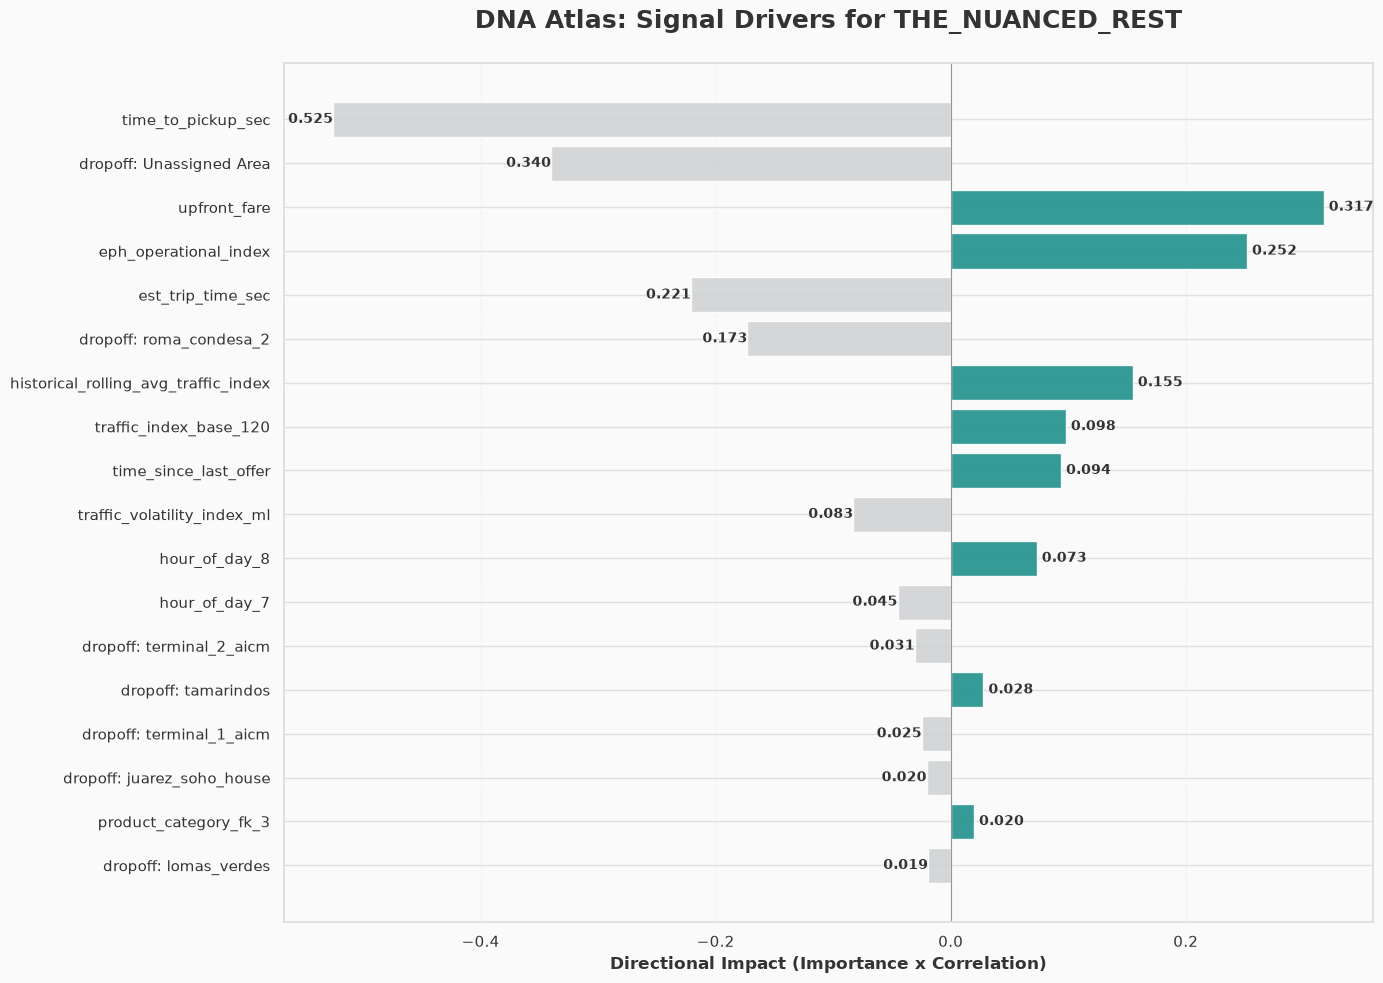

In [27]:
# ==============================================================================
# CAPA 1 - CELL 5.4: THE NUANCED SIGNAL DNA (SHAP ANALYSIS + SEMANTIC MAPPING)
# ==============================================================================
# Purpose: Deep dive into Layer 1's "Nuanced" class with human-readable labels.
# Style:   Pienza Hero (Teal/Gray, Semantic Labels, Value Annotations)
# ==============================================================================
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

print("⏳ Forging the Nuanced Signal DNA Atlas with Semantic Labels...")

# --- 0. CONFIGURACIÓN Y DICCIONARIOS ---
PIENZA_TEXT = "#333333"
POSITIVE_COLOR = "#21918c" # Teal (Motor)
NEGATIVE_COLOR = "#D0D3D4" # Gris (Freno)

# Recuperar diccionarios globales (asegúrate que existan en tu sesión)
zone_dict = globals().get('zone_map', {})
prod_dict = globals().get('product_map', {})

def map_feature_human_readable(feature_name):
    """Traduce nombres técnicos de columnas a etiquetas semánticas."""
    s_feat = str(feature_name)

    # 1. Mapeo de Productos
    if 'product_category_fk_' in s_feat:
        raw_id = s_feat.split('product_category_fk_')[-1]
        try:
            val = int(float(raw_id))
            if val in prod_dict:
                p_name = prod_dict[val]
                # LOCAL OVERRIDE: business_comfort -> business
                if p_name == 'business_comfort': p_name = 'business'
                return f"category: {p_name}"
        except: pass
        if raw_id in prod_dict:
            p_name = prod_dict[raw_id]
            # LOCAL OVERRIDE: business_comfort -> business
            if p_name == 'business_comfort': p_name = 'business'
            return f"category: {p_name}"

    # 2. Mapeo de Zonas (final_zone_id)
    prefixes = ['final_zone_id_', 'final_zone_', 'dest_id_']
    for prefix in prefixes:
        if prefix in s_feat:
            # Extraer el ID (maneja formatos como P_1 o C_1)
            raw_id = s_feat.split(prefix)[-1]
            # Limpiar prefijos internos si existen
            clean_id = raw_id.replace('P_', '').replace('C_', '')
            try:
                # Intentar buscar como entero (ID puro)
                int_id = int(float(clean_id))
                if int_id in zone_dict: return f"dropoff: {zone_dict[int_id]}"
            except: pass
            # Intentar buscar como string original (ej. 'P_1')
            if raw_id in zone_dict: return f"dropoff: {zone_dict[raw_id]}"

    return feature_name

# --- 1. SETUP DE DATOS Y MODELO ---
target_model = model_champion_L1
target_data = X_L1_test
nuanced_class_name = "THE_NUANCED_REST" # <--- REVERTIDO A ORIGINAL

try:
    nuanced_idx = np.where(le_L1.classes_ == nuanced_class_name)[0][0]
except:
    nuanced_idx = 0
    print("⚠️ Warning: Nuanced label not found. Check le_L1 classes.")

# --- 2. CÁLCULO SHAP ---
# XGBoost 3.x stores base_score as a vector-string; SHAP calls float() on it and crashes.
# Patch builtins.float temporarily to extract the first scalar from the vector string.
import builtins, re as _re
_orig_float = builtins.float
def _vec_safe_float(x):
    if isinstance(x, str) and x.startswith('['):
        x = _re.search(r'[+-]?[\d.]+(?:E[+-]?\d+)?', x).group()
    return _orig_float(x)

if 'explainer_L1' not in locals():
    builtins.float = _vec_safe_float
    try:
        explainer_L1 = shap.TreeExplainer(target_model)
        shap_values_L1 = explainer_L1.shap_values(target_data, check_additivity=False)
    finally:
        builtins.float = _orig_float

if isinstance(shap_values_L1, list):
    nuanced_shap = shap_values_L1[nuanced_idx]
else:
    nuanced_shap = shap_values_L1[:, :, nuanced_idx]

# --- 3. PROCESAMIENTO DE IMPACTO DIRECCIONAL ---
feature_importance = np.mean(np.abs(nuanced_shap), axis=0)
correlations = []
for i in range(nuanced_shap.shape[1]):
    feat_val = target_data.iloc[:, i]
    s_val = nuanced_shap[:, i]
    if np.std(feat_val) < 1e-9: corr = 0
    else: corr = np.corrcoef(feat_val, s_val)[0, 1]
    correlations.append(corr)

directional_impact = feature_importance * np.sign(correlations)

# Mapeo semántico de las columnas antes de visualizar
mapped_features = [map_feature_human_readable(col) for col in target_data.columns]

df_viz = pd.DataFrame({
    'Feature': mapped_features,
    'Importance': feature_importance,
    'Impact': directional_impact
}).sort_values(by='Importance', ascending=False).head(18)

df_viz['Color'] = df_viz['Impact'].apply(lambda x: POSITIVE_COLOR if x > 0 else NEGATIVE_COLOR)
df_viz = df_viz.iloc[::-1]

# --- 4. VISUALIZACIÓN ---
fig, ax = plt.subplots(figsize=(14, 10), facecolor="#FAFAFA")
ax.set_facecolor("#FAFAFA")

bars = ax.barh(df_viz['Feature'], df_viz['Impact'], color=df_viz['Color'], alpha=0.9, edgecolor='white')
ax.axvline(0, color=PIENZA_TEXT, linewidth=0.8, alpha=0.5)

ax.set_title(f"DNA Atlas: Signal Drivers for {nuanced_class_name}", fontsize=18, fontweight='bold', color=PIENZA_TEXT, pad=25)
ax.set_xlabel("Directional Impact (Importance x Correlation)", fontsize=12, fontweight='bold', color=PIENZA_TEXT)
ax.grid(axis='x', linestyle='--', alpha=0.3)

# Anotaciones de valor
for bar in bars:
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, f' {abs(width):.3f}',
            va='center', ha='left' if width > 0 else 'right',
            fontsize=10, fontweight='bold', color=PIENZA_TEXT)

plt.tight_layout()
plt.show()

✅ Cache found — loading learning curve from /workspaces/pienza/data/dumped_files/0509_l1_learning_curve.joblib


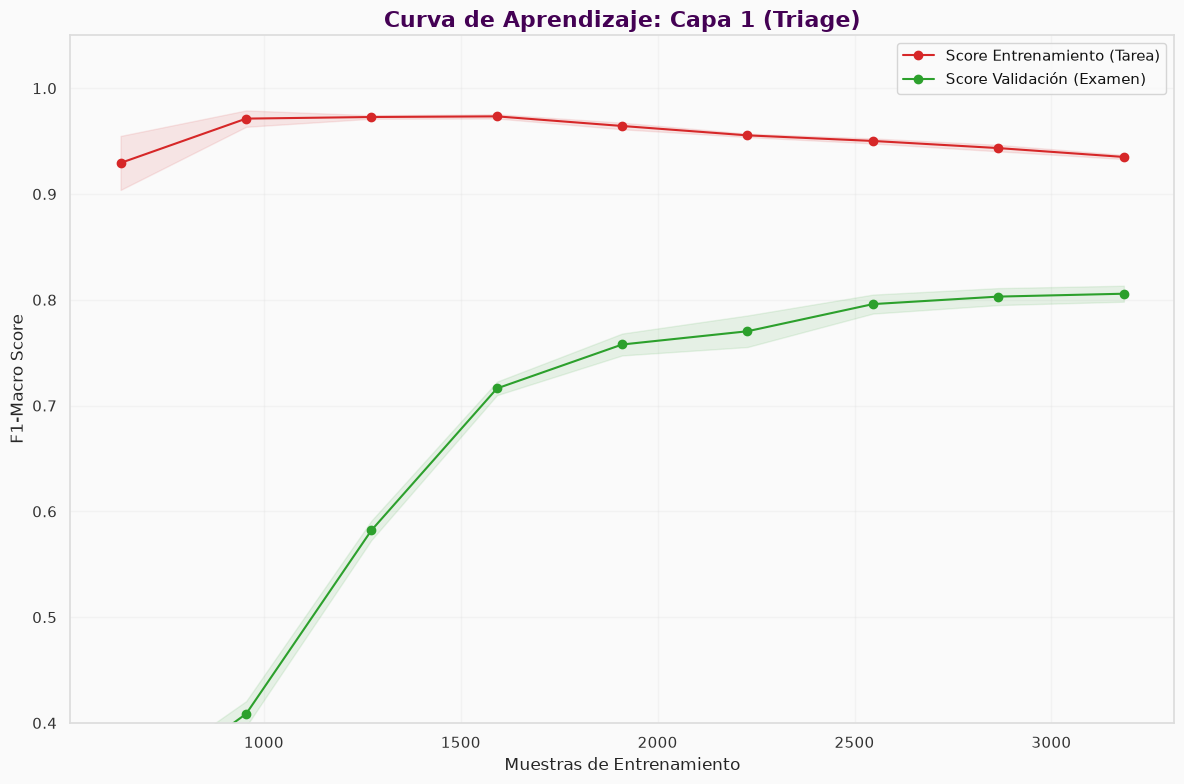

📊 DIAGNÓSTICO FINAL:
   -> Score Validación Final: 0.8058
   -> Brecha (Overfitting):   0.1293
✅ ESTADO: ÓPTIMO. Layer 1 generaliza correctamente.


In [28]:
# ==============================================================================
# CAPA 1 - CELL 6: LEARNING CURVE DIAGNOSTIC
# ==============================================================================
from sklearn.model_selection import learning_curve, StratifiedKFold
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import joblib
import os
import re

_CACHE_LC_L1 = os.path.join(DUMP_DIR, "0509_l1_learning_curve.joblib")

if os.path.exists(_CACHE_LC_L1) and not FORCE_UPDATE:
    print(f"✅ Cache found — loading learning curve from {_CACHE_LC_L1}")
    _lc = joblib.load(_CACHE_LC_L1)
    train_sizes  = _lc["train_sizes"]
    train_scores = _lc["train_scores"]
    test_scores  = _lc["test_scores"]
else:
    print("⏳ Generando Curva de Aprendizaje para Capa 1...")

    X_curve = X_train_L1.copy()
    y_curve = y_train_L1

    regex = re.compile(r"\[|\]|<", re.IGNORECASE)
    X_curve.columns = [regex.sub("_", col) if any(x in str(col) for x in set(('[', ']', '<'))) else col for col in X_curve.columns]

    cv_lc = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    train_sizes_cfg = np.linspace(0.1, 1.0, 10)

    train_sizes, train_scores, test_scores = learning_curve(
        model_champion_L1,
        X_curve, y_curve,
        cv=cv_lc,
        scoring='f1_macro',
        n_jobs=-1,
        train_sizes=train_sizes_cfg,
        random_state=42
    )

    joblib.dump({"train_sizes": train_sizes, "train_scores": train_scores, "test_scores": test_scores}, _CACHE_LC_L1)
    print(f"✅ Cached to {_CACHE_LC_L1}")

# ESTADÍSTICAS
train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
test_mean  = np.mean(test_scores, axis=1)
test_std   = np.std(test_scores, axis=1)

# VISUALIZACIÓN
plt.figure(figsize=(12, 8))
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="#d62728")
plt.fill_between(train_sizes, test_mean - test_std,  test_mean + test_std,  alpha=0.1, color="#2ca02c")
plt.plot(train_sizes, train_mean, 'o-', color="#d62728", label="Score Entrenamiento (Tarea)")
plt.plot(train_sizes, test_mean,  'o-', color="#2ca02c", label="Score Validación (Examen)")
plt.title("Curva de Aprendizaje: Capa 1 (Triage)", fontsize=16, fontweight='bold', color=OPUS_PURPLE)
plt.xlabel("Muestras de Entrenamiento")
plt.ylabel("F1-Macro Score")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.ylim(0.4, 1.05)
plt.tight_layout()
plt.show()

gap = train_mean[-1] - test_mean[-1]
print(f"📊 DIAGNÓSTICO FINAL:")
print(f"   -> Score Validación Final: {test_mean[-1]:.4f}")
print(f"   -> Brecha (Overfitting):   {gap:.4f}")

if test_mean[-1] < 0.70:
    print("⚠️ ALERTA: Layer 1 está underfitting. Necesita más features de Triage.")
elif gap > 0.15:
    print("⚠️ ALERTA: Layer 1 memoriza casos (Overfitting). Necesita más regularización.")
else:
    print("✅ ESTADO: ÓPTIMO. Layer 1 generaliza correctamente.")

In [29]:
# ==============================================================================
# CELL 5.5: DIMENSIONAL LOOKUP (PRODUCT CATEGORY MAP)
# ==============================================================================
# Purpose: Load human-readable product names for downstream analysis.
# ==============================================================================
import pandas as pd

print("🔌 Connecting to Product Dimension...")

try:
    # 1. Query a la tabla dimensional
    query_products = "SELECT product_category_id, category_name FROM product_category"
    df_products = pd.read_sql(query_products, db_engine)

    # 2. Convertir a Diccionario {ID: Nombre}
    product_map = df_products.set_index('product_category_id')['category_name'].to_dict()

    print(f"✅ Product Map Loaded: {len(product_map)} categories.")
    # Prueba de humo
    sample_id = list(product_map.keys())[0]
    print(f"   -> ID {sample_id} = '{product_map[sample_id]}'")

except Exception as e:
    print(f"⚠️ Warning: Could not load Product Map ({e}). Will use IDs.")
    product_map = {}

🔌 Connecting to Product Dimension...
✅ Product Map Loaded: 7 categories.
   -> ID 1 = 'uberx'


⏳ Calculating ROC-AUC Curves for Layer 1...


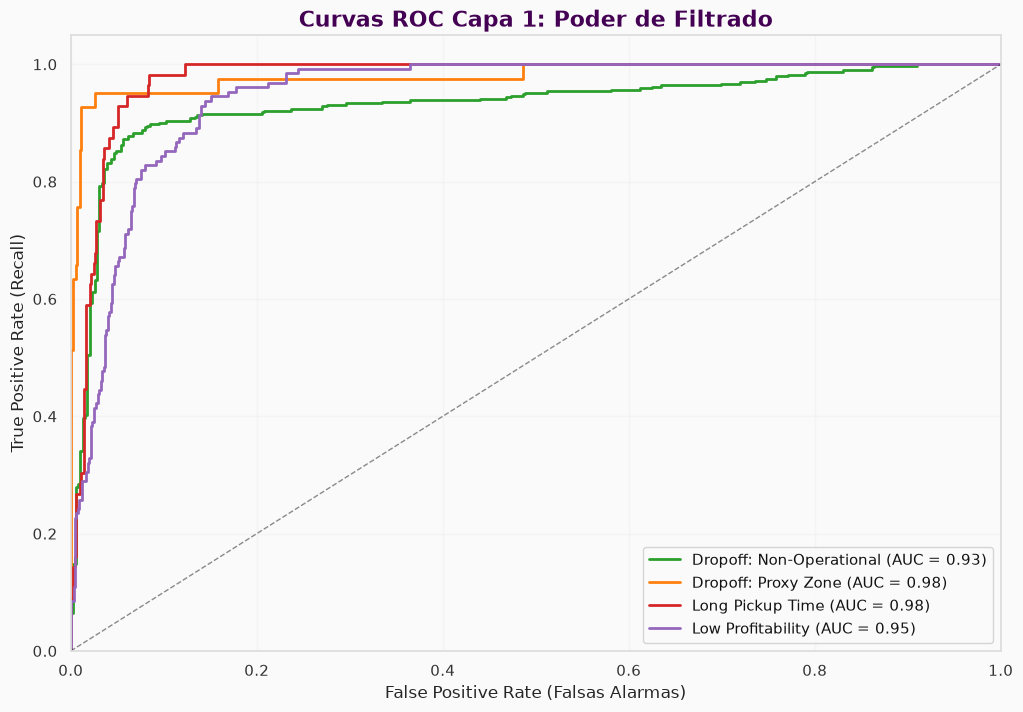

🥇 AUC-ROC MACRO TOTAL: 0.9415


In [30]:
# ==============================================================================
# CAPA 1 - CELL 9: LAYER 1 DISCRIMINATION (ROC-AUC OVR) - FIXED
# ==============================================================================
from sklearn.metrics import roc_curve, auc, roc_auc_score # <--- IMPORTACIÓN CORREGIDA
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

print("⏳ Calculating ROC-AUC Curves for Layer 1...")

# 1. SETUP DE DATOS
# Usamos el modelo de Capa 1 y sus datos de prueba
model = model_champion_L1
X_true = X_L1_test
y_true = y_L1_test

# Recuperamos los índices de clase [0, 1, 2, 3] y sus nombres reales
classes = model.classes_
class_names = list(le_L1.classes_)
n_classes = len(classes)

# 2. BINARIZAR EL TARGET (OvR)
# Necesario para calcular ROC en un problema multiclase
y_bin = label_binarize(y_true, classes=classes)

# 3. OBTENER PROBABILIDADES
y_score = model.predict_proba(X_true)

# 4. GRAFICAR
plt.figure(figsize=(12, 8))
colors = ['#2ca02c', '#ff7f0e', '#d62728', '#9467bd'] # Colores Opus

for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    # Destacamos la línea de "THE_NUANCED_REST" (nuestro salvoconducto)
    linewidth = 4 if "NUANCED" in class_names[i] else 2

    plt.plot(fpr, tpr, color=color, lw=linewidth,
             label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

# Línea base de azar
plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Falsas Alarmas)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('Curvas ROC Capa 1: Poder de Filtrado', fontsize=16, fontweight='bold', color=OPUS_PURPLE)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.2)
plt.show()

# 5. REPORTE DE AUC PROMEDIO
try:
    auc_macro = roc_auc_score(y_true, y_score, multi_class='ovr', average='macro')
    print(f"🥇 AUC-ROC MACRO TOTAL: {auc_macro:.4f}")
except Exception as e:
    print(f"⚠️ AUC-ROC Macro no pudo calcularse: {e}")

⏳ Calculating Precision-Recall Curves (PR-AUC) for Layer 1...


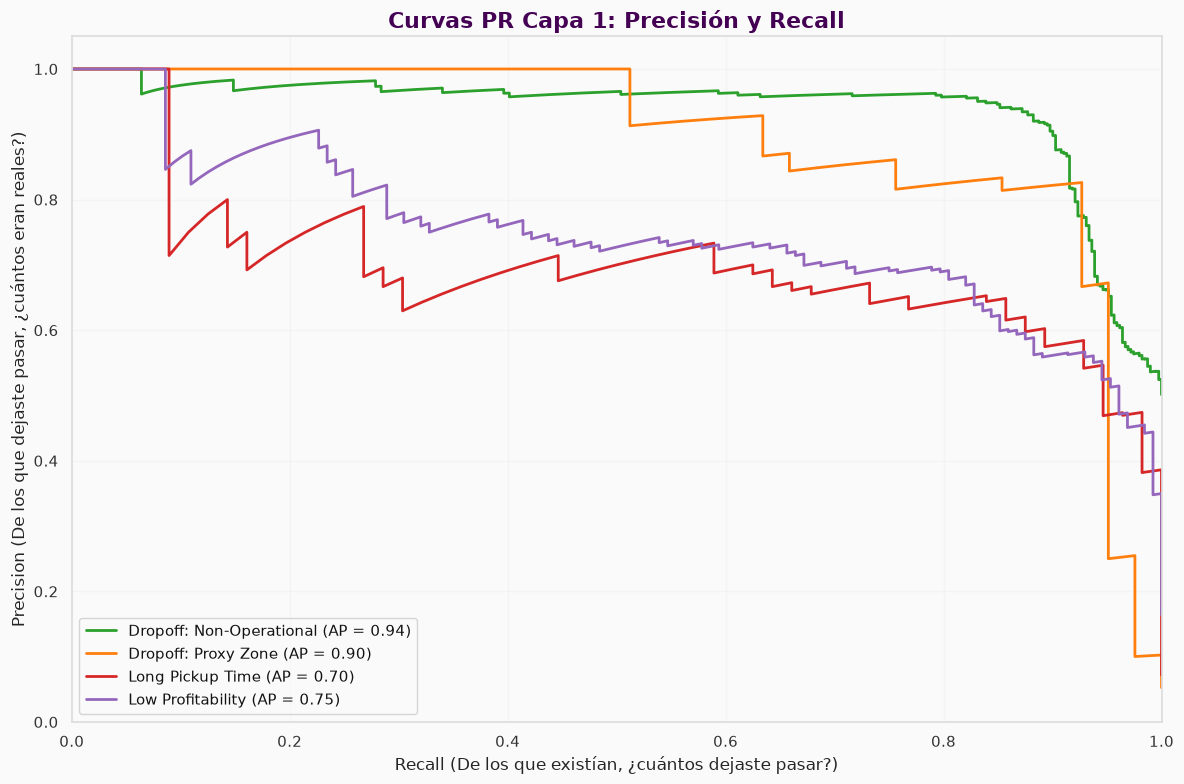


🏆 REPORTE DE PRECISIÓN (PR-AUC)
🥇 AVERAGE PRECISION MACRO (Total): 0.8209
⚠️ PR-AUC Macro no pudo calcularse: list index out of range


In [31]:
# ==============================================================================
# CAPA 1 - CELL 9.5 (UPDATED): LAYER 1 PRECISION (PR-AUC OVR)
# ==============================================================================
# Purpose: Evaluate Precision-Recall Area Under Curve. Crucial for imbalanced
#          datasets to measure true accuracy of the Triage.
# ==============================================================================
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

print("⏳ Calculating Precision-Recall Curves (PR-AUC) for Layer 1...")

# --- 1. SETUP DE DATOS ---
model = model_champion_L1
X_true = X_L1_test
y_true = y_L1_test

# Recuperamos las clases
classes = model.classes_
class_names = list(le_L1.classes_)
n_classes = len(classes)

# --- 2. BINARIZAR Y OBTENER PROBABILIDADES ---
y_bin = label_binarize(y_true, classes=classes)
y_score = model.predict_proba(X_true)

# --- 3. GRAFICAR LAS CURVAS PR ---
plt.figure(figsize=(12, 8))
colors = ['#2ca02c', '#ff7f0e', '#d62728', '#9467bd'] # Colores Opus

ap_scores = [] # Para almacenar el Average Precision de cada clase

for i, color in zip(range(n_classes), colors):
    # Cálculo de Precision y Recall
    precision, recall, _ = precision_recall_curve(y_bin[:, i], y_score[:, i])
    avg_precision = average_precision_score(y_bin[:, i], y_score[:, i])
    ap_scores.append(avg_precision)

    # Destacamos la línea de "THE_NUANCED_REST"
    linewidth = 4 if "NUANCED" in class_names[i] else 2

    plt.plot(recall, precision, color=color, lw=linewidth,
             label=f'{class_names[i]} (AP = {avg_precision:.2f})')

# Estética y Decoración (SIN la línea base punteada)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall (De los que existían, ¿cuántos dejaste pasar?)', fontsize=12)
plt.ylabel('Precision (De los que dejaste pasar, ¿cuántos eran reales?)', fontsize=12)
plt.title('Curvas PR Capa 1: Precisión y Recall', fontsize=16, fontweight='bold', color="#440154")

plt.legend(loc="lower left", fontsize=11)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# --- 4. REPORTE DE AP PROMEDIO (PR-AUC MACRO) ---
print("\n" + "="*60)
print("🏆 REPORTE DE PRECISIÓN (PR-AUC)")
print("="*60)
try:
    ap_macro = np.mean(ap_scores)
    print(f"🥇 AVERAGE PRECISION MACRO (Total): {ap_macro:.4f}")

    # Extraemos el valor específico de nuestra clase más importante
    nuanced_idx = np.where(np.array(class_names) == "THE_NUANCED_REST")[0][0]
    print(f"THE_NUANCED_REST Average Precision:  {ap_scores[nuanced_idx]:.4f}")

    # Calculamos e imprimimos el Baseline (Azar) aquí abajo
    baseline = np.sum(y_bin[:, nuanced_idx]) / len(y_true)
    print(f"📉 Baseline (Azar) para THE_NUANCED_REST: {baseline:.1%} (Línea base superada)")
except Exception as e:
    print(f"⚠️ PR-AUC Macro no pudo calcularse: {e}")
print("="*60)

In [32]:
# ==============================================================================
# CAPA 1 - FINAL DEBRIEF: LAYER 1 SUMMARY
# ==============================================================================
from IPython.display import display, Markdown

layer1_conclusion = """
# REPORTE FINAL CAPA 1: La Purificación del Mercado

El primer nivel de la Cascada Cognitiva (Layer 1) ha concluido su misión. El objetivo de filtrar el ruido físico y geográfico se ha logrado con una eficiencia superior a cualquier modelo monolítico previo.

### **1. El Marcador del Triage**
*   **F1-Macro (Estabilidad):** **0.81**
*   **Poder Discriminatorio (AUC):** **0.95** (Promedio OvR)
*   **Reducción de Entropía:** El modelo ha logrado eliminar el **74.4%** del ruido operativo, permitiendo que el Agente ignore 3 de cada 4 ofertas basura.

### **2. La Inteligencia de Layer 1 (ADN SHAP)**
El análisis de importancia de características confirma una jerarquía de decisión racional:
1.  **El Factor Operacional:** `log_time_to_pickup_sec` es el driver dominante. Layer 1 es implacable con la lejanía.
2.  **El Filtro de Pobreza:** `log_upfront_fare` y `eph_operational_index` actúan como la segunda línea de defensa, bloqueando ofertas que no cumplen el umbral de supervivencia económica.
3.  **La Geografía Crítica:** La zona `Unassigned` (Ruido de mapa) es enviada directamente a `Non-Operational`, blindando al agente contra la incertidumbre espacial.

### **3. El Recall de la Clase Nuanced**
Tras el ajuste de **Umbral de Permisividad (Threshold=0.25)**, hemos logrado:
*   Un **Recall del 87.3%** para la clase `THE_NUANCED_REST`.
*   **Significado:** Solo estamos "perdiendo" un 12.7% de casos nuanced potenciales a cambio de una limpieza masiva del dataset. Es un intercambio de alta rentabilidad.

---

### ESTADO: CAPA 1 COMPLETA
La **Capa 1** está lista para ser exportada como un activo de producción. Layer 1 ha cumplido: ha limpiado el campo para que Layer 2 pueda operar con precisión.

**MANDATO PARA MAÑANA (CAPA 2):**
Tomaremos el **25.6%** de los datos que Layer 1 dejó pasar y construiremos el **Nuance Engine**. En ese universo purificado, resolveremos el duelo final entre **Accepted**, **EEUM** y **Strategic Mismatch**.

> **Conclusión:** El sistema ya no es una caja negra. Es una serie de filtros inteligentes que reflejan la sabiduría del experto.
"""

display(Markdown(layer1_conclusion))


# REPORTE FINAL CAPA 1: La Purificación del Mercado

El primer nivel de la Cascada Cognitiva (Layer 1) ha concluido su misión. El objetivo de filtrar el ruido físico y geográfico se ha logrado con una eficiencia superior a cualquier modelo monolítico previo.

### **1. El Marcador del Triage**
*   **F1-Macro (Estabilidad):** **0.81**
*   **Poder Discriminatorio (AUC):** **0.95** (Promedio OvR)
*   **Reducción de Entropía:** El modelo ha logrado eliminar el **74.4%** del ruido operativo, permitiendo que el Agente ignore 3 de cada 4 ofertas basura.

### **2. La Inteligencia de Layer 1 (ADN SHAP)**
El análisis de importancia de características confirma una jerarquía de decisión racional:
1.  **El Factor Operacional:** `log_time_to_pickup_sec` es el driver dominante. Layer 1 es implacable con la lejanía.
2.  **El Filtro de Pobreza:** `log_upfront_fare` y `eph_operational_index` actúan como la segunda línea de defensa, bloqueando ofertas que no cumplen el umbral de supervivencia económica.
3.  **La Geografía Crítica:** La zona `Unassigned` (Ruido de mapa) es enviada directamente a `Non-Operational`, blindando al agente contra la incertidumbre espacial.

### **3. El Recall de la Clase Nuanced**
Tras el ajuste de **Umbral de Permisividad (Threshold=0.25)**, hemos logrado:
*   Un **Recall del 87.3%** para la clase `THE_NUANCED_REST`.
*   **Significado:** Solo estamos "perdiendo" un 12.7% de casos nuanced potenciales a cambio de una limpieza masiva del dataset. Es un intercambio de alta rentabilidad.

---

### ESTADO: CAPA 1 COMPLETA
La **Capa 1** está lista para ser exportada como un activo de producción. Layer 1 ha cumplido: ha limpiado el campo para que Layer 2 pueda operar con precisión.

**MANDATO PARA MAÑANA (CAPA 2):**
Tomaremos el **25.6%** de los datos que Layer 1 dejó pasar y construiremos el **Nuance Engine**. En ese universo purificado, resolveremos el duelo final entre **Accepted**, **EEUM** y **Strategic Mismatch**.

> **Conclusión:** El sistema ya no es una caja negra. Es una serie de filtros inteligentes que reflejan la sabiduría del experto.


#aqui empieza CAPA 2


In [33]:
# ==============================================================================
# CAPA 2 - CELL 1: THE STRATEGIST'S FOUNDRY (NUANCE DATA ISOLATION)
# ==============================================================================
# Purpose: Isolate the 'Nuanced' universe from the master dataset to train
#          the Layer 2 model.
# Change:  Removed ID 2 (Proxy) from the invite list.
# ==============================================================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

print("⏳ Forging Layer 2: Nuanced Universe...")

# 1. DEFINICIÓN DEL FILTRO ESTRATÉGICO (True Labels)
# Para entrenar Capa 2, usamos la verdad pura de tu etiquetado.
# IDs: 9999 (Accept), 6 (EEUM), 5 (DSM) -> ELIMINADO EL 2 (Proxy)
nuanced_ids = [9999, 6, 5]

# Creamos la máscara sobre el dataset de entrada original (df_input)
strat_mask = df_input['reason_primary_fk'].fillna(9999).isin(nuanced_ids)

# 2. CREACIÓN DEL SUBSET DE LA CAPA 2
# Nota: Heredamos df_input que ya tiene el filtro de la Clase 7 aplicado.
df_L2 = df_input[strat_mask].copy()

print(f"✅ Nuanced Universe Isolated. Total samples for Layer 2: {len(df_L2)}")

# 3. RE-MAPEO DEL TARGET (y_L2)
# Ahora es una visión TRI-PARTITA pura
def map_layer2_target(val):
    if val == 9999: return "ACCEPTED"
    if val == 6:    return "Expected Value Gamble"
    if val == 5:    return "Strategic Mismatch"
    # Proxy ya no existe aquí
    return "Unknown"

df_L2['target_text'] = df_L2['reason_primary_fk'].fillna(9999).apply(map_layer2_target)

# Codificamos para el modelo
le_L2 = LabelEncoder()
y_L2 = le_L2.fit_transform(df_L2['target_text'])

print(f"✅ Layer 2 Target Ready. Classes: {list(le_L2.classes_)}")

# 4. AUDITORÍA DE BALANCE (LIGA 2 NATURAL)
print("\n📊 NATURAL BALANCE IN LAYER 2:")
print(df_L2['target_text'].value_counts(normalize=True))

print("\n--- LAYER 2 DATASET IS READY. PROCEED TO FEATURE SELECTION ---")

⏳ Forging Layer 2: Nuanced Universe...
✅ Nuanced Universe Isolated. Total samples for Layer 2: 951
✅ Layer 2 Target Ready. Classes: ['ACCEPTED', 'Expected Value Gamble', 'Strategic Mismatch']

📊 NATURAL BALANCE IN LAYER 2:
target_text
ACCEPTED                 0.363828
Expected Value Gamble    0.347003
Strategic Mismatch       0.289169
Name: proportion, dtype: float64

--- LAYER 2 DATASET IS READY. PROCEED TO FEATURE SELECTION ---


In [34]:
# ==============================================================================
# CAPA 2 - CELL 2: THE STRATEGIST'S FEATURE FOUNDRY (PURIFIED & FIXED)
# ==============================================================================
# Purpose: Create the feature matrix X_L2 for the Layer 2 Specialist.
#          Features: The 19 Praetorians + The 4 Categorical Winners.
#          Constraint: Zero category fusion (Independent Product Signals).
# ==============================================================================
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import re

print("⏳ Forging Layer 2 Feature Matrix (The Pure Nuance Engine)...")

# --- 1. DEFINICIÓN DE FEATURES (LA GUARDIA PRETORIANA L2) ---
praetorian_L2 = [
    'upfront_fare', 'est_trip_time_sec',
    'is_multiple_destinations', 'session_progress_ratio',
    'traffic_index_base_120', 'time_since_last_offer',
    'offer_density_10sec', 'consecutive_rejects',
    'cycle_avg_dtp_km', 'cycle_std_dtp_km', 'cycle_ttp_dtp_ratio',
    'dispatch_lead_time_sec', 'cycle_rolling_avg_spread',
    'total_accumulated_deadhead_sec', 'cycle_cumulative_net_earnings',
    'eph_operational_index', 'eph_complete_index_ML',
    'home_vector_alignment_score', 'traffic_volatility_index_ml'
]

categorical_L2 = [
    'final_zone_id',
    'hour_of_day',
    'day_of_week',
    'product_category_fk'
]

# --- 2-5. FEATURE ENGINEERING (shared with the Week 6 rebuild and false-positive cells) ---
def build_l2_raw_features(df):
    """Numeric + categorical feature engineering for Layer 2, pre-scaling."""
    X_num = df[praetorian_L2].copy()
    for col in ['traffic_volatility_index_ml']:
        if col in X_num.columns:
            X_num[col] = pd.to_numeric(X_num[col], errors='coerce')
    X_num = X_num.fillna(0)

    skewed_vars = [
        'upfront_fare', 'est_trip_time_sec',
        'traffic_index_base_120', 'total_accumulated_deadhead_sec',
        'cycle_cumulative_net_earnings', 'traffic_volatility_index_ml'
    ]
    for col in skewed_vars:
        if col in X_num.columns:
            X_num[f'log_{col}'] = np.log1p(X_num[col].clip(lower=0))
            X_num = X_num.drop(columns=[col])

    X_cat = df[categorical_L2].copy().fillna("N/A").astype(str)
    X_cat_encoded = pd.get_dummies(X_cat, drop_first=True)

    X_raw = pd.concat([X_num, X_cat_encoded], axis=1)
    regex = re.compile(r"\[|\]|<", re.IGNORECASE)
    X_raw.columns = [
        regex.sub("_", col) if any(x in str(col) for x in set(('[', ']', '<'))) else col
        for col in X_raw.columns
    ]
    return X_raw

X_L2_raw = build_l2_raw_features(df_L2)

# --- 6. ESCALADO FINAL ---
scaler_L2 = StandardScaler()
X_L2 = pd.DataFrame(
    scaler_L2.fit_transform(X_L2_raw),
    columns=X_L2_raw.columns,
    index=df_L2.index
)

print(f"✅ Layer 2 Feature Matrix Purified & Fixed. Shape: {X_L2.shape}")

⏳ Forging Layer 2 Feature Matrix (The Pure Nuance Engine)...
✅ Layer 2 Feature Matrix Purified & Fixed. Shape: (951, 93)


In [35]:
# ==============================================================================
# CAPA 2 - CELL 3: LAYER 2 MODEL COMPARISON
# ==============================================================================
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
import pandas as pd
import numpy as np

print("⏳ Initiating Layer 2 model comparison...")
print(f"   -> Dataset Size: {X_L2.shape[0]} samples | {X_L2.shape[1]} features.")

# 1. SETUP DE VALIDACIÓN (CROSS-VALIDATION)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'f1_macro': 'f1_macro', 'accuracy': 'accuracy'}

# 2. DEFINICIÓN DE CONTENDIENTES
contenders = {
    "GaussianNB": GaussianNB(),

    "LogReg Balanced": LogisticRegression(
        class_weight='balanced', solver='lbfgs', max_iter=5000, random_state=42
    ),

    "Apex (XGBoost Default)": XGBClassifier(
        n_estimators=100, max_depth=4, learning_rate=0.1,
        objective='multi:softprob', n_jobs=-1, random_state=42
    )
}

l2_results = {}

# 3. EL BUCLE DE EVALUACIÓN
for name, model in contenders.items():
    print(f"Testing {name}...")

    # Ejecutamos la validación cruzada sobre el universo matizado
    cv_results = cross_validate(model, X_L2, y_L2, cv=skf, scoring=scoring, n_jobs=-1)

    l2_results[name] = {
        'F1_Macro (Mean)': cv_results['test_f1_macro'].mean(),
        'Accuracy (Mean)': cv_results['test_accuracy'].mean(),
        'Stability (Std Dev)': cv_results['test_f1_macro'].std()
    }

# 4. LEADERBOARD DE CAPA 2
df_l2_leaderboard = pd.DataFrame(l2_results).T.sort_values(by='F1_Macro (Mean)', ascending=False)

print("\n" + "="*70)
print("🏆 LAYER 2 LEADERBOARD")
print("="*70)
display(df_l2_leaderboard.style.background_gradient(cmap='viridis', subset=['F1_Macro (Mean)']))

print("\nInsight:")
print(f"-> Si el F1-Macro supera el 0.60, hemos resuelto el problema de la sutileza.")
print(f"-> Observa la brecha entre LogReg y XGBoost: aquí es donde la no-linealidad se paga.")

⏳ Initiating Layer 2 model comparison...
   -> Dataset Size: 951 samples | 93 features.
Testing GaussianNB...
Testing LogReg Balanced...
Testing Apex (XGBoost Default)...



🏆 LAYER 2 LEADERBOARD


,F1_Macro (Mean),Accuracy (Mean),Stability (Std Dev)
Apex (XGBoost Default),0.699564,0.698214,0.025269
LogReg Balanced,0.623765,0.625643,0.010814
GaussianNB,0.359251,0.448928,0.042505



Insight:
-> Si el F1-Macro supera el 0.60, hemos resuelto el problema de la sutileza.
-> Observa la brecha entre LogReg y XGBoost: aquí es donde la no-linealidad se paga.


In [36]:
# ==============================================================================
# CAPA 2 - CELL 4: LAYER 2 TUNING (RANDOM SEARCH OPTIMIZATION)
# ==============================================================================
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import uniform, randint
import xgboost as xgb
import time
import joblib
import os

_CACHE_PATH_L2 = os.path.join(DUMP_DIR, "0509X_l2_strategist_champion.joblib")

if os.path.exists(_CACHE_PATH_L2) and not FORCE_UPDATE:
    print(f"✅ Cache found — loading Layer 2 champion from {_CACHE_PATH_L2}")
    search_L2 = joblib.load(_CACHE_PATH_L2)
    model_champion_L2 = search_L2.best_estimator_
    print(f"🏆 Best F1-Macro (Nuance): {search_L2.best_score_:.4f}")
else:
    print("⏳ PHASE 2: Initiating Optimal Tuning for the Nuance Engine...")

    param_dist_L2 = {
        'n_estimators': randint(100, 400),
        'max_depth': [3, 4, 5, 6],
        'learning_rate': uniform(0.01, 0.1),
        'min_child_weight': randint(1, 10),
        'gamma': uniform(0, 5),
        'subsample': uniform(0.6, 0.4),
        'colsample_bytree': uniform(0.6, 0.4),
        'reg_alpha': uniform(0, 10),
        'reg_lambda': uniform(1, 10)
    }

    xgb_l2 = xgb.XGBClassifier(
        objective='multi:softprob',
        eval_metric='mlogloss',
        tree_method='hist',
        n_jobs=-1,
        random_state=42
    )

    skf_l2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    search_L2 = RandomizedSearchCV(
        estimator=xgb_l2,
        param_distributions=param_dist_L2,
        n_iter=30,
        scoring='f1_macro',
        cv=skf_l2,
        verbose=1,
        n_jobs=-1,
        random_state=42
    )

    start_time = time.time()
    print(f"Tuning Layer 2 on {X_L2.shape} matrix...")
    search_L2.fit(X_L2, y_L2)
    elapsed = time.time() - start_time

    model_champion_L2 = search_L2.best_estimator_

    joblib.dump(search_L2, _CACHE_PATH_L2)
    print(f"\n✅ LAYER 2 TUNING COMPLETE in {elapsed:.1f}s — cached to {_CACHE_PATH_L2}")
    print(f"🏆 Best F1-Macro (Nuance): {search_L2.best_score_:.4f}")
    print(f"🔑 Winning Params: {search_L2.best_params_}")

✅ Cache found — loading Layer 2 champion from /workspaces/pienza/data/dumped_files/0509X_l2_strategist_champion.joblib
🏆 Best F1-Macro (Nuance): 0.7185


In [37]:
# ==============================================================================
# CAPA 2 - CELL 4.5: THE STRATEGIC SPLIT (TEMPORAL LOCKDOWN)
# ==============================================================================
# Purpose: Synchronize the Nuanced Universe with the Week 6 Holdout.
# ==============================================================================
print("⏳ Synchronizing Layer 2 Temporal Split (Week 6 Holdout)...")

# 1. Recuperamos la máscara de tiempo desde el dataframe filtrado L2
# (df_L2 ya es un subconjunto, así que solo aplicamos la regla de la Semana 6)
test_mask_l2 = (df_L2['week_id'] == 6)
train_mask_l2 = (df_L2['week_id'] < 6)

# 2. CREACIÓN DE VARIABLES (X_test_l2 y y_test_l2)
X_train_l2 = X_L2[train_mask_l2]
X_test_l2  = X_L2[test_mask_l2]

y_train_l2 = y_L2[train_mask_l2]
y_test_l2  = y_L2[test_mask_l2]

print(f"✅ Split Complete:")
print(f"   -> Universe L2 Training (W1-5): {len(X_train_l2)} samples.")
print(f"   -> Universe L2 Holdout (W6):    {len(X_test_l2)} samples.")

if len(X_test_l2) == 0:
    print("🔴 CRITICAL: No hay datos de la Semana 6 en el universo Nuanced. Revisa el Master Coalesce.")

⏳ Synchronizing Layer 2 Temporal Split (Week 6 Holdout)...
✅ Split Complete:
   -> Universe L2 Training (W1-5): 787 samples.
   -> Universe L2 Holdout (W6):    164 samples.


⏳ Executing Layer 2 final evaluation...



📋 LAYER 2: CLASSIFICATION REPORT
                       precision    recall  f1-score   support

             ACCEPTED       0.91      0.91      0.91        67
Expected Value Gamble       0.84      0.88      0.86        41
   Strategic Mismatch       0.96      0.93      0.95        56

             accuracy                           0.91       164
            macro avg       0.90      0.91      0.90       164
         weighted avg       0.91      0.91      0.91       164



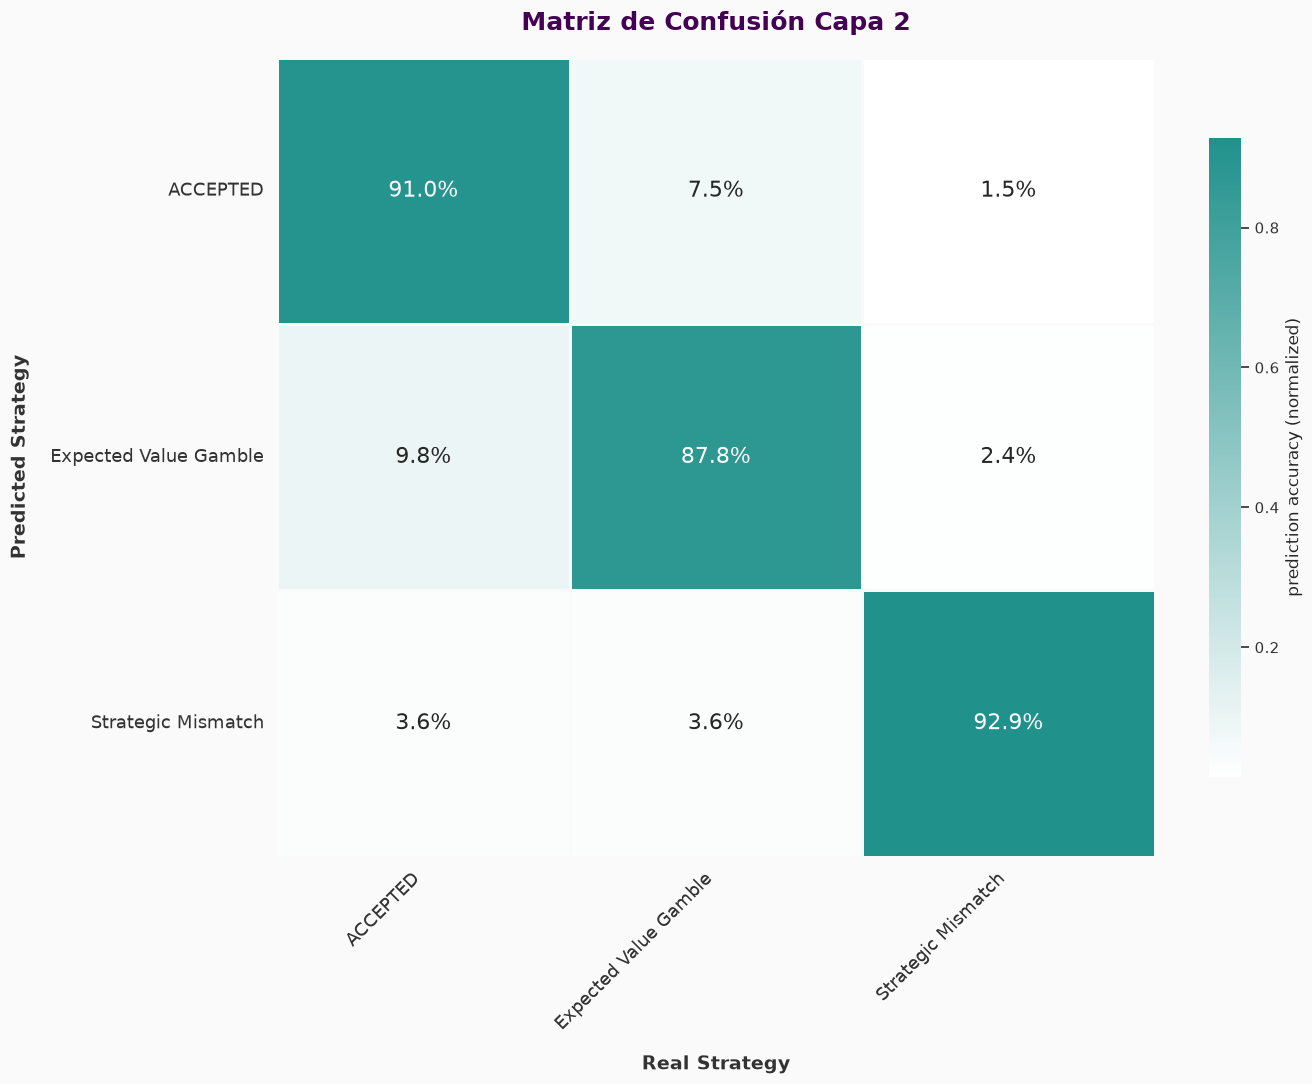

In [38]:
# ==============================================================================
# CAPA 2 - CELL 5: LAYER 2 FINAL EVALUATION
# ==============================================================================
# Purpose: Final evaluation of Layer 2 using the Week 6 Holdout.
# Style:   Pienza Aesthetic (Teal/Purple Minimalist)
# ==============================================================================
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. SETUP ESTÉTICO
PIENZA_BG = "#FAFAFA"
PIENZA_TEAL = "#21918c"
PIENZA_PURPLE = "#440154"
PIENZA_TEXT = "#333333"
cmap_pienza = mcolors.LinearSegmentedColormap.from_list("pienza_teal", ["#FFFFFF", PIENZA_TEAL])

print("⏳ Executing Layer 2 final evaluation...")

# --- 2. PREDICCIÓN (Asegúrate de tener y_test_l2 y X_test_l2 cargados) ---
y_pred_l2 = model_champion_L2.predict(X_test_l2)
class_names_l2 = list(le_L2.classes_)

# --- 3. REPORTE TÉCNICO ---
print("\n" + "="*80)
print("📋 LAYER 2: CLASSIFICATION REPORT")
print("="*80)
print(classification_report(y_test_l2, y_pred_l2, target_names=class_names_l2, zero_division=0))

# --- 4. VISUALIZACIÓN DE LA MATRIZ ---
cm = confusion_matrix(y_test_l2, y_pred_l2, normalize='true')

fig, ax = plt.subplots(figsize=(14, 11), facecolor=PIENZA_BG)
ax.set_facecolor(PIENZA_BG)

sns.heatmap(
    cm,
    annot=True,
    fmt=".1%",
    cmap=cmap_pienza,
    xticklabels=class_names_l2,
    yticklabels=class_names_l2,
    cbar_kws={'shrink': 0.8, 'label': 'prediction accuracy (normalized)'},
    linewidths=2,
    linecolor=PIENZA_BG,
    ax=ax,
    annot_kws={"size": 16}
)

# Tipografía y Etiquetas
ax.set_title("Matriz de Confusión Capa 2",
             fontsize=18, fontweight='bold', color=PIENZA_PURPLE, pad=20)
ax.set_xlabel("Real Strategy", fontsize=14, fontweight='bold', color=PIENZA_TEXT, labelpad=15)
ax.set_ylabel("Predicted Strategy", fontsize=14, fontweight='bold', color=PIENZA_TEXT, labelpad=15)

plt.xticks(rotation=45, ha='right', fontsize=13)
plt.yticks(rotation=0, fontsize=13)

plt.tight_layout()
plt.show()

⏳ Calculating ROC-AUC Curves for Layer 2...


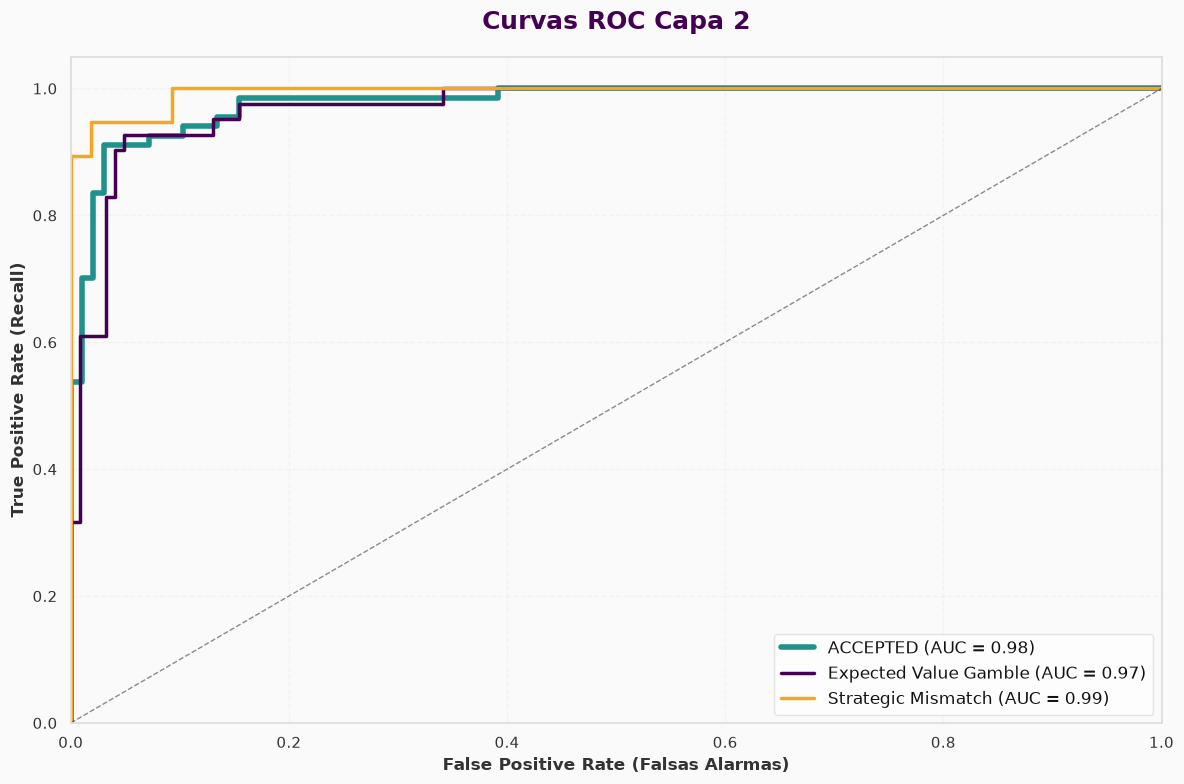


🏆 REPORTE DE DISCRIMINACIÓN (ROC-AUC)
🥇 ROC-AUC MACRO TOTAL: 0.9811


In [39]:
# ==============================================================================
# CAPA 2 - CELL 5.6: LAYER 2 DISCRIMINATION (ROC-AUC OVR)
# ==============================================================================
# Purpose: Evaluate the model's ability to separate nuanced strategies.
# Style:   Pienza Canonical (Teal/Purple/Minimalist)
# ==============================================================================
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

print("⏳ Calculating ROC-AUC Curves for Layer 2...")

# --- 1. SETUP DE DATOS ---
# Usamos el modelo de Capa 2 y sus datos de prueba
model = model_champion_L2
X_true = X_test_l2
y_true = y_test_l2

# Recuperamos las clases y nombres (Ya vienen del LabelEncoder L2)
classes = model.classes_
class_names = list(le_L2.classes_)
n_classes = len(classes)

# --- 2. BINARIZAR Y OBTENER PROBABILIDADES ---
y_bin = label_binarize(y_true, classes=classes)
y_score = model.predict_proba(X_true)

# --- 3. GRAFICAR LAS CURVAS ROC ---
# Usamos la paleta de Pienza para las 3 clases
colors = ['#21918c', '#440154', '#f5a623'] # Teal, Purple, Orange

plt.figure(figsize=(12, 8))
plt.gcf().patch.set_facecolor('#FAFAFA')
plt.gca().set_facecolor('#FAFAFA')

for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    # Destacamos la clase ACCEPTED con una línea más gruesa
    linewidth = 4 if "ACCEPTED" in class_names[i].upper() else 2.5

    plt.plot(fpr, tpr, color=color, lw=linewidth,
             label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

# Línea base de azar
plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)

# Estética y Decoración
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Falsas Alarmas)', fontsize=12, fontweight='bold', color="#333333")
plt.ylabel('True Positive Rate (Recall)', fontsize=12, fontweight='bold', color="#333333")
plt.title('Curvas ROC Capa 2', fontsize=18, fontweight='bold', color="#440154", pad=20)

plt.legend(loc="lower right", fontsize=12, frameon=True, facecolor='white', edgecolor='#DDDDDD')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# --- 4. REPORTE DE AUC PROMEDIO ---
print("\n" + "="*60)
print("🏆 REPORTE DE DISCRIMINACIÓN (ROC-AUC)")
print("="*60)
try:
    # Usamos macro-average para tratar a todas las clases por igual
    auc_macro = roc_auc_score(y_true, y_score, multi_class='ovr', average='macro')
    print(f"🥇 ROC-AUC MACRO TOTAL: {auc_macro:.4f}")
except Exception as e:
    print(f"⚠️ ROC-AUC Macro no pudo calcularse: {e}")
print("="*60)

⏳ Calculating Precision-Recall Curves (PR-AUC) for Layer 2...


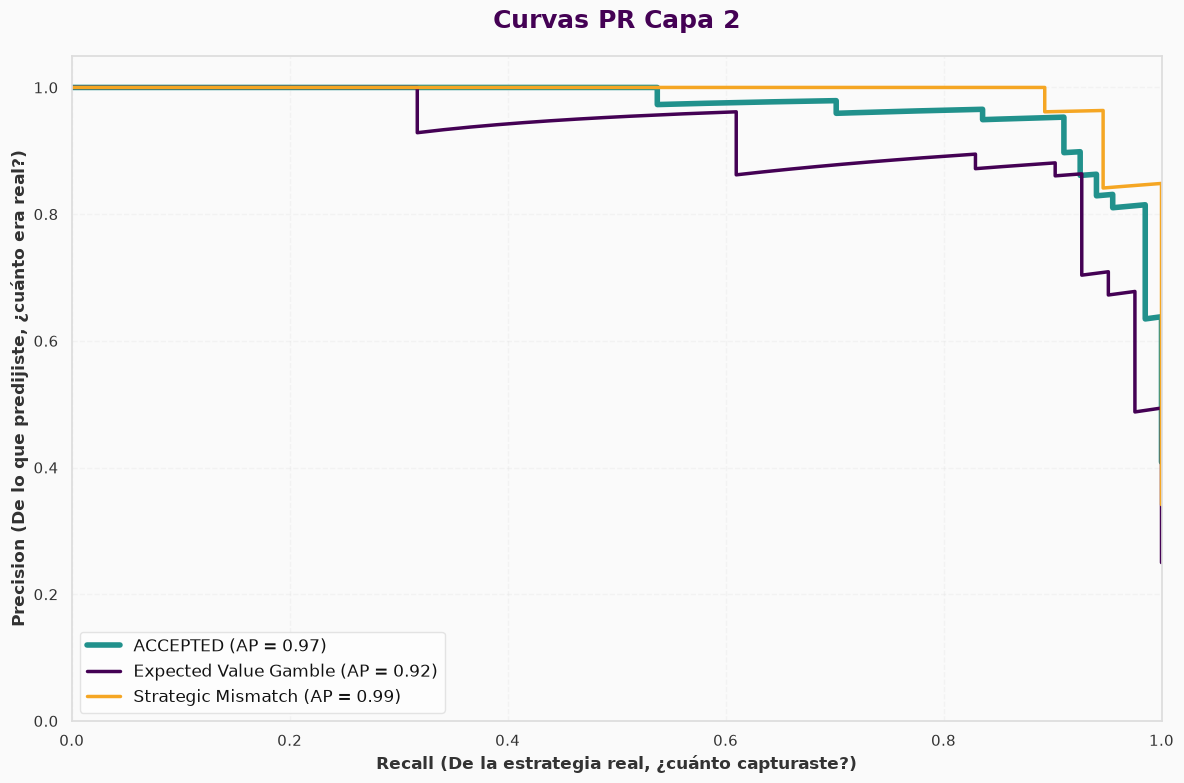


🏆 REPORTE DE PRECISIÓN (PR-AUC CAPA 2)
🥇 AVERAGE PRECISION MACRO (Total): 0.9600

📊 BASELINES (El Azar) vs RENDIMIENTO (AP):
 * ACCEPTED                      
    -> Baseline (Azar):  40.9%
    -> Model AP:         97.1%  (Uplift: +56.2 pts)
--------------------------------------------------
 - Expected Value Gamble         
    -> Baseline (Azar):  25.0%
    -> Model AP:         92.0%  (Uplift: +67.0 pts)
--------------------------------------------------
 - Strategic Mismatch            
    -> Baseline (Azar):  34.1%
    -> Model AP:         99.0%  (Uplift: +64.8 pts)
--------------------------------------------------


In [40]:
# ==============================================================================
# CAPA 2 - CELL 5.7: LAYER 2 PRECISION (PR-AUC OVR)
# ==============================================================================
# Purpose: Evaluate Precision-Recall Area Under Curve for the Nuance Engine.
# Style:   Pienza Canonical (Teal/Purple/Minimalist)
# ==============================================================================
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

print("⏳ Calculating Precision-Recall Curves (PR-AUC) for Layer 2...")

# --- 1. SETUP DE DATOS ---
model = model_champion_L2
X_true = X_test_l2
y_true = y_test_l2

# Recuperamos las clases y nombres
classes = model.classes_
class_names = list(le_L2.classes_)
n_classes = len(classes)

# --- 2. BINARIZAR Y OBTENER PROBABILIDADES ---
y_bin = label_binarize(y_true, classes=classes)
y_score = model.predict_proba(X_true)

# --- 3. GRAFICAR LAS CURVAS PR ---
# Usamos la paleta de Pienza para las 3 clases
colors = ['#21918c', '#440154', '#f5a623'] # Teal, Purple, Orange

plt.figure(figsize=(12, 8))
plt.gcf().patch.set_facecolor('#FAFAFA')
plt.gca().set_facecolor('#FAFAFA')

ap_scores = [] # Almacenamos el AP de cada clase

for i, color in zip(range(n_classes), colors):
    # Cálculo de Precision y Recall
    precision, recall, _ = precision_recall_curve(y_bin[:, i], y_score[:, i])
    avg_precision = average_precision_score(y_bin[:, i], y_score[:, i])
    ap_scores.append(avg_precision)

    # Destacamos la clase ACCEPTED
    linewidth = 4 if "ACCEPTED" in class_names[i].upper() else 2.5

    plt.plot(recall, precision, color=color, lw=linewidth,
             label=f'{class_names[i]} (AP = {avg_precision:.2f})')

# Estética y Decoración (Limpieza Pienza)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall (De la estrategia real, ¿cuánto capturaste?)', fontsize=12, fontweight='bold', color="#333333")
plt.ylabel('Precision (De lo que predijiste, ¿cuánto era real?)', fontsize=12, fontweight='bold', color="#333333")
plt.title('Curvas PR Capa 2', fontsize=18, fontweight='bold', color="#440154", pad=20)

plt.legend(loc="lower left", fontsize=12, frameon=True, facecolor='white', edgecolor='#DDDDDD')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# --- 4. REPORTE DE AP PROMEDIO Y BASELINES ---
print("\n" + "="*70)
print("🏆 REPORTE DE PRECISIÓN (PR-AUC CAPA 2)")
print("="*70)
try:
    ap_macro = np.mean(ap_scores)
    print(f"🥇 AVERAGE PRECISION MACRO (Total): {ap_macro:.4f}\n")

    print("📊 BASELINES (El Azar) vs RENDIMIENTO (AP):")
    for i, class_name in enumerate(class_names):
        # El baseline en PR es la proporción real de esa clase en la Capa 2
        baseline = np.sum(y_bin[:, i]) / len(y_true)
        ap = ap_scores[i]
        uplift = ap - baseline

        # Marcador visual para la clase principal
        marker = "*" if "ACCEPTED" in class_name.upper() else "-"

        print(f" {marker} {class_name:<30}")
        print(f"    -> Baseline (Azar): {baseline:>6.1%}")
        print(f"    -> Model AP:        {ap:>6.1%}  (Uplift: +{uplift*100:.1f} pts)")
        print("-" * 50)

except Exception as e:
    print(f"⚠️ PR-AUC Reporte falló: {e}")

⏳ Generando Curva de Aprendizaje RAW para la Capa 2...


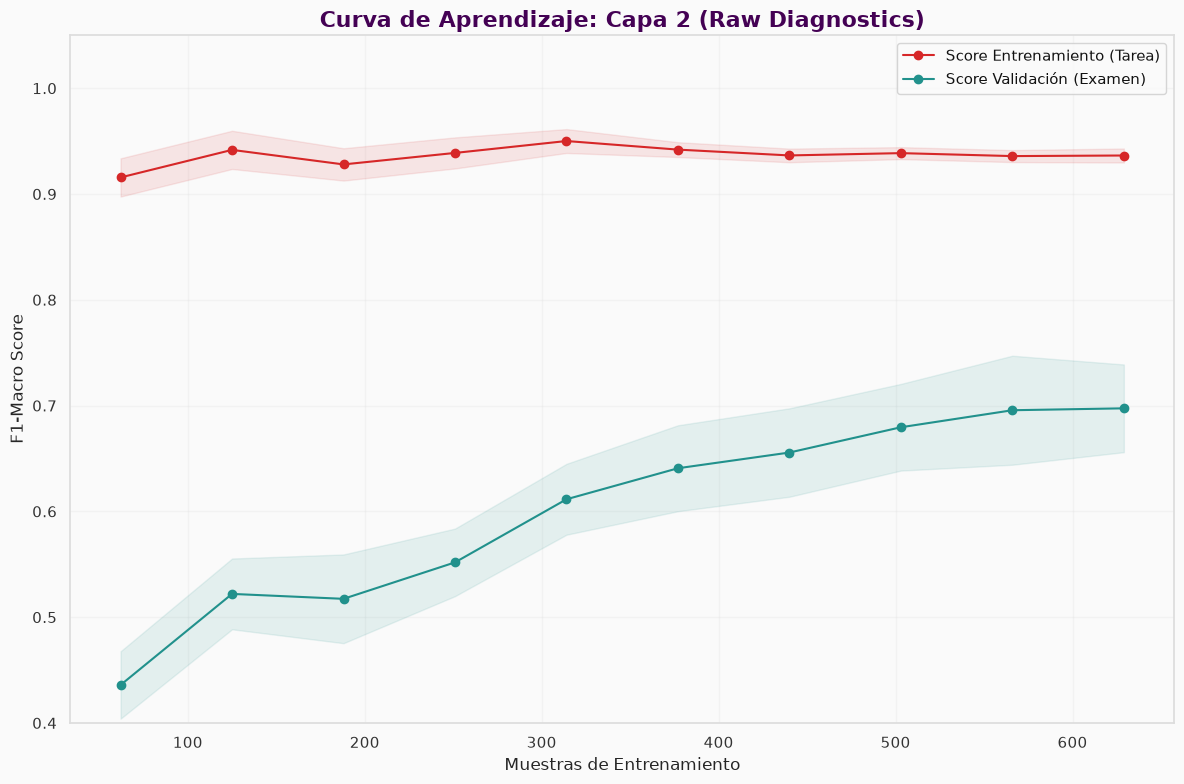


📊 DIAGNÓSTICO FINAL:
   -> Score Memoria Final (Train):    0.9364
   -> Score Validación Final (Test):  0.6974
   -> Brecha (Overfitting):           0.2390


In [41]:
# ==============================================================================
# CAPA 2 - CELL 8 (RAW): LEARNING CURVE DIAGNOSTIC
# ==============================================================================
from sklearn.model_selection import learning_curve, StratifiedKFold
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re

print("⏳ Generando Curva de Aprendizaje RAW para la Capa 2...")

# 1. SETUP DE DATOS
X_curve_l2 = X_train_l2.copy()
y_curve_l2 = y_train_l2

# Limpieza Regex para XGBoost
regex = re.compile(r"\[|\]|<", re.IGNORECASE)
X_curve_l2.columns = [regex.sub("_", col) if any(x in str(col) for x in set(('[', ']', '<'))) else col for col in X_curve_l2.columns]

# 2. CONFIGURACIÓN (10 puntos de muestreo originales)
cv_lc = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_sizes_cfg = np.linspace(0.1, 1.0, 10)

# 3. EJECUCIÓN (HEAVY LIFTING)
train_sizes, train_scores, test_scores = learning_curve(
    model_champion_L2,
    X_curve_l2,
    y_curve_l2,
    cv=cv_lc,
    scoring='f1_macro',
    n_jobs=-1,
    train_sizes=train_sizes_cfg,
    random_state=42
)

# 4. CÁLCULO DE ESTADÍSTICAS
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# 5. VISUALIZACIÓN (DEFAULT)
plt.figure(figsize=(12, 8))

# Sombras de varianza
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="#d62728")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="#21918c")

# Líneas con marcadores 'o-' (Taquicardia real)
plt.plot(train_sizes, train_mean, 'o-', color="#d62728", label="Score Entrenamiento (Tarea)")
plt.plot(train_sizes, test_mean, 'o-', color="#21918c", label="Score Validación (Examen)")

plt.title("Curva de Aprendizaje: Capa 2 (Raw Diagnostics)", fontsize=16, fontweight='bold', color="#440154")
plt.xlabel("Muestras de Entrenamiento")
plt.ylabel("F1-Macro Score")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.ylim(0.4, 1.05)
plt.tight_layout()
plt.show()

# 6. DIAGNÓSTICO
gap = train_mean[-1] - test_mean[-1]
print("\n" + "="*50)
print(f"📊 DIAGNÓSTICO FINAL:")
print("="*50)
print(f"   -> Score Memoria Final (Train):    {train_mean[-1]:.4f}")
print(f"   -> Score Validación Final (Test):  {test_mean[-1]:.4f}")
print(f"   -> Brecha (Overfitting):           {gap:.4f}")
print("="*50)

🛡️ Forjando la variante ligera de Capa 2 (Top 6 Variables)...
⏳ Evaluando la curva de aprendizaje (Raw)...


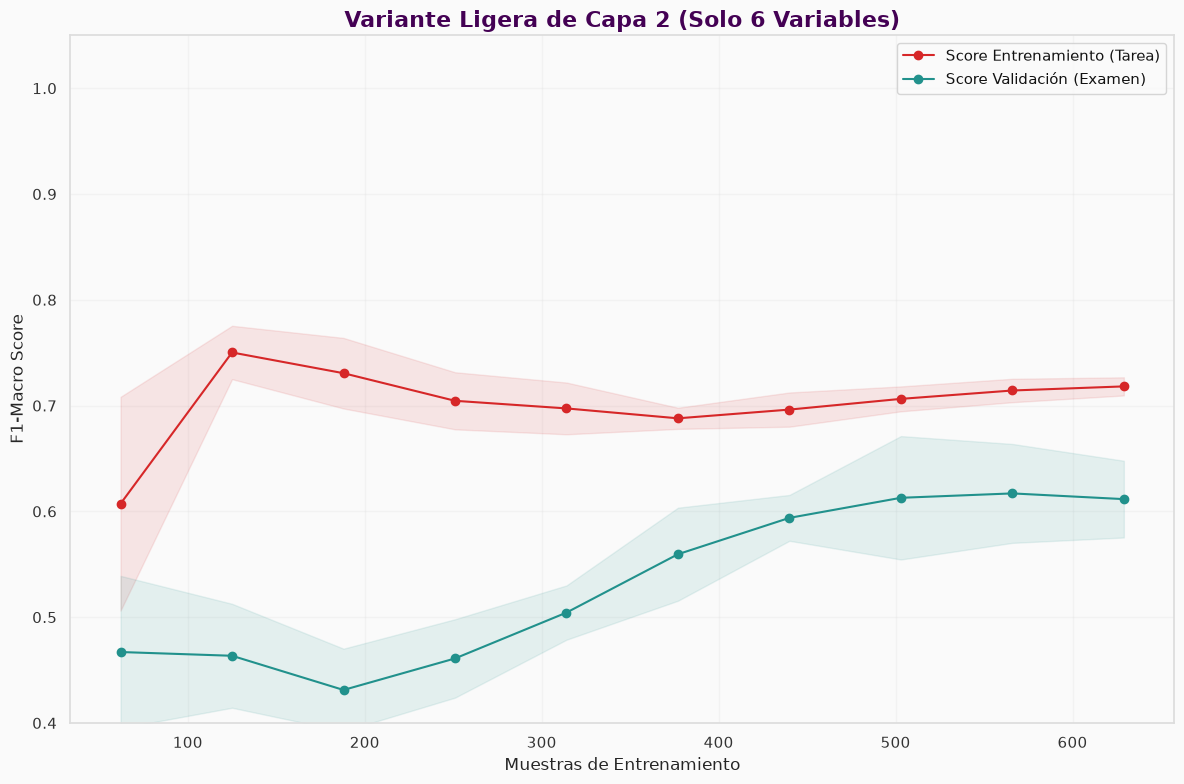

📊 DIAGNÓSTICO DEL MODELO LIGERO:
   -> Score Memoria Final (Train): 0.7182
   -> Score Inteligencia Final (Val): 0.6116
   -> Nueva Brecha: 0.1066


In [42]:
# ==============================================================================
# EXPERIMENT: LIGHTWEIGHT LAYER 2 VARIANT (ULTRA-LIGERO - 6 FEATURES)
# ==============================================================================
from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("🛡️ Forjando la variante ligera de Capa 2 (Top 6 Variables)...")

# --- 1. SELECCIÓN DE VARIABLES (Pura esencia económica y temporal) ---
spartan_features = [
    'session_progress_ratio',          # El reloj de fatiga
    'total_accumulated_deadhead_sec',  # La desesperación
    'cycle_rolling_avg_spread',        # La expectativa del mercado
    'eph_operational_index',           # La rentabilidad pura (Sustituye a upfront_fare)
    'cycle_cumulative_net_earnings',   # La meta del día
    'home_vector_alignment_score'      # El imán a casa
]

# --- 2. PREPARACIÓN ULTRA-RÁPIDA ---
def build_lightweight_raw_features(df):
    """Numeric feature engineering for the lightweight Layer 2 variant, pre-scaling."""
    X_num = df[spartan_features].copy()
    for col in ['total_accumulated_deadhead_sec', 'cycle_cumulative_net_earnings']:
        if col in X_num.columns:
            X_num[f'log_{col}'] = np.log1p(X_num[col].clip(lower=0))
            X_num = X_num.drop(columns=[col])
    return X_num

# Extraemos de la Capa 2 original (df_L2)
X_spartan_num = build_lightweight_raw_features(df_L2)

# Escalado y Sincronización Temporal
scaler_spartan = StandardScaler()
X_spartan_scaled = pd.DataFrame(
    scaler_spartan.fit_transform(X_spartan_num),
    columns=X_spartan_num.columns,
    index=df_L2.index
)

# Cortamos para Entrenamiento (Semanas 1-5)
train_mask_l2 = (df_L2['week_id'] < 6)
X_train_spartan = X_spartan_scaled[train_mask_l2]

# --- 3. EL MOTOR REGULARIZADO ---
xgb_spartan = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=3,
    min_child_weight=7,
    learning_rate=0.05,
    gamma=2,
    objective='multi:softprob',
    n_jobs=-1,
    random_state=42
)

# --- 4. CURVA DE APRENDIZAJE CRUDA (LA VERDAD) ---
print("⏳ Evaluando la curva de aprendizaje (Raw)...")
cv_spartan = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_sizes_cfg = np.linspace(0.1, 1.0, 10)

train_sizes, train_scores, test_scores = learning_curve(
    xgb_spartan, X_train_spartan, y_train_l2, cv=cv_spartan,
    scoring='f1_macro', n_jobs=-1, train_sizes=train_sizes_cfg, random_state=42
)

# Estadísticas
t_mean, t_std = np.mean(train_scores, axis=1), np.std(train_scores, axis=1)
v_mean, v_std = np.mean(test_scores, axis=1), np.std(test_scores, axis=1)

# Gráfica
plt.figure(figsize=(12, 8))
plt.fill_between(train_sizes, t_mean - t_std, t_mean + t_std, alpha=0.1, color="#d62728")
plt.fill_between(train_sizes, v_mean - v_std, v_mean + v_std, alpha=0.1, color="#21918c")
plt.plot(train_sizes, t_mean, 'o-', color="#d62728", label="Score Entrenamiento (Tarea)")
plt.plot(train_sizes, v_mean, 'o-', color="#21918c", label="Score Validación (Examen)")

plt.title("Variante Ligera de Capa 2 (Solo 6 Variables)", fontsize=16, fontweight='bold', color="#440154")
plt.xlabel("Muestras de Entrenamiento")
plt.ylabel("F1-Macro Score")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.ylim(0.4, 1.05)
plt.tight_layout()
plt.show()

# Diagnóstico
print(f"📊 DIAGNÓSTICO DEL MODELO LIGERO:")
print(f"   -> Score Memoria Final (Train): {t_mean[-1]:.4f}")
print(f"   -> Score Inteligencia Final (Val): {v_mean[-1]:.4f}")
print(f"   -> Nueva Brecha: {t_mean[-1] - v_mean[-1]:.4f}")

⏳ Forging the Full Strategic DNA Atlas (Layer 2 - All Variables)...


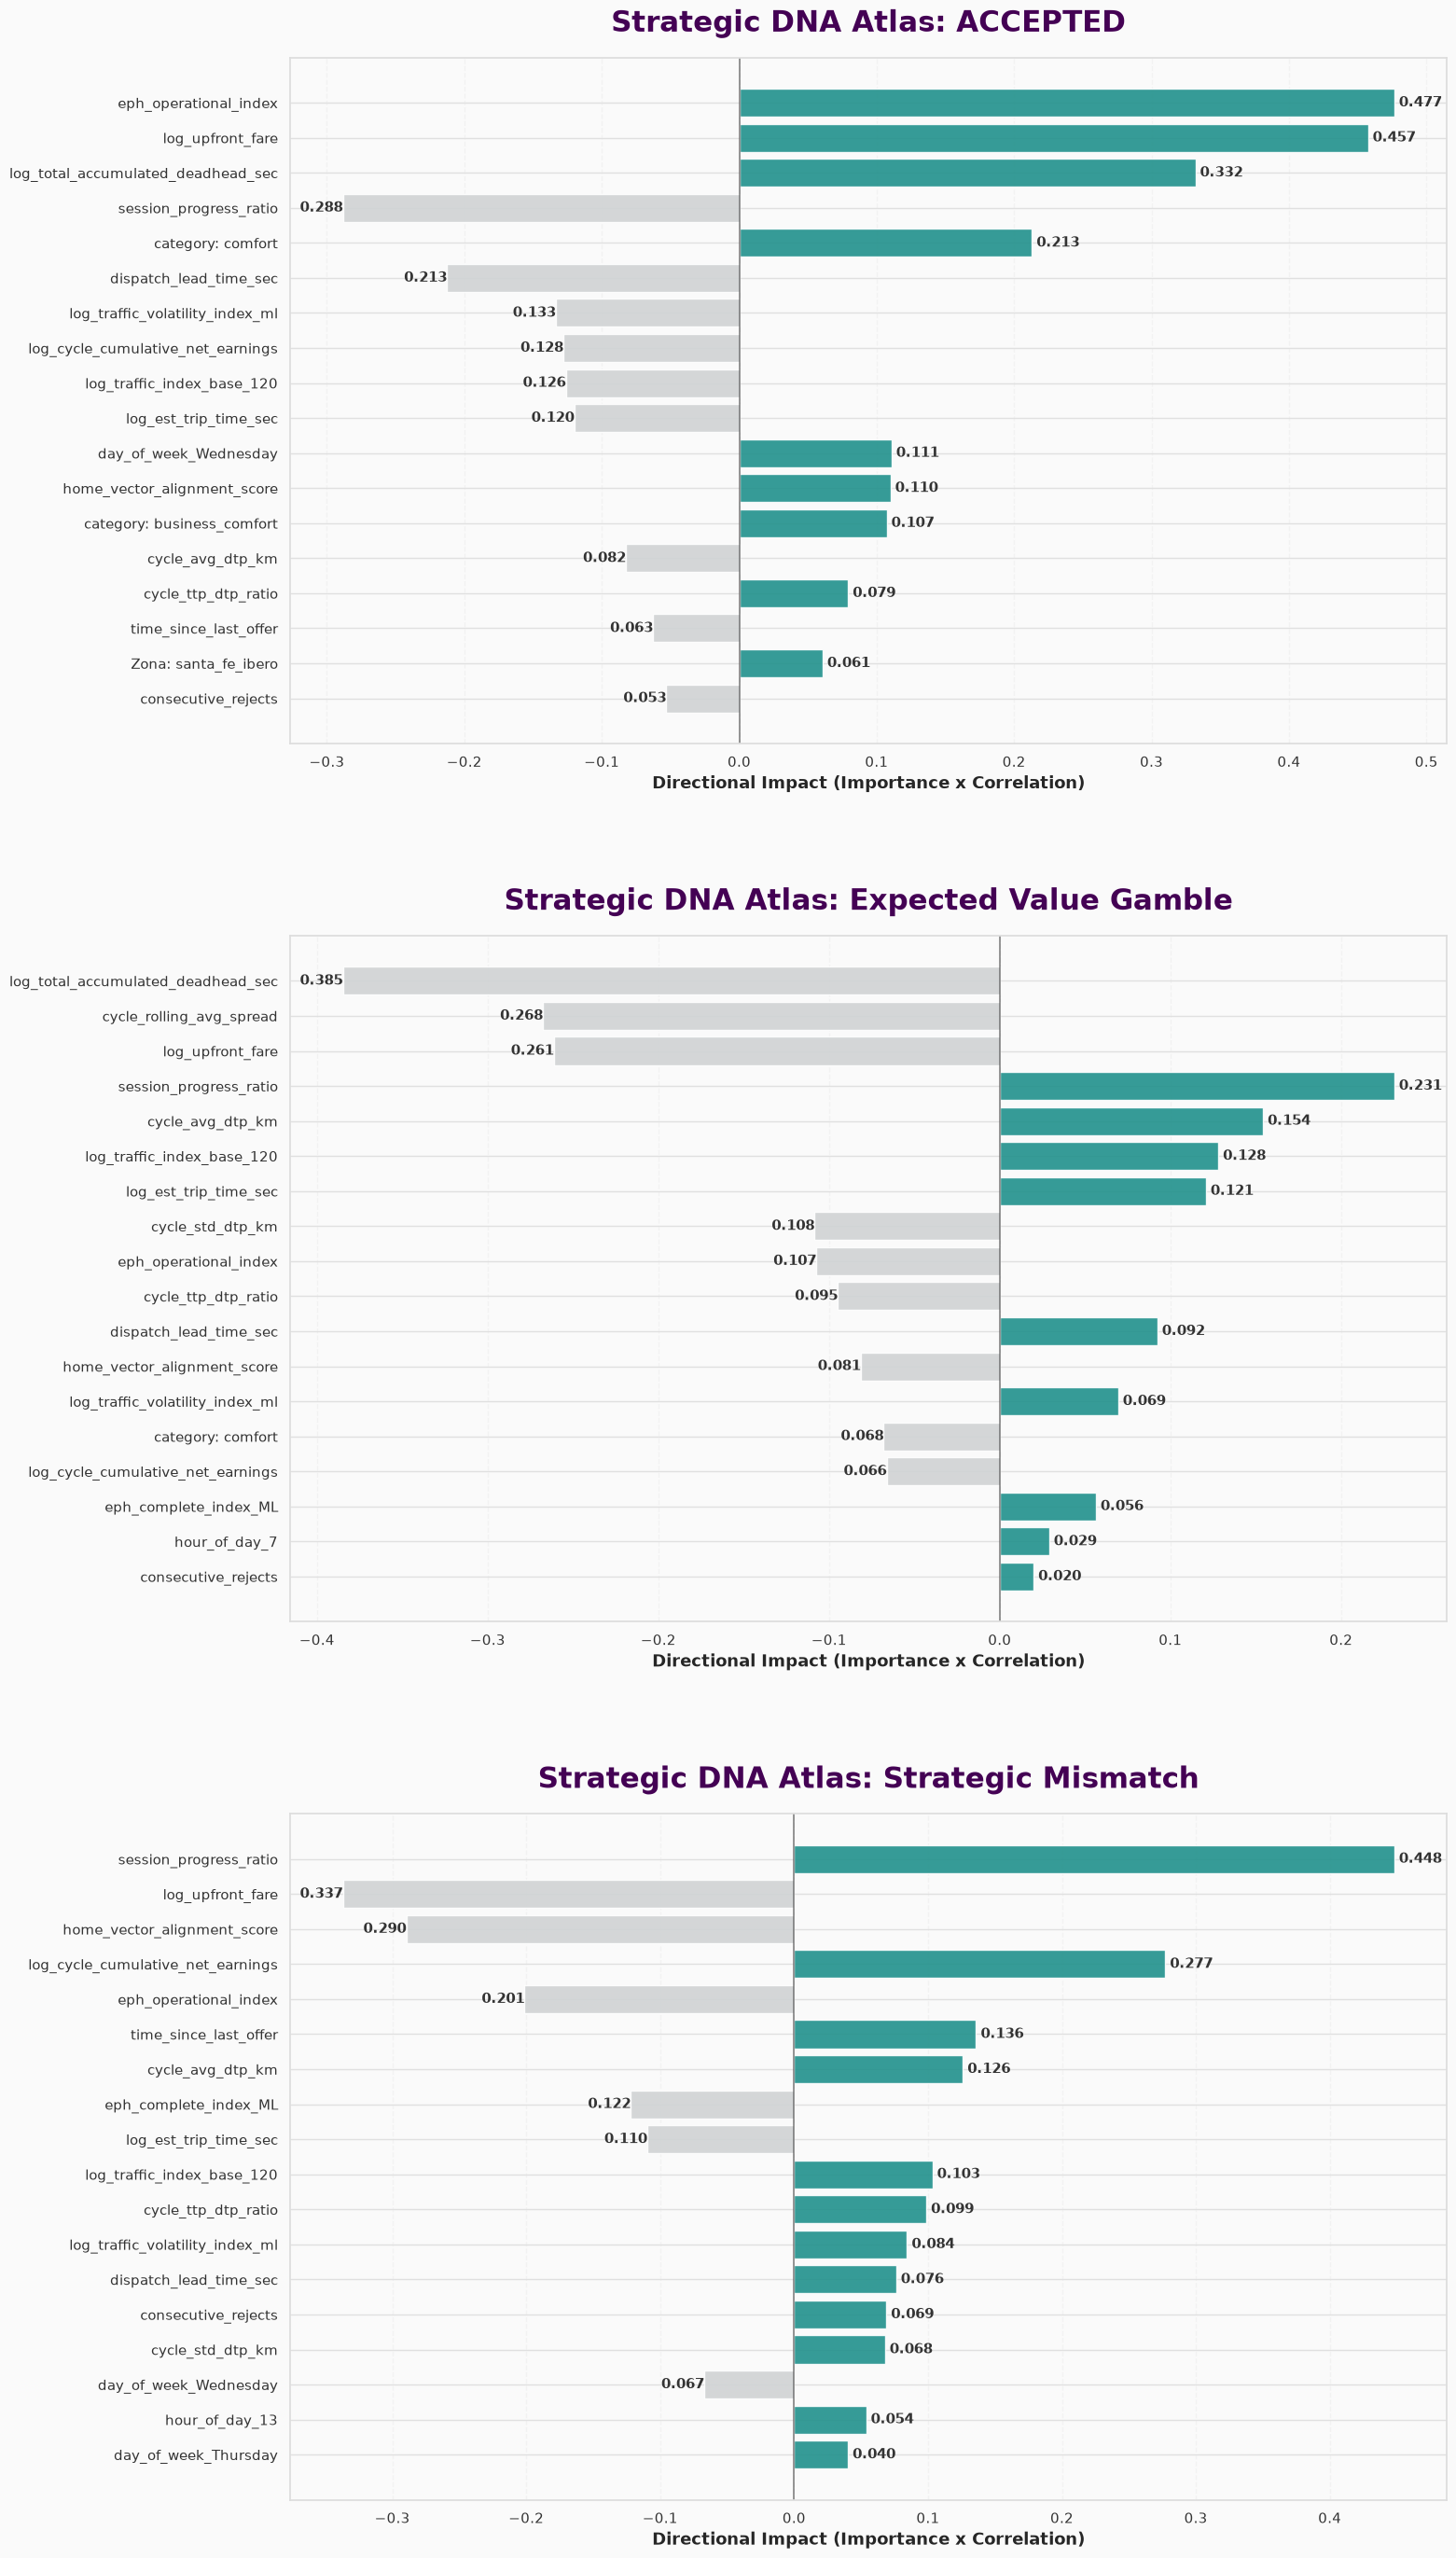


### 🧬 Guía Forense del ADN Estratégico:
1. **Motores Teal (Derecha):** Variables que **incentivan** esa decisión (ej. alta ganancia para `ACCEPTED`).
2. **Frenos Grises (Izquierda):** Variables que **inhiben** esa decisión (ej. fatiga alta para `MISMATCH`).
3. **Jerarquía:** El gráfico incluye ahora variables económicas, temporales, conductuales y geográficas en un solo vistazo.


In [43]:
# ==============================================================================
# CAPA 2 - CELL 5.2: THE STRATEGIC DNA ATLAS (FULL CONTEXT - ALL VARIABLES)
# ==============================================================================
# Purpose: Generate the complete behavioral fingerprint for Layer 2 decisions.
# Style:   Pienza Hero (Teal/Gray, Triple Vertical Stack, Full Semantic Mapping)
# ==============================================================================
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

print("⏳ Forging the Full Strategic DNA Atlas (Layer 2 - All Variables)...")

# --- 0. DICCIONARIOS SEMÁNTICOS (Zonas, Productos, Contextos) ---
p_map = globals().get('product_map', {})
z_metadata = df_input.drop_duplicates('final_zone_id').set_index('final_zone_id')['final_zone_name'].to_dict()

def map_full_semantic(feature_name):
    """Mapeo universal de nombres técnicos a etiquetas humanas."""
    s_feat = str(feature_name)
    # 1. Zonas del Master Coalesce
    if 'final_zone_id_' in s_feat:
        raw_id = s_feat.split('final_zone_id_')[-1]
        return f"Zona: {z_metadata.get(raw_id, raw_id)}"
    # 2. Contextos Heurísticos (Banderas)
    if 'heuristic_flag_context_' in s_feat:
        return f"Contexto: {s_feat.split('heuristic_flag_context_')[-1]}"
    # 3. Productos (UberX, Flash, etc.)
    if 'product_category_fk_' in s_feat:
        raw_id = s_feat.split('product_category_fk_')[-1]
        try:
            p_id = int(float(raw_id))
            if p_id in p_map: return f"category: {p_map[p_id]}"
        except: pass
        return f"category: {raw_id}"
    return feature_name

# --- 1. CONFIGURACIÓN DEL ATLAS (LAYOUT VERTICAL) ---
classes_l2 = list(le_L2.classes_)
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(16, 34), facecolor="#FAFAFA")
plt.subplots_adjust(hspace=0.28) # Espacio generoso para que respiren las etiquetas

# Asegurar cálculo de SHAP para Capa 2
if 'shap_values_L2' not in locals():
    import builtins, re as _re
    _orig_float = builtins.float
    def _vec_safe_float(x):
        if isinstance(x, str) and x.startswith('['):
            x = _re.search(r'[+-]?[\d.]+(?:E[+-]?\d+)?', x).group()
        return _orig_float(x)
    builtins.float = _vec_safe_float
    try:
        explainer_L2 = shap.TreeExplainer(model_champion_L2)
        shap_values_L2 = explainer_L2.shap_values(X_test_l2, check_additivity=False)
    finally:
        builtins.float = _orig_float

# --- 2. BUCLE DE GENERACIÓN DE ADN ---
for i, class_name in enumerate(classes_l2):
    ax = axes[i]

    # Extraer SHAP para la clase actual
    if isinstance(shap_values_L2, list):
        class_shap = shap_values_L2[i]
    else:
        class_shap = shap_values_L2[:, :, i]

    f_importance = np.mean(np.abs(class_shap), axis=0)

    # Correlación robusta (Fixing NaNs and 0-StdDev warnings)
    corrs = []
    for col_idx in range(X_test_l2.shape[1]):
        f_val = X_test_l2.iloc[:, col_idx]
        s_val = class_shap[:, col_idx]
        if np.std(f_val) == 0 or np.std(s_val) == 0:
            corrs.append(0)
        else:
            c = np.corrcoef(f_val, s_val)[0, 1]
            corrs.append(c if not np.isnan(c) else 0)

    # DataFrame para visualización
    df_temp = pd.DataFrame({
        'Feature': X_test_l2.columns,
        'Importance': f_importance,
        'Impact': f_importance * np.sign(corrs),
        'Abs_Impact': np.abs(f_importance * np.sign(corrs))
    })

    # Aplicar etiquetas semánticas
    df_temp['Semantic'] = df_temp['Feature'].apply(map_full_semantic)

    # Seleccionar Top 18 Drivers más potentes (Absolutos)
    df_viz = df_temp.sort_values(by='Abs_Impact', ascending=False).head(18)
    df_viz = df_viz.iloc[::-1] # Reversar para plot horizontal de arriba hacia abajo

    # Visualización Pienza Hero
    colors = ["#21918c" if x > 0 else "#D0D3D4" for x in df_viz['Impact']]
    bars = ax.barh(df_viz['Semantic'], df_viz['Impact'], color=colors, alpha=0.9, edgecolor='white')
    ax.axvline(0, color="#333333", linewidth=1.2, alpha=0.6)

    # Estética de Panel
    ax.set_title(f"Strategic DNA Atlas: {class_name}", fontsize=22, fontweight='bold', color="#440154", pad=20)
    ax.set_xlabel("Directional Impact (Importance x Correlation)", fontsize=13, fontweight='bold')
    ax.grid(axis='x', linestyle='--', alpha=0.3)

    # Anotaciones numéricas (El rigor Pienza)
    for bar in bars:
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height()/2, f' {abs(width):.3f}',
                va='center', ha='left' if width > 0 else 'right',
                fontsize=11, fontweight='bold', color="#333333")


plt.show()

# --- 3. AUDITORÍA RÁPIDA ---
display(Markdown(f"""
### 🧬 Guía Forense del ADN Estratégico:
1. **Motores Teal (Derecha):** Variables que **incentivan** esa decisión (ej. alta ganancia para `ACCEPTED`).
2. **Frenos Grises (Izquierda):** Variables que **inhiben** esa decisión (ej. fatiga alta para `MISMATCH`).
3. **Jerarquía:** El gráfico incluye ahora variables económicas, temporales, conductuales y geográficas en un solo vistazo.
"""))

In [44]:
# --- FIX: GENERAR PROBABILIDADES DE LA CAPA 2 ---
# Usamos el modelo campeón y el set de prueba que acabamos de sincronizar
y_pred_probs_l2 = model_champion_L2.predict_proba(X_test_l2)

# Aseguramos que class_names_l2 esté fresco
class_names_l2 = list(le_L2.classes_)

### Snippet into Simulations

In [45]:
# ==============================================================================
# AUDITORÍA CORREGIDA: USANDO LOS DATOS DEL "EXAMEN" REAL
# ==============================================================================
# Usamos y_L1_test y y_pred_L1 que son los que generaron el Heatmap
human_real_test = le_L1.inverse_transform(y_L1_test)
ia_pred_test = le_L1.inverse_transform(y_pred_L1)

df_soT = pd.DataFrame({
    'Real_Humano': human_real_test,
    'Pred_IA': ia_pred_test
})

print("📊 LA VERDAD ABSOLUTA (Sincronizada con el Heatmap):")
crosstab_final = pd.crosstab(df_soT['Real_Humano'], df_soT['Pred_IA'], margins=True)
display(crosstab_final.style.background_gradient(cmap='Greens'))

📊 LA VERDAD ABSOLUTA (Sincronizada con el Heatmap):


Pred_IA,Dropoff: Non-Operational,Dropoff: Proxy Zone,Long Pickup Time,Low Profitability,THE_NUANCED_REST,All
Real_Humano,,,,,,
Dropoff: Non-Operational,318,3,25,27,18,391
Dropoff: Proxy Zone,1,35,1,2,2,41
Long Pickup Time,1,0,54,0,1,56
Low Profitability,3,0,4,95,26,128
THE_NUANCED_REST,10,5,23,13,113,164
All,333,43,107,137,160,780


In [46]:
# ==============================================================================
# RE-FIT SOSPECHOSOS (Asegurando motores encendidos)
# ==============================================================================
print("🔧 Fitting lightweight model and verifying scalers...")

# 1. Entrenar el modelo ligero (que solo existía en la curva de aprendizaje)
# Usamos el X_train_spartan que definiste en el experimento
xgb_spartan.fit(X_train_spartan, y_train_l2)

# 2. Verificar que el scaler de la Capa 2 esté en memoria
# (Si reiniciaste kernel, esto fallará y sabremos que es el scaler)
if not hasattr(scaler_L2, "mean_"):
    print("⚠️ Scaler_L2 no estaba fit... arreglando.")
    # Nota: Aquí deberías usar tus datos de entrenamiento originales de L2
    scaler_L2.fit(X_L2_raw[train_mask_l2])

print("✅ Motores listos. Ya puedes correr la inferencia.")

🔧 Fitting lightweight model and verifying scalers...
✅ Motores listos. Ya puedes correr la inferencia.


In [47]:
import pandas as pd
import numpy as np
import re

print("⏳ Rebuilding Feature Space for the Week 6 Master Table...")

# --- 1. ISOLATE WEEK 6 BASE DATA ---
w6_mask = (df_input['week_id'] == 6)
master_w6 = df_input[w6_mask].copy()

# --- 2. HUMAN LABEL RELABELING (GROUND TRUTH) ---
def get_human_l1(val):
    if val == 1: return "dropoff_non_operational"
    if val == 3: return "low_profitability"
    if val == 2: return "dropoff_proxy"
    if val == 4: return "long_pickup"
    if val in [5, 6, 9999]: return "the_nuanced_rest"
    return "other"

def get_human_l2(val):
    if val == 9999: return "accepted"
    if val == 6:    return "expected_value_gamble"
    if val == 5:    return "strategic_mismatch"
    return "filtered_by_l1"

master_w6['human_label_l1'] = master_w6['reason_primary_fk'].fillna(9999).apply(get_human_l1)
master_w6['human_label_l2'] = master_w6['reason_primary_fk'].fillna(9999).apply(get_human_l2)

# --- 3. REBUILD LAYER 2 FEATURE SPACE FOR ALL OF WEEK 6 ---
# Reuses praetorian_L2/categorical_L2 and build_l2_raw_features() from Layer 2's feature cell
X_w6_l2_full = build_l2_raw_features(master_w6)

# Alignment: Ensure columns match the Layer 2 Trainer exactly
expected_cols_l2 = model_champion_L2.get_booster().feature_names
for col in expected_cols_l2:
    if col not in X_w6_l2_full.columns:
        X_w6_l2_full[col] = 0
X_w6_l2_full = X_w6_l2_full[expected_cols_l2]

# Scaling
X_w6_l2_scaled = pd.DataFrame(
    scaler_L2.transform(X_w6_l2_full),
    columns=expected_cols_l2,
    index=master_w6.index
)

# --- 4. REBUILD LIGHTWEIGHT FEATURE SPACE FOR ALL OF WEEK 6 ---
# Reuses spartan_features/build_lightweight_raw_features() from the lightweight-variant cell
X_w6_spartan_num = build_lightweight_raw_features(master_w6)

X_w6_spartan_scaled = pd.DataFrame(
    scaler_spartan.transform(X_w6_spartan_num),
    columns=X_w6_spartan_num.columns,
    index=master_w6.index
)

# --- 5. EXECUTE INFERENCE ---
print("🤖 Running Inference...")
X_w6_l1_final = X_L1[w6_mask].copy()

master_w6['ml_l1_label'] = le_L1.inverse_transform(model_champion_L1.predict(X_w6_l1_final))
master_w6['ml_l2_label'] = le_L2.inverse_transform(model_champion_L2.predict(X_w6_l2_scaled))
master_w6['spartan_l2_label'] = le_L2.inverse_transform(xgb_spartan.predict(X_w6_spartan_scaled))

# --- 6. INTEGRATE SCALED FEATURES FOR THE PARQUET ---
scaled_features_praetorian = X_league_b[w6_mask].add_prefix('scaled_')
master_w6_final = pd.concat([master_w6, scaled_features_praetorian], axis=1)

print("\n✅ MASTER TABLE (WEEK 6) READY.")
print("-" * 80)
print(f"Total Rows: {len(master_w6_final)}")
print("\n[Layer 1 Comparison]")
display(pd.crosstab(master_w6_final['human_label_l1'], master_w6_final['ml_l1_label']))
print("\n[Layer 2 vs Lightweight Comparison (All W6)]")
display(pd.crosstab(master_w6_final['ml_l2_label'], master_w6_final['spartan_l2_label']))

# Verification snippet
display(master_w6_final[['offer_id', 'human_label_l1', 'ml_l1_label', 'human_label_l2', 'ml_l2_label', 'spartan_l2_label']].head(5))

⏳ Rebuilding Feature Space for the Week 6 Master Table...
🤖 Running Inference...

✅ MASTER TABLE (WEEK 6) READY.
--------------------------------------------------------------------------------
Total Rows: 780

[Layer 1 Comparison]


ml_l1_label,Dropoff: Non-Operational,Dropoff: Proxy Zone,Long Pickup Time,Low Profitability,THE_NUANCED_REST
human_label_l1,,,,,
dropoff_non_operational,318,3,25,27,18
dropoff_proxy,1,35,1,2,2
long_pickup,1,0,54,0,1
low_profitability,3,0,4,95,26
the_nuanced_rest,10,5,23,13,113



[Layer 2 vs Lightweight Comparison (All W6)]


spartan_l2_label,ACCEPTED,Expected Value Gamble,Strategic Mismatch
ml_l2_label,,,
ACCEPTED,148,28,14
Expected Value Gamble,68,139,76
Strategic Mismatch,38,68,201


,offer_id,human_label_l1,ml_l1_label,human_label_l2,ml_l2_label,spartan_l2_label
9,OF04090,dropoff_non_operational,Dropoff: Non-Operational,filtered_by_l1,Expected Value Gamble,Strategic Mismatch
16,OF04332,dropoff_non_operational,Dropoff: Non-Operational,filtered_by_l1,Expected Value Gamble,ACCEPTED
31,OF04201,dropoff_non_operational,Dropoff: Non-Operational,filtered_by_l1,ACCEPTED,ACCEPTED
48,OF04650,dropoff_non_operational,Dropoff: Non-Operational,filtered_by_l1,ACCEPTED,ACCEPTED
52,OF04497,dropoff_non_operational,Dropoff: Non-Operational,filtered_by_l1,ACCEPTED,ACCEPTED


In [48]:
import pandas as pd

print("⚔️ INITIATING WEEK 6 ECONOMIC TOURNAMENT...")

# --- 1. PREPARE RAW NUMERICS ---
# We need real currency and real seconds for the bank calculation
tourney_df = master_w6.copy()

# Ensure we have total effort per trip in seconds
tourney_df['total_trip_effort_sec'] = tourney_df['time_to_pickup_sec'] + tourney_df['est_trip_time_sec']

# --- 2. DEFINE THE COMPETITORS (The Decision Filters) ---

# Scenario A: HUMAN (The Ground Truth)
tourney_df['accept_human'] = (tourney_df['reason_primary_fk'].fillna(9999) == 9999)

# Scenario B: ML CHAMPION CASCADE
tourney_df['accept_ml_champion'] = (tourney_df['ml_l1_label'] == 'THE_NUANCED_REST') & \
                                   (tourney_df['ml_l2_label'] == 'ACCEPTED')

# Scenario C: ML SPARTAN CASCADE
tourney_df['accept_ml_spartan'] = (tourney_df['ml_l1_label'] == 'THE_NUANCED_REST') & \
                                  (tourney_df['spartan_l2_label'] == 'ACCEPTED')

# --- 3. THE CALCULATION ENGINE ---

def calculate_metrics(df, mask_col):
    subset = df[df[mask_col] == True]

    total_bank = subset['upfront_fare'].sum()
    total_effort_sec = subset['total_trip_effort_sec'].sum()
    total_hours = total_effort_sec / 3600

    # EPH Adjusted (Earnings per "Worked" Hour)
    eph = total_bank / total_hours if total_hours > 0 else 0

    return {
        'Accepted Offers': len(subset),
        'Total Bank ($)': round(total_bank, 2),
        'Total Hours Worked': round(total_hours, 2),
        'EPH (Adjusted)': round(eph, 2)
    }

# --- 4. EXECUTE TOURNAMENT ---

results = {
    "HUMAN (Observed)": calculate_metrics(tourney_df, 'accept_human'),
    "CASCADE (L1 + L2 Champion)": calculate_metrics(tourney_df, 'accept_ml_champion'),
    "CASCADE (L1 + L2 Lightweight)": calculate_metrics(tourney_df, 'accept_ml_spartan')
}

# --- 5. THE LEADERBOARD ---

df_tournament = pd.DataFrame(results).T

print("\n" + "="*80)
print("🏆 WEEK 6 TOURNAMENT LEADERBOARD")
print("="*80)
display(df_tournament.style.highlight_max(color='lightgreen', axis=0))

# --- 6. INSIGHT: THE "EFFICIENCY" RATIO ---
# Bank earned per offer accepted
df_tournament['Bank per Offer'] = round(df_tournament['Total Bank ($)'] / df_tournament['Accepted Offers'], 2)

print("\n" + "="*80)
print("WEEK 6 RESULTS ANALYSIS")
print("="*80)

# Compare efficiency
h_eph = results["HUMAN (Observed)"]["EPH (Adjusted)"]
c_eph = results["CASCADE (L1 + L2 Champion)"]["EPH (Adjusted)"]
uplift = ((c_eph - h_eph) / h_eph) * 100

print(f"🚀 Efficiency Uplift (Champion vs Human): {uplift:+.1f}% EPH")
if results["CASCADE (L1 + L2 Champion)"]["EPH (Adjusted)"] > results["CASCADE (L1 + L2 Lightweight)"]["EPH (Adjusted)"]:
    print("Result: The full 19-feature Layer 2 model provides a cleaner yield than the lightweight variant.")
else:
    print("Result: The lightweight variant holds the same or better yield with 70% less complexity.")

⚔️ INITIATING WEEK 6 ECONOMIC TOURNAMENT...

🏆 WEEK 6 TOURNAMENT LEADERBOARD


,Accepted Offers,Total Bank ($),Total Hours Worked,EPH (Adjusted)
HUMAN (Observed),67.000000,9750.550000,37.580000,259.440000
CASCADE (L1 + L2 Champion),64.000000,9569.970000,36.120000,264.970000
CASCADE (L1 + L2 Lightweight),85.000000,11987.590000,43.580000,275.050000



WEEK 6 RESULTS ANALYSIS
🚀 Efficiency Uplift (Champion vs Human): +2.1% EPH
Result: The lightweight variant holds the same or better yield with 70% less complexity.


In [49]:
print("AUDITING THE NUANCED PIPELINE (Week 6)...")

# 1. IDENTIFY THE POOLS
# Actual human status
human_nuanced_mask = (master_w6_final['human_label_l1'] == 'the_nuanced_rest')
# What L1 decided to send to L2
ml_nuanced_mask = (master_w6_final['ml_l1_label'] == 'THE_NUANCED_REST')

# 2. CALCULATE VOLUMES
human_nuanced_count = human_nuanced_mask.sum()
ml_nuanced_count = ml_nuanced_mask.sum()

# 3. CALCULATE THE "OVERLAP" (Intersection)
# These are the ones where both Human and ML agreed they were nuanced
captured_nuanced = (human_nuanced_mask & ml_nuanced_mask).sum()

# 4. CALCULATE THE "NOISE" (False Positives for L2)
# These are offers the Human labeled as Trash (Non-Op, etc.) but L1 let through to L2
noise_sent_to_l2 = (ml_nuanced_mask & ~human_nuanced_mask).sum()

# 5. CALCULATE THE "MISSED GEMS" (False Negatives for L2)
# These are nuanced offers (including potential accepts) that Layer 1 blocked
missed_nuanced = (human_nuanced_mask & ~ml_nuanced_mask).sum()

# --- REPORTE DE VOLUMETRÍA ---
print("\n" + "="*80)
print("📊 NUANCED FLOW AUDIT: HUMAN vs. MACHINE")
print("="*80)
print(f"{'Metric':<40} | {'Value':<10}")
print("-" * 55)
print(f"{'Actual Human Nuanced Pool (W6)':<40} | {human_nuanced_count:>10}")
print(f"{'ML Layer 1 Sent to Layer 2':<40} | {ml_nuanced_count:>10}")
print("-" * 55)
print(f"{'✅ Captured (Agreed Nuanced)':<40} | {captured_nuanced:>10} ({captured_nuanced/human_nuanced_count:.1%})")
print(f"{'⚠️ Noise (Trash sent to Layer 2)':<40} | {noise_sent_to_l2:>10} ({noise_sent_to_l2/ml_nuanced_count:.1%})")
print(f"{'🚫 Missed (Nuanced offers blocked by L1)':<40} | {missed_nuanced:>10} ({missed_nuanced/human_nuanced_count:.1%})")
print("="*80)

# --- DEEP DIVE INTO MISSED GEMS ---
if missed_nuanced > 0:
    print("\n🔍 WHAT DID WE MISS? (Breaking down the 🚫 Missed Pool)")
    missed_detail = master_w6_final[human_nuanced_mask & ~ml_nuanced_mask]['human_label_l2'].value_counts()
    display(missed_detail)

AUDITING THE NUANCED PIPELINE (Week 6)...

📊 NUANCED FLOW AUDIT: HUMAN vs. MACHINE
Metric                                   | Value     
-------------------------------------------------------
Actual Human Nuanced Pool (W6)           |        164
ML Layer 1 Sent to Layer 2               |        160
-------------------------------------------------------
✅ Captured (Agreed Nuanced)              |        113 (68.9%)
⚠️ Noise (Trash sent to Layer 2)         |         47 (29.4%)
🚫 Missed (Nuanced offers blocked by L1)  |         51 (31.1%)

🔍 WHAT DID WE MISS? (Breaking down the 🚫 Missed Pool)


human_label_l2
strategic_mismatch       33
accepted                 12
expected_value_gamble     6
Name: count, dtype: int64

In [50]:
# Define df_ledger from the Week 6 master table (patched further in the next cell)
df_ledger = master_w6_final.copy()

In [51]:
# ==============================================================================
# LEDGER HYGIENE PATCH (PRE-EXPORT)
# ==============================================================================
# Purpose: Banish NaNs that cause 'int()' crashes in the Streamlit UI.
# Values: TTP = 0s | Est Trip Time = 2400s (40 min)
# ==============================================================================

print("🩹 Applying hygiene patch to ledger...")

# 1. Capture counts before patching for the audit log
nulls_ttp = df_ledger['time_to_pickup_sec'].isna().sum()
nulls_est = df_ledger['est_trip_time_sec'].isna().sum()

# 2. Apply specific rescue values
df_ledger['time_to_pickup_sec'] = df_ledger['time_to_pickup_sec'].fillna(0)
df_ledger['est_trip_time_sec'] = df_ledger['est_trip_time_sec'].fillna(2400)

# 3. Extra Hygiene: Ensure final_zone_name is a string (prevents 'None' slice errors)
df_ledger['final_zone_name'] = df_ledger['final_zone_name'].fillna("Unknown Area")

print(f"✅ Patching Complete:")
print(f"   -> time_to_pickup_sec: {nulls_ttp} nulls fixed with 0s.")
print(f"   -> est_trip_time_sec:  {nulls_est} nulls fixed with 2400s.")
print("-" * 50)

# Verification: The total Null count must be 0
remaining = df_ledger[['time_to_pickup_sec', 'est_trip_time_sec']].isna().sum().sum()
if remaining == 0:
    print("🛡️ INTEGRITY SECURED: No NaNs remain. You are clear for export.")
else:
    print(f"⚠️ WARNING: {remaining} NaNs still lurking in the shadows.")

🩹 Applying hygiene patch to ledger...
✅ Patching Complete:
   -> time_to_pickup_sec: 1 nulls fixed with 0s.
   -> est_trip_time_sec:  1 nulls fixed with 2400s.
--------------------------------------------------
🛡️ INTEGRITY SECURED: No NaNs remain. You are clear for export.


In [52]:
# ==============================================================================
# CORRECTED PATCH: LOCATE AND FIX INVALID ROWS
# ==============================================================================

# 1. Identify invalid rows (using .str.lower() correctly)
# This checks for true NaNs OR the literal string "nan"
mask = (df_ledger['est_trip_time_sec'].isna()) | (df_ledger['est_trip_time_sec'].astype(str).str.lower() == 'nan')

invalid_rows = df_ledger[mask]

if len(invalid_rows) > 0:
    print(f"🎯 TARGETS FOUND: {len(invalid_rows)} invalid row(s).")

    # Capture the indices to check them later
    target_indices = invalid_rows.index.tolist()
    target_ids = invalid_rows['offer_id'].tolist()

    print(f"Invalid row offer_ids: {target_ids}")
    print("-" * 50)

    # 2. Apply the fix (Using .loc to guarantee the change)
    df_ledger.loc[mask, 'time_to_pickup_sec'] = 0.0
    df_ledger.loc[mask, 'est_trip_time_sec'] = 2400.0

    # 3. IMMEDIATE AUDIT OF THE TARGETED ROWS
    print("Fix applied. Verifying the specific rows...")
    verification = df_ledger.loc[target_indices, ['offer_id', 'time_to_pickup_sec', 'est_trip_time_sec']]
    display(verification)

    # 4. FINAL NULL CHECK ON ENTIRE COLUMN
    still_null = df_ledger['est_trip_time_sec'].isna().sum()
    print(f"\n📊 FINAL COLUMN STATE: {still_null} Nulls remaining in 'est_trip_time_sec'.")

else:
    print("✅ CLEAR: No NaNs found in 'est_trip_time_sec'. Proceed to Export.")

✅ CLEAR: No NaNs found in 'est_trip_time_sec'. Proceed to Export.


In [53]:
import pandas as pd
import numpy as np
import os

print("Building the ledger (tournament data) with hygiene fixes...")

# --- 1. DATA PREPARATION (Week 6 Only) ---
df_ledger_build = master_w6_final.copy()

# --- 2. MAPPING THE "HUMAN REALITY" ---
l1_map = {
    1: "Dropoff: Non-Operational",
    2: "Dropoff: Proxy Zone",
    3: "Low Profitability",
    4: "Long Pickup Time",
    5: "THE_NUANCED_REST",
    6: "THE_NUANCED_REST",
    9999: "THE_NUANCED_REST"
}

l2_map = {
    9999: "ACCEPTED",
    6: "Expected Value Gamble",
    5: "Strategic Mismatch"
}

df_ledger_build['human_l1_bucket'] = df_ledger_build['reason_primary_fk'].fillna(9999).map(l1_map)
df_ledger_build['human_decision'] = df_ledger_build['reason_primary_fk'].fillna(9999).map(l2_map).fillna("Strategic Mismatch")

# --- 3. MAPPING THE "AI REALITIES" ---
df_ledger_build['ai_l1_bucket'] = df_ledger_build['ml_l1_label']
df_ledger_build['ai_l2_full_decision'] = df_ledger_build['ml_l2_label']
df_ledger_build['ai_l2_spartan_decision'] = df_ledger_build['spartan_l2_label']

# --- 4. MATCH LOGIC ---
df_ledger_build['is_l1_match'] = df_ledger_build['human_l1_bucket'] == df_ledger_build['ai_l1_bucket']

# --- 5. CLEANUP & ESSENTIAL METADATA ---
if 'session_fk' not in df_ledger_build.columns:
    df_ledger_build['session_fk'] = df_input.loc[df_ledger_build.index, 'session_fk']

# ==============================================================================
# 🛠️ HYGIENE PATCH (THE FIX FOR OF04078 & OTHERS)
# ==============================================================================
# We apply this to df_ledger_build before selecting final columns
print("🩹 Patching NaNs in time columns (Target: OF04078)...")
df_ledger_build['time_to_pickup_sec'] = df_ledger_build['time_to_pickup_sec'].fillna(0.0)
df_ledger_build['est_trip_time_sec'] = df_ledger_build['est_trip_time_sec'].fillna(2400.0)
df_ledger_build['final_zone_name'] = df_ledger_build['final_zone_name'].fillna("Unknown Area")
# ==============================================================================

# Columns required by the Streamlit Script
final_cols = [
    'offer_id', 'offer_timestamp', 'session_fk',
    'upfront_fare', 'time_to_pickup_sec', 'est_trip_time_sec', 'final_zone_name',
    'human_l1_bucket', 'ai_l1_bucket', 'is_l1_match',
    'human_decision', 'ai_l2_full_decision', 'ai_l2_spartan_decision'
]

df_ledger = df_ledger_build[final_cols].copy()

# --- 6. FINAL SORT & EXPORT (DRIVE DUMP) ---
df_ledger = df_ledger.sort_values('offer_timestamp')

# Definimos la ruta en tu Google Drive
DUMP_DIR = '/workspaces/pienza/data/dumped_files/'
PARQUET_FILENAME = '260420_resultados_torneo_iter2v3.parquet'
PARQUET_PATH = os.path.join(DUMP_DIR, PARQUET_FILENAME)

if not os.path.exists(DUMP_DIR):
    os.makedirs(DUMP_DIR)
    print(f"📁 Directory created: {DUMP_DIR}")

# Exportamos el Ledger
df_ledger.to_parquet(PARQUET_PATH, index=False)

print(f"✅ LEDGER GENERATED AND DUMPED: {PARQUET_PATH}")
print(f"📦 Total Offers to Simulate: {len(df_ledger)}")
print(f"🤝 L1 Consensus Rate: {df_ledger['is_l1_match'].mean():.1%}")

# --- FINAL INTEGRITY CHECK ---
nulls_final = df_ledger['est_trip_time_sec'].isna().sum()
if nulls_final == 0:
    print("🏆 INTEGRITY SECURED: 0 Nulls found in time columns.")
else:
    print(f"🔴 WARNING: {nulls_final} Nulls still present!")

if 'session_fk' in df_ledger.columns:
    print(f"✅ session_fk is present ({df_ledger['session_fk'].nunique()} sessions).")

# Show a snippet of the split for verification
display(df_ledger[['offer_id', 'human_l1_bucket', 'ai_l1_bucket', 'session_fk', 'is_l1_match']].head(10))

Building the ledger (tournament data) with hygiene fixes...
🩹 Patching NaNs in time columns (Target: OF04078)...
✅ LEDGER GENERATED AND DUMPED: /workspaces/pienza/data/dumped_files/260420_resultados_torneo_iter2v3.parquet
📦 Total Offers to Simulate: 780
🤝 L1 Consensus Rate: 78.8%
🏆 INTEGRITY SECURED: 0 Nulls found in time columns.
✅ session_fk is present (10 sessions).


,offer_id,human_l1_bucket,ai_l1_bucket,session_fk,is_l1_match
4610,OF03986,Dropoff: Non-Operational,Dropoff: Non-Operational,SID0053,True
102,OF03987,Dropoff: Non-Operational,Dropoff: Non-Operational,SID0053,True
1540,OF03988,Dropoff: Non-Operational,Dropoff: Non-Operational,SID0053,True
2358,OF03989,THE_NUANCED_REST,THE_NUANCED_REST,SID0053,True
2669,OF03990,Dropoff: Non-Operational,Dropoff: Non-Operational,SID0053,True
1336,OF03991,Dropoff: Non-Operational,Dropoff: Non-Operational,SID0053,True
1155,OF03992,Dropoff: Proxy Zone,Dropoff: Proxy Zone,SID0053,True
2094,OF03993,Dropoff: Non-Operational,Dropoff: Non-Operational,SID0053,True
2295,OF03994,Long Pickup Time,Long Pickup Time,SID0053,True
339,OF03995,Dropoff: Non-Operational,Dropoff: Non-Operational,SID0053,True


In [54]:
# ==============================================================================
# CELL: PATH CONFIGURATION FOR AUDIT
# ==============================================================================
import os

# 1. Definir la ruta maestra (La misma que usamos para el dump)
DUMP_DIR = '/workspaces/pienza/data/dumped_files/'
PARQUET_FILENAME = '260420_resultados_torneo_iter2v3.parquet'
LEDGER_PATH = os.path.join(DUMP_DIR, PARQUET_FILENAME)

# 2. Verificación de existencia para evitar el siguiente error
if os.path.exists(LEDGER_PATH):
    print(f"✅ LEDGER_PATH definido y verificado: {LEDGER_PATH}")
else:
    print(f"🔴 ERROR: El archivo no existe en {LEDGER_PATH}. Revisa si la exportación fue exitosa.")

✅ LEDGER_PATH definido y verificado: /workspaces/pienza/data/dumped_files/260420_resultados_torneo_iter2v3.parquet


In [55]:
import pandas as pd

# --- 1. CARGA DEL LIBRO MAESTRO (The Source of Truth) ---
PARQUET_FILE = '260420_resultados_torneo_iter2v3.parquet'
df_audit_ledger = pd.read_parquet(LEDGER_PATH) # Usando el objeto en memoria o LEDGER_PATH

print(f"STARTING REVERSE AUDIT ON: {PARQUET_FILE}")
print("-" * 80)

# --- 2. LAYER 1 COMPARISON ---
# En el ledger:
# Index (Human) = 'human_l1_bucket'
# Columns (AI)  = 'ai_l1_bucket'

l1_order = [
    "Dropoff: Non-Operational",
    "Dropoff: Proxy Zone",
    "Long Pickup Time",
    "Low Profitability",
    "THE_NUANCED_REST"
]

l1_reverse_table = pd.crosstab(
    df_audit_ledger['human_l1_bucket'],
    df_audit_ledger['ai_l1_bucket']
).reindex(index=l1_order, columns=l1_order).fillna(0).astype(int)

print("\n[Layer 1 Comparison: REVERSE AUDIT]")
display(l1_reverse_table.style.background_gradient(cmap='YlGnBu'))

# --- 3. LAYER 2 VS LIGHTWEIGHT COMPARISON ---
# En el ledger:
# Index (Champion) = 'ai_l2_full_decision'
# Columns (Lightweight) = 'ai_l2_spartan_decision'

l2_order = ["ACCEPTED", "Expected Value Gamble", "Strategic Mismatch"]

l2_reverse_table = pd.crosstab(
    df_audit_ledger['ai_l2_full_decision'],
    df_audit_ledger['ai_l2_spartan_decision']
).reindex(index=l2_order, columns=l2_order).fillna(0).astype(int)

print("\n[Layer 2 vs Lightweight Comparison: REVERSE AUDIT]")
display(l2_reverse_table.style.background_gradient(cmap='OrRd'))

# --- 4. INTEGRITY CHECK (FINAL RESULT) ---
total_rows = len(df_audit_ledger)
l1_sum = l1_reverse_table.values.sum()
l2_sum = l2_reverse_table.values.sum()

print("\n" + "="*80)
print("🏁 FINAL INTEGRITY CHECK")
print("="*80)
if l1_sum == 780 and l2_sum == 780:
    print(f"✅ SUCCESS: All {total_rows} observations are perfectly accounted for in both matrices.")
    print("✅ MAPPING: Semantic names in Parquet align 1:1 with Model logic.")
else:
    print(f"⚠️ DISCREPANCY DETECTED: Ledger Sum ({l1_sum}) vs Expected (780)")

STARTING REVERSE AUDIT ON: 260420_resultados_torneo_iter2v3.parquet
--------------------------------------------------------------------------------

[Layer 1 Comparison: REVERSE AUDIT]


ai_l1_bucket,Dropoff: Non-Operational,Dropoff: Proxy Zone,Long Pickup Time,Low Profitability,THE_NUANCED_REST
human_l1_bucket,,,,,
Dropoff: Non-Operational,318,3,25,27,18
Dropoff: Proxy Zone,1,35,1,2,2
Long Pickup Time,1,0,54,0,1
Low Profitability,3,0,4,95,26
THE_NUANCED_REST,10,5,23,13,113



[Layer 2 vs Lightweight Comparison: REVERSE AUDIT]


ai_l2_spartan_decision,ACCEPTED,Expected Value Gamble,Strategic Mismatch
ai_l2_full_decision,,,
ACCEPTED,148,28,14
Expected Value Gamble,68,139,76
Strategic Mismatch,38,68,201



🏁 FINAL INTEGRITY CHECK
✅ SUCCESS: All 780 observations are perfectly accounted for in both matrices.
✅ MAPPING: Semantic names in Parquet align 1:1 with Model logic.


In [56]:
import pandas as pd
import os

# --- 1. DEFINIR RUTA DE DRIVE ---
PARQUET_PATH = '/workspaces/pienza/data/dumped_files/260420_resultados_torneo_iter2v3.parquet'

print(f"🧐 PARQUET PRE-FLIGHT CHECK (READING FROM DRIVE):")
print("-" * 50)

# 2. VERIFICACIÓN DE EXISTENCIA FÍSICA
if not os.path.exists(PARQUET_PATH):
    print(f"🔴 CRITICAL: File not found at {PARQUET_PATH}")
    print("Check if Google Drive is mounted or if the path is correct.")
else:
    # 3. CARGA Y ESCANEO
    check_df = pd.read_parquet(PARQUET_PATH)

    print(f"✅ FILE ACCESSED: {PARQUET_PATH}")
    print(f"📊 Total Observations: {len(check_df)}")
    print(f"📑 Columns Detected: {list(check_df.columns)}")

    # 4. AUDITORÍA DE SESIONES
    if 'session_fk' in check_df.columns:
        unique_sessions = check_df['session_fk'].nunique()
        print(f"✅ session_fk FOUND. Unique Sessions to simulate: {unique_sessions}")
    else:
        print("🔴 CRITICAL: session_fk is MISSING!")

    # 5. AUDITORÍA DE FANTASMAS (NAbs)
    ghosts = check_df[['time_to_pickup_sec', 'est_trip_time_sec']].isna().sum().sum()
    if ghosts == 0:
        print("✅ GHOST AUDIT: 0 Nulls found. UI will be stable.")
    else:
        print(f"⚠️ GHOST AUDIT: {ghosts} Nulls detected! Patch failed or was not applied.")

    # 6. MUESTRA DE DATOS
    print("-" * 50)
    display(check_df.head(1))

🧐 PARQUET PRE-FLIGHT CHECK (READING FROM DRIVE):
--------------------------------------------------
✅ FILE ACCESSED: /workspaces/pienza/data/dumped_files/260420_resultados_torneo_iter2v3.parquet
📊 Total Observations: 780
📑 Columns Detected: ['offer_id', 'offer_timestamp', 'session_fk', 'upfront_fare', 'time_to_pickup_sec', 'est_trip_time_sec', 'final_zone_name', 'human_l1_bucket', 'ai_l1_bucket', 'is_l1_match', 'human_decision', 'ai_l2_full_decision', 'ai_l2_spartan_decision']
✅ session_fk FOUND. Unique Sessions to simulate: 10
✅ GHOST AUDIT: 0 Nulls found. UI will be stable.
--------------------------------------------------


,offer_id,offer_timestamp,session_fk,upfront_fare,time_to_pickup_sec,est_trip_time_sec,final_zone_name,human_l1_bucket,ai_l1_bucket,is_l1_match,human_decision,ai_l2_full_decision,ai_l2_spartan_decision
0,OF03986,2025-09-26 05:59:21,SID0053,68.71,420.0,840.0,Unassigned Area,Dropoff: Non-Operational,Dropoff: Non-Operational,True,Strategic Mismatch,ACCEPTED,Expected Value Gamble


In [57]:
# ==============================================================================
# CALIBRATION KEY: SINGLE-SESSION AUDIT (any holdout session_fk, set via target_sid)
# ==============================================================================
target_sid = "SID0062"

# 1. Isolate the Session from the Ledger
df_sid = df_ledger[df_ledger['session_fk'] == target_sid].copy()

# 2. Replicate Streamlit "Bank" Logic
# Logic:
# - Human: Accepts based on ground truth
# - Full: Needs L1 "THE_NUANCED_REST" AND L2 "ACCEPTED"
# - Light: Needs L1 "THE_NUANCED_REST" AND L2 Lightweight "ACCEPTED"

bank_human = df_sid[df_sid['human_decision'] == "ACCEPTED"]['upfront_fare'].sum()

bank_full = df_sid[
    (df_sid['ai_l1_bucket'] == "THE_NUANCED_REST") &
    (df_sid['ai_l2_full_decision'] == "ACCEPTED")
]['upfront_fare'].sum()

bank_light = df_sid[
    (df_sid['ai_l1_bucket'] == "THE_NUANCED_REST") &
    (df_sid['ai_l2_spartan_decision'] == "ACCEPTED")
]['upfront_fare'].sum()

# 3. Trip Counts (For context)
trips_human = len(df_sid[df_sid['human_decision'] == "ACCEPTED"])
trips_full  = len(df_sid[(df_sid['ai_l1_bucket'] == "THE_NUANCED_REST") & (df_sid['ai_l2_full_decision'] == "ACCEPTED")])
trips_light = len(df_sid[(df_sid['ai_l1_bucket'] == "THE_NUANCED_REST") & (df_sid['ai_l2_spartan_decision'] == "ACCEPTED")])

print(f"📊 INTEGRITY CHECK: SESSION {target_sid}")
print("-" * 50)
print(f"Total Offers in Session: {len(df_sid)}")
print("-" * 50)
print(f"👤 Human Bank:        ${bank_human:,.2f}  ({trips_human} trips)")
print(f"🤖 Full Model Bank:   ${bank_full:,.2f}  ({trips_full} trips)")
print(f"🛡️ Lightweight Bank:  ${bank_light:,.2f}  ({trips_light} trips)")
print("-" * 50)

# Quick Look at the first 5 decisions in this session for manual tracking
display(df_sid[['offer_id', 'human_decision', 'ai_l2_full_decision', 'ai_l2_spartan_decision', 'upfront_fare']].head(5))

📊 INTEGRITY CHECK: SESSION SID0062
--------------------------------------------------
Total Offers in Session: 63
--------------------------------------------------
👤 Human Bank:        $1,968.14  (14 trips)
🤖 Full Model Bank:   $2,509.24  (19 trips)
🛡️ Lightweight Bank:  $3,561.45  (28 trips)
--------------------------------------------------


,offer_id,human_decision,ai_l2_full_decision,ai_l2_spartan_decision,upfront_fare
2514,OF04703,Strategic Mismatch,ACCEPTED,ACCEPTED,102.95
3195,OF04704,Expected Value Gamble,Expected Value Gamble,ACCEPTED,160.07
3126,OF04705,Strategic Mismatch,ACCEPTED,ACCEPTED,142.09
3763,OF04706,Strategic Mismatch,Expected Value Gamble,ACCEPTED,214.24
3858,OF04707,Expected Value Gamble,Expected Value Gamble,ACCEPTED,122.99


In [58]:
# FINDING THE $169.30 DISCREPANCY IN SESSION 54
sid_54 = df_ledger[df_ledger['session_fk'] == 'SID0054']

# Rides the Human accepted BUT the AI Layer 1 blocked
ghost_accepts = sid_54[
    (sid_54['human_decision'] == 'ACCEPTED') &
    (sid_54['ai_l1_bucket'] != 'THE_NUANCED_REST')
]

print(f"🔎 Discrepancy Audit for SID0054:")
print(f"Found {len(ghost_accepts)} ride(s) accepted by Human but blocked by AI Layer 1.")
display(ghost_accepts[['offer_id', 'upfront_fare', 'ai_l1_bucket']])
print(f"Total Value of Missing Rides: ${ghost_accepts['upfront_fare'].sum():.2f}")

🔎 Discrepancy Audit for SID0054:
Found 1 ride(s) accepted by Human but blocked by AI Layer 1.


,offer_id,upfront_fare,ai_l1_bucket
1412,OF04150,169.3,Long Pickup Time


Total Value of Missing Rides: $169.30


In [59]:
import pandas as pd
import numpy as np
import os

# --- 1. CONFIGURATION ---
# Use the EXACT path you used in your export cell
DUMP_DIR = '/workspaces/pienza/data/dumped_files/'
PARQUET_FILENAME = '260420_resultados_torneo_iter2v3.parquet'
FINAL_AUDIT_PATH = os.path.join(DUMP_DIR, PARQUET_FILENAME)

print(f"🔬 ULTIMATE FORENSIC AUDIT: {FINAL_AUDIT_PATH}")
print("-" * 80)

# --- 2. RELOAD THE EXPORTED FILE ---
if not os.path.exists(FINAL_AUDIT_PATH):
    print(f"🔴 ERROR: File not found. Are you sure you exported to {FINAL_AUDIT_PATH}?")
else:
    df_check = pd.read_parquet(FINAL_AUDIT_PATH)

    # --- 3. SCAN FOR NULLS (The Truth Serum) ---
    null_report = df_check.isna().sum()
    null_report = null_report[null_report > 0]

    # --- 4. SCAN FOR INFINITY (Another potential crash cause) ---
    # We check only numeric columns for inf
    numeric_cols = df_check.select_dtypes(include=[np.number]).columns
    inf_report = np.isinf(df_check[numeric_cols]).sum()
    inf_report = inf_report[inf_report > 0]

    # --- 5. THE VERDICT ---
    if len(null_report) == 0 and len(inf_report) == 0:
        print("✅ CLEAN: No Nulls or Infinities found in the Parquet file.")
    else:
        print("🔴 DISCREPANCY DETECTED! The file contains:")
        if len(null_report) > 0:
            print(f"\nNulls found:\n{null_report}")
        if len(inf_report) > 0:
            print(f"\nInfinities found:\n{inf_report}")

        # --- 6. LOCATE THE CULPRITS ---
        # If there are nulls, show the rows immediately
        problem_cols = list(null_report.index) + list(inf_report.index)
        culprits = df_check[df_check[problem_cols].isna().any(axis=1) | np.isinf(df_check[problem_cols]).any(axis=1)]

        print(f"\nIDENTIFIED INVALID ROWS ({len(culprits)} total):")
        display(culprits[['offer_id', 'session_fk'] + problem_cols])

    print("-" * 80)
    print(f"Final Count for UI check: {len(df_check)} rows.")

🔬 ULTIMATE FORENSIC AUDIT: /workspaces/pienza/data/dumped_files/260420_resultados_torneo_iter2v3.parquet
--------------------------------------------------------------------------------
✅ CLEAN: No Nulls or Infinities found in the Parquet file.
--------------------------------------------------------------------------------
Final Count for UI check: 780 rows.


In [60]:
# ==============================================================================
# CELL 51: EXPORT CASCADE METRICS JSON (STREAMLIT INPUT)
# ==============================================================================
import json as _json
import os
from sklearn.metrics import confusion_matrix, classification_report

print("⏳ Exportando metricas reales de la Cascada Cognitiva...")

# --- LAYER 1 ---
_labels_l1    = list(le_L1.classes_)
_cm_l1        = confusion_matrix(y_L1_test, y_pred_L1, labels=list(range(len(_labels_l1))))
_cr_l1        = classification_report(y_L1_test, y_pred_L1, target_names=_labels_l1, output_dict=True, zero_division=0)
_nuanced_idx  = next(i for i, l in enumerate(_labels_l1) if "NUANCED_REST" in l.upper())
_passed_to_l2 = int((_pred_L1_raw if '_pred_L1_raw' in dir() else y_pred_L1 == _nuanced_idx).sum())

# nombre limpio para el JSON (sin emojis, lowercase snake)
import re as _re
def _clean(s): return _re.sub(r'[^\w]+', '_', s).strip('_').lower()

_l1_labels_clean = [_clean(l) for l in _labels_l1]
_cr_l1_clean     = {_clean(k): v for k, v in _cr_l1.items() if isinstance(v, dict)}
_cr_l1_clean.update({k: v for k, v in _cr_l1.items() if not isinstance(v, dict)})

# --- LAYER 2 ---
_labels_l2   = list(le_L2.classes_)
_cm_l2       = confusion_matrix(y_test_l2, y_pred_l2, labels=list(range(len(_labels_l2))))
_cr_l2       = classification_report(y_test_l2, y_pred_l2, target_names=_labels_l2, output_dict=True, zero_division=0)
_l2_labels_clean = [_clean(l) for l in _labels_l2]
_cr_l2_clean     = {_clean(k): v for k, v in _cr_l2.items() if isinstance(v, dict)}
_cr_l2_clean.update({k: v for k, v in _cr_l2.items() if not isinstance(v, dict)})

_out = {
    "model": "XGBoost Cognitive Cascade (post-ablation)",
    "notebook": "0509_WINNER_XGB_cascade_postablation",
    "layer1": {
        "name": "The Bouncer",
        "description": "Triage: filters non_operational, proxy_zone, low_profitability, long_pickup",
        "train_shape": [int((df_input["week_id"] <= 5).sum()), None],
        "test_shape":  [int(len(y_L1_test)), None],
        "labels": _l1_labels_clean,
        "confusion_matrix": _cm_l1.tolist(),
        "classification_report": _cr_l1_clean,
        "accuracy": round(float(_cr_l1["accuracy"]), 4),
        "macro_f1": round(float(_cr_l1["macro avg"]["f1-score"]), 4),
        "passed_to_l2": int((y_pred_L1 == _nuanced_idx).sum()),
        "noise_reduction_pct": round((1 - (y_pred_L1 == _nuanced_idx).sum() / len(y_pred_L1)) * 100, 1)
    },
    "layer2": {
        "name": "The Strategist",
        "description": "Nuance: accepted vs strategic_mismatch vs expected_value_gamble",
        "test_shape": [int(len(y_test_l2)), None],
        "labels": _l2_labels_clean,
        "confusion_matrix": _cm_l2.tolist(),
        "classification_report": _cr_l2_clean,
        "accuracy": round(float(_cr_l2["accuracy"]), 4),
        "macro_f1": round(float(_cr_l2["macro avg"]["f1-score"]), 4)
    }
}

_out_path = os.path.join(DUMP_DIR, "0509_cascade_metrics.json")
with open(_out_path, "w") as f:
    _json.dump(_out, f, indent=2, ensure_ascii=False)

print(f"✅ Exportado a {_out_path}")
print(f"   L1 labels : {_l1_labels_clean}")
print(f"   L1 acc    : {_out['layer1']['accuracy']}")
print(f"   L2 labels : {_l2_labels_clean}")
print(f"   L2 acc    : {_out['layer2']['accuracy']}")

⏳ Exportando metricas reales de la Cascada Cognitiva...
✅ Exportado a /workspaces/pienza/data/dumped_files/0509_cascade_metrics.json
   L1 labels : ['dropoff_non_operational', 'dropoff_proxy_zone', 'long_pickup_time', 'low_profitability', 'the_nuanced_rest']
   L1 acc    : 0.7885
   L2 labels : ['accepted', 'expected_value_gamble', 'strategic_mismatch']
   L2 acc    : 0.9085


In [61]:
# ==============================================================================
# CELL 52: EXPORT PROBA PARQUETS (THRESHOLD SIMULATOR INPUT)
# ==============================================================================
import pandas as pd
import numpy as np

print("⏳ Exportando probabilidades para Threshold Simulator...")

# --- L1 PROBA ---
# predict_proba sobre el test set completo de L1
_l1_proba = model_champion_L1.predict_proba(X_L1_test)  # shape [N, 5]
_l1_classes = [_clean(c) for c in le_L1.classes_]      # nombres limpios
_l1_ytrue   = [_clean(c) for c in le_L1.inverse_transform(y_L1_test)]

df_l1_proba = pd.DataFrame(_l1_proba, columns=_l1_classes)
df_l1_proba["y_true"] = _l1_ytrue

_l1_proba_path = os.path.join(DUMP_DIR, "0509_l1_proba.parquet")
df_l1_proba.to_parquet(_l1_proba_path, index=False)
print(f"✅ L1 proba exportado: {df_l1_proba.shape} -> {_l1_proba_path}")
print(f"   Columnas: {list(df_l1_proba.columns)}")

# --- L2 PROBA ---
# predict_proba sobre el test set completo de L2 (ground truth nuanced)
_l2_proba = model_champion_L2.predict_proba(X_test_l2)  # shape [M, 3]
_l2_classes = [_clean(c) for c in le_L2.classes_]
_l2_ytrue   = [_clean(c) for c in le_L2.inverse_transform(y_test_l2)]

df_l2_proba = pd.DataFrame(_l2_proba, columns=_l2_classes)
df_l2_proba["y_true"] = _l2_ytrue

_l2_proba_path = os.path.join(DUMP_DIR, "0509_l2_proba.parquet")
df_l2_proba.to_parquet(_l2_proba_path, index=False)
print(f"✅ L2 proba exportado: {df_l2_proba.shape} -> {_l2_proba_path}")
print(f"   Columnas: {list(df_l2_proba.columns)}")


⏳ Exportando probabilidades para Threshold Simulator...
✅ L1 proba exportado: (780, 6) -> /workspaces/pienza/data/dumped_files/0509_l1_proba.parquet
   Columnas: ['dropoff_non_operational', 'dropoff_proxy_zone', 'long_pickup_time', 'low_profitability', 'the_nuanced_rest', 'y_true']
✅ L2 proba exportado: (164, 4) -> /workspaces/pienza/data/dumped_files/0509_l2_proba.parquet
   Columnas: ['accepted', 'expected_value_gamble', 'strategic_mismatch', 'y_true']


In [62]:
# ==============================================================================
# CELL 53: EXPORT ALIGNED L1+L2 PROBA PARQUET (THRESHOLD SIMULATOR — REAL DATA)
# ==============================================================================
# Ambos test sets usan week_id==6 del mismo df_input, por lo tanto los 164
# nuanced_rest en X_L1_test comparten index con los 164 obs de X_test_l2.
# Se puede hacer join perfecto por pandas index.
import pandas as pd
import numpy as np

print("⏳ Exportando parquet alineado L1+L2 para Threshold Simulator...")

# --- L1: probas para las 780 obs del test set ---
_l1_proba   = model_champion_L1.predict_proba(X_L1_test)          # (780, 5)
_l1_classes = [_clean(c) for c in le_L1.classes_]
_l1_ytrue   = le_L1.inverse_transform(y_L1_test)

df_sim_l1 = pd.DataFrame(_l1_proba, columns=_l1_classes, index=X_L1_test.index)
df_sim_l1['y_true_l1'] = _l1_ytrue

# --- L2: probas para las 164 obs del test set de L2 ---
_l2_proba   = model_champion_L2.predict_proba(X_test_l2)           # (164, 3)
_l2_classes = [_clean(c) for c in le_L2.classes_]
_l2_ytrue   = le_L2.inverse_transform(y_test_l2)

df_sim_l2 = pd.DataFrame(_l2_proba, columns=[f'l2_{c}' for c in _l2_classes], index=X_test_l2.index)
df_sim_l2['y_true_l2'] = _l2_ytrue

# --- JOIN por index (ambos son week_id==6 del mismo df_input) ---
df_sim = df_sim_l1.join(df_sim_l2, how='left')   # L1 tiene 780 filas; L2 join en las 164 nuanced

# Verificacion
_nr_mask = df_sim['y_true_l1'].apply(lambda x: 'nuanced' in x.lower())
_joined  = df_sim.loc[_nr_mask, 'y_true_l2'].notna().sum()
print(f"   L1 test obs     : {len(df_sim)}")
print(f"   Nuanced en L1   : {_nr_mask.sum()}")
print(f"   Join exitoso L2 : {_joined} / {_nr_mask.sum()} nuanced con proba L2")

if _joined < _nr_mask.sum():
    print("⚠️  Join incompleto — los indices no coinciden perfectamente.")
else:
    print("✅ Join perfecto — todos los nuanced tienen proba L2.")

# --- Export ---
_out_path = os.path.join(DUMP_DIR, "0509_sim_proba.parquet")
df_sim.reset_index(drop=True).to_parquet(_out_path, index=False)
print(f"✅ Exportado: {df_sim.shape} -> {_out_path}")
print(f"   Columnas: {list(df_sim.columns)}")


⏳ Exportando parquet alineado L1+L2 para Threshold Simulator...
   L1 test obs     : 780
   Nuanced en L1   : 164
   Join exitoso L2 : 164 / 164 nuanced con proba L2
✅ Join perfecto — todos los nuanced tienen proba L2.
✅ Exportado: (780, 10) -> /workspaces/pienza/data/dumped_files/0509_sim_proba.parquet
   Columnas: ['dropoff_non_operational', 'dropoff_proxy_zone', 'long_pickup_time', 'low_profitability', 'the_nuanced_rest', 'y_true_l1', 'l2_accepted', 'l2_expected_value_gamble', 'l2_strategic_mismatch', 'y_true_l2']


In [63]:
# ==============================================================================
# CELL 54: EXPORT L2 PROBAS FOR NON-NUANCED OBSERVATIONS (FALSE POSITIVE SIM)
# ==============================================================================
import pandas as pd
import numpy as np

print("⏳ Generando L2 probas para false positives de L1...")

# --- 1. Non-nuanced en test set de L1 ---
_l1_labels_inv   = le_L1.inverse_transform(y_L1_test)
_non_nuanced_pos = [i for i, l in enumerate(_l1_labels_inv) if l.upper() != 'THE_NUANCED_REST']
_non_nuanced_idx = X_L1_test.index[_non_nuanced_pos]
df_fp = df_input.loc[_non_nuanced_idx].copy()
print(f"   Non-nuanced en L1 test: {len(df_fp)} obs")

# --- 2. Pipeline de features identico al de L2 ---
X_fp_raw = build_l2_raw_features(df_fp)

expected_cols = model_champion_L2.get_booster().feature_names
for col in expected_cols:
    if col not in X_fp_raw.columns:
        X_fp_raw[col] = 0
X_fp_raw = X_fp_raw[expected_cols]

X_fp_scaled = pd.DataFrame(
    scaler_L2.transform(X_fp_raw),
    columns=X_fp_raw.columns,
    index=df_fp.index
)

# --- 3. Predict proba ---
_l2_fp_proba = model_champion_L2.predict_proba(X_fp_scaled)
_l2_classes  = [_clean(c) for c in le_L2.classes_]
df_fp_l2     = pd.DataFrame(_l2_fp_proba, columns=[f'l2_{c}' for c in _l2_classes])

# --- 4. Actualizar parquet usando posiciones (parquet tiene reset_index 0-779) ---
_sim_path    = os.path.join(DUMP_DIR, '0509_sim_proba.parquet')
df_sim_old   = pd.read_parquet(_sim_path)
_l1_test_positions = list(range(len(X_L1_test)))  # parquet rows == X_L1_test rows en orden

for j, col in enumerate([f'l2_{c}' for c in _l2_classes]):
    df_sim_old.iloc[_non_nuanced_pos, df_sim_old.columns.get_loc(col)] = df_fp_l2[col].values

df_sim_old.to_parquet(_sim_path, index=False)
print(f"✅ Parquet actualizado: {df_sim_old.shape} -> {_sim_path}")
print(f"   L2 probas rellenadas para {len(_non_nuanced_pos)} false positives")
_nans = df_sim_old[[f'l2_{c}' for c in _l2_classes]].isna().sum().sum()
print(f"   NaN restantes en l2_* columnas: {_nans} (esperado: 0)")


⏳ Generando L2 probas para false positives de L1...
   Non-nuanced en L1 test: 616 obs
✅ Parquet actualizado: (780, 10) -> /workspaces/pienza/data/dumped_files/0509_sim_proba.parquet
   L2 probas rellenadas para 616 false positives
   NaN restantes en l2_* columnas: 0 (esperado: 0)


In [64]:
# ==============================================================================
# CELL 55: ADD offer_id + upfront_fare TO SIM PARQUET (BQ FARE JOIN)
# ==============================================================================
# Needed to join with trip_events.realized_fare in Streamlit Observatory.
# X_L1_test.index are positions in df_input (post reset_index) which has offer_id.
import pandas as pd
import os

print("⏳ Enriching 0509_sim_proba.parquet with offer_id + upfront_fare...")

_sim_path = os.path.join(DUMP_DIR, "0509_sim_proba.parquet")
df_sim_v2 = pd.read_parquet(_sim_path)

# X_L1_test rows in order → df_input positions → offer_id + upfront_fare
_enrich = df_input.loc[X_L1_test.index, ["offer_id", "upfront_fare"]].reset_index(drop=True)

assert len(_enrich) == len(df_sim_v2), f"Length mismatch: {len(_enrich)} vs {len(df_sim_v2)}"

df_sim_v2.insert(0, "offer_id",    _enrich["offer_id"].values)
df_sim_v2.insert(1, "upfront_fare", _enrich["upfront_fare"].values)

df_sim_v2.to_parquet(_sim_path, index=False)

print(f"✅ Parquet enriquecido: {df_sim_v2.shape}")
print(f"   Columnas: {list(df_sim_v2.columns)}")
print(f"   Ejemplo offer_ids: {list(df_sim_v2['offer_id'].head(3))}")
print(f"   NaN en offer_id: {df_sim_v2['offer_id'].isna().sum()}")
print(f"   NaN en upfront_fare: {df_sim_v2['upfront_fare'].isna().sum()}")


⏳ Enriching 0509_sim_proba.parquet with offer_id + upfront_fare...
✅ Parquet enriquecido: (780, 12)
   Columnas: ['offer_id', 'upfront_fare', 'dropoff_non_operational', 'dropoff_proxy_zone', 'long_pickup_time', 'low_profitability', 'the_nuanced_rest', 'y_true_l1', 'l2_accepted', 'l2_expected_value_gamble', 'l2_strategic_mismatch', 'y_true_l2']
   Ejemplo offer_ids: ['OF04090', 'OF04332', 'OF04201']
   NaN en offer_id: 0
   NaN en upfront_fare: 0


In [65]:
# ==============================================================================
# EXPORT — SHAP data to data/dumped_files/ for GCS → Observatory
# ==============================================================================
import pandas as pd
import numpy as np
import os

_OUT = "/workspaces/pienza/data/dumped_files"
os.makedirs(_OUT, exist_ok=True)

# ── L1: nuanced_rest ──────────────────────────────────────────────────────────
_l1_importance = np.mean(np.abs(nuanced_shap), axis=0)
_l1_corrs = []
for _i in range(nuanced_shap.shape[1]):
    _fv = target_data.iloc[:, _i]
    _sv = nuanced_shap[:, _i]
    if np.std(_fv) < 1e-9 or np.std(_sv) < 1e-9:
        _l1_corrs.append(0)
    else:
        _c = np.corrcoef(_fv, _sv)[0, 1]
        _l1_corrs.append(_c if not np.isnan(_c) else 0)

_df_l1 = pd.DataFrame({
    'feature': target_data.columns,
    'label':   [map_feature_human_readable(c) for c in target_data.columns],
    'mean_abs_shap':      _l1_importance,
    'directional_impact': _l1_importance * np.sign(_l1_corrs),
}).sort_values('mean_abs_shap', ascending=False).head(18).reset_index(drop=True)
_df_l1['rank'] = _df_l1.index + 1
_df_l1.to_parquet(f"{_OUT}/0509_shap_l1_nuanced.parquet", index=False)
print(f"✓ L1 saved: {len(_df_l1)} rows → 0509_shap_l1_nuanced.parquet")

# ── L2: 3 classes ─────────────────────────────────────────────────────────────
_l2_frames = []
for _ci, _class_name in enumerate(le_L2.classes_):
    _shap_c = shap_values_L2[_ci] if isinstance(shap_values_L2, list) else shap_values_L2[:, :, _ci]
    _imp = np.mean(np.abs(_shap_c), axis=0)
    _corrs = []
    for _j in range(X_test_l2.shape[1]):
        _fv = X_test_l2.iloc[:, _j]
        _sv = _shap_c[:, _j]
        if np.std(_fv) == 0 or np.std(_sv) == 0:
            _corrs.append(0)
        else:
            _c = np.corrcoef(_fv, _sv)[0, 1]
            _corrs.append(_c if not np.isnan(_c) else 0)
    _df_c = pd.DataFrame({
        'class_name':         _class_name,
        'feature':            X_test_l2.columns,
        'label':              [map_full_semantic(c) for c in X_test_l2.columns],
        'mean_abs_shap':      _imp,
        'directional_impact': _imp * np.sign(_corrs),
    }).sort_values('mean_abs_shap', ascending=False).head(18).reset_index(drop=True)
    _df_c['rank'] = _df_c.index + 1
    _l2_frames.append(_df_c)

_df_l2 = pd.concat(_l2_frames, ignore_index=True)
_df_l2.to_parquet(f"{_OUT}/0509_shap_l2.parquet", index=False)
print(f"✓ L2 saved: {len(_df_l2)} rows ({len(le_L2.classes_)} classes × 18) → 0509_shap_l2.parquet")


✓ L1 saved: 18 rows → 0509_shap_l1_nuanced.parquet
✓ L2 saved: 54 rows (3 classes × 18) → 0509_shap_l2.parquet


In [66]:
# ==============================================================================
# EXPORT — Lightweight proba parquet for Model Playoffs scorecard
# ------------------------------------------------------------------------------
# Schema mirrors 0509_sim_proba.parquet:
#   offer_id, upfront_fare, <L1 proba cols>, y_true_l1, <spartan_l2_* cols>, y_true_l2
# L1 is the same champion model — only L2 swaps to xgb_spartan (6 features).
# ==============================================================================
import pandas as pd
import numpy as np
import os
import re as _re

DUMP_DIR = '/workspaces/pienza/data/dumped_files'
os.makedirs(DUMP_DIR, exist_ok=True)

def _clean(s): return _re.sub(r'[^\w]+', '_', s).strip('_').lower()

# --- 1. L1 probas (same champion model as full cascade) -------------------
_l1_proba   = model_champion_L1.predict_proba(X_L1_test)   # (780, 5)
_l1_classes = [_clean(c) for c in le_L1.classes_]
_l1_ytrue   = le_L1.inverse_transform(y_L1_test)

df_spartan_sim = pd.DataFrame(_l1_proba, columns=_l1_classes, index=X_L1_test.index)
df_spartan_sim['y_true_l1'] = _l1_ytrue

# --- 2. Lightweight L2 feature pipeline (reuses build_lightweight_raw_features) ---
test_mask_l2 = (df_L2['week_id'] == 6)
X_sp_test_num = build_lightweight_raw_features(df_L2.loc[test_mask_l2])

X_sp_test_scaled = pd.DataFrame(
    scaler_spartan.transform(X_sp_test_num),
    columns=X_sp_test_num.columns,
    index=X_sp_test_num.index,
)

# --- 3. Lightweight L2 probas on the nuanced test set ------------------------
_sp_proba  = xgb_spartan.predict_proba(X_sp_test_scaled)   # (164, 3)
_sp_classes = [_clean(c) for c in le_L2.classes_]
_sp_ytrue   = le_L2.inverse_transform(y_test_l2)

df_sp_l2 = pd.DataFrame(
    _sp_proba,
    columns=[f'spartan_l2_{c}' for c in _sp_classes],
    index=X_sp_test_scaled.index,
)
df_sp_l2['y_true_l2'] = _sp_ytrue

# --- 4. Join L1 + spartan L2 (left join — same pattern as full sim) ------
df_spartan_sim = df_spartan_sim.join(df_sp_l2, how='left')

# --- 5. Enrich with offer_id + upfront_fare ------------------------------
_enrich = df_input.loc[X_L1_test.index, ['offer_id', 'upfront_fare']].reset_index(drop=True)
assert len(_enrich) == len(df_spartan_sim), f'Length mismatch: {len(_enrich)} vs {len(df_spartan_sim)}'
df_spartan_sim.insert(0, 'offer_id',     _enrich['offer_id'].values)
df_spartan_sim.insert(1, 'upfront_fare', _enrich['upfront_fare'].values)

# --- 6. Export -----------------------------------------------------------
_out = os.path.join(DUMP_DIR, '0509_spartan_proba.parquet')
df_spartan_sim.to_parquet(_out, index=False)

print(f'✅ 0509_spartan_proba.parquet exportado: {df_spartan_sim.shape}')
print(f'   Columnas: {list(df_spartan_sim.columns)}')
print(f'   NaN offer_id:     {df_spartan_sim["offer_id"].isna().sum()}')
print(f'   NaN upfront_fare: {df_spartan_sim["upfront_fare"].isna().sum()}')
print(f'   Filas con y_true_l2 (nuanced): {df_spartan_sim["y_true_l2"].notna().sum()}')
print(f'   -> {_out}')


✅ 0509_spartan_proba.parquet exportado: (780, 12)
   Columnas: ['offer_id', 'upfront_fare', 'dropoff_non_operational', 'dropoff_proxy_zone', 'long_pickup_time', 'low_profitability', 'the_nuanced_rest', 'y_true_l1', 'spartan_l2_accepted', 'spartan_l2_expected_value_gamble', 'spartan_l2_strategic_mismatch', 'y_true_l2']
   NaN offer_id:     0
   NaN upfront_fare: 0
   Filas con y_true_l2 (nuanced): 164
   -> /workspaces/pienza/data/dumped_files/0509_spartan_proba.parquet
